# Conflict Situation Monitoring for Maritime Shipping: Correlating Satellite Thermal Anomalies with War-Related Events

**Course:** CE49X Introduction to Data Science for Civil Engineering  
**Semester:** Spring 2026  
**Student/Team:** _[Add name(s)]_  

This notebook presents a complete end-to-end conflict monitoring pipeline for maritime risk analysis. We combine NASA FIRMS thermal anomaly detections with conflict-news evidence, cluster detections into thermal events, match events with bilingual (English/Turkish) news signals, build classification models, monitor drift with retraining triggers, and summarize findings in a final dashboard.

## Executive Summary

**Core question:** Can satellite-detected thermal anomalies, when correlated with conflict-related news, serve as indicators of armed conflict activity in regions relevant to maritime shipping and energy markets?

**Pipeline:** collect -> store -> clean -> cluster -> match -> analyze -> classify -> monitor drift -> dashboard.

**Main findings (final run):**
- The project is a **satellite-first monitoring pipeline supported by news-based contextual validation**.
- FIRMS thermal anomalies act as the primary sensing layer; DBSCAN converts raw pixels into interpretable thermal events.
- Regional association rates remain highest in `black_sea` and `red_sea`, while `rub_al_khali_control` stays at zero.
- `sahara_control` behaves as a stress-test region, not a clean negative control.
- Random Forest remains the main operational model; Logistic Regression remains an interpretable baseline.
- Drift monitoring flags regime shifts and should be used as a **retraining trigger framework, not automatic deployment**.

In [13]:
# 1) Imports and configuration

from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from dotenv import load_dotenv
from IPython.display import Image, display, Markdown

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
RESULTS_DIR = Path(r"D:\CE49X_FinalProject\results\outputs\figures")
LEGACY_FIGURES_DIR = Path(r"D:\CE49X_FinalProject\figures")

load_dotenv(PROJECT_ROOT / ".env")
DATABASE_URL = os.getenv("DATABASE_URL", "postgresql://ce49x@localhost:5432/conflict_monitoring")


def display_png(path: Path | str, title: str | None = None, width: int = 1100):
    p = Path(path)
    if not p.exists():
        print(f"[Missing] {p}")
        return
    if title:
        display(Markdown(f"**{title}**"))
    display(Image(filename=str(p), width=width))


def load_csv(name: str) -> pd.DataFrame:
    p_new = RESULTS_DIR / name
    p_legacy = LEGACY_FIGURES_DIR / name
    if p_new.exists():
        return pd.read_csv(p_new)
    if p_legacy.exists():
        return pd.read_csv(p_legacy)
    raise FileNotFoundError(f"CSV not found in results or legacy dirs: {name}")


def resolve_output_path(name: str) -> Path:
    p_new = RESULTS_DIR / name
    p_legacy = LEGACY_FIGURES_DIR / name
    if p_new.exists():
        return p_new
    if p_legacy.exists():
        return p_legacy
    return p_new


def safe_read_sql(query: str, engine):
    try:
        return pd.read_sql(query, engine)
    except Exception as exc:  # noqa: BLE001
        print(f"SQL read failed: {exc}")
        return pd.DataFrame()


def fmt_pct(x: float) -> str:
    if pd.isna(x):
        return "NA"
    return f"{100*x:.2f}%"

engine = create_engine(DATABASE_URL)
print("DATABASE_URL:", DATABASE_URL)

DATABASE_URL: postgresql://ce49x@localhost:5432/conflict_monitoring


## 2) Data Sources and Region Selection

**FIRMS source:** NASA FIRMS area API, `VIIRS_SNPP_SP` thermal anomaly stream (historical, high-resolution standard processing).  
**News sources:** Google News RSS, Bing News RSS, GNews API, TheNewsAPI, NewsAPI, Guardian API, and selected external RSS feeds where available.

### Selected regions and rationale
- `black_sea`: shipping/energy route relevance and conflict spillover sensitivity.
- `eastern_med`: Levant and Eastern Mediterranean corridor relevance.
- `persian_gulf`: direct energy market relevance.
- `red_sea`: major chokepoint and shipping risk relevance.
- `gulf_of_aden`: strategic maritime corridor and conflict spillover risk.
- `sahara_control`: mixed/stress-test comparison region.
- `rub_al_khali_control`: cleaner low-conflict/control-like baseline.

In [14]:
# Region summary table (with FIRMS bounding boxes used in collection)

regions = {
    "black_sea": (26.0, 40.0, 42.0, 47.5),
    "eastern_med": (25.0, 30.0, 40.0, 37.5),
    "persian_gulf": (47.0, 23.0, 60.0, 31.0),
    "red_sea": (32.0, 12.0, 45.0, 30.0),
    "gulf_of_aden": (42.0, 9.0, 54.0, 16.0),
    "rub_al_khali_control": (45.0, 16.0, 56.0, 24.0),
    "sahara_control": (8.0, 20.0, 28.0, 32.0),
}

region_type = {
    "black_sea": "conflict/shipping",
    "eastern_med": "conflict/shipping",
    "persian_gulf": "conflict/energy",
    "red_sea": "conflict/shipping",
    "gulf_of_aden": "conflict/shipping",
    "sahara_control": "mixed stress-test",
    "rub_al_khali_control": "cleaner control-like",
}

region_reason = {
    "black_sea": "grain + energy corridor exposure",
    "eastern_med": "Levant spillover and route risk",
    "persian_gulf": "oil and gas market sensitivity",
    "red_sea": "Suez-linked route disruption risk",
    "gulf_of_aden": "chokepoint-adjacent risk corridor",
    "sahara_control": "stress-test (not a strict negative control)",
    "rub_al_khali_control": "low-conflict baseline reference",
}

rows = []
for r, bbox in regions.items():
    w, s, e, n = bbox
    rows.append(
        {
            "region": r,
            "type": region_type[r],
            "reason_for_selection": region_reason[r],
            "bbox_west": w,
            "bbox_south": s,
            "bbox_east": e,
            "bbox_north": n,
        }
    )

pd.DataFrame(rows)

,region,type,reason_for_selection,bbox_west,bbox_south,bbox_east,bbox_north
0,black_sea,conflict/shipping,grain + energy corridor exposure,26.0,40.0,42.0,47.5
1,eastern_med,conflict/shipping,Levant spillover and route risk,25.0,30.0,40.0,37.5
2,persian_gulf,conflict/energy,oil and gas market sensitivity,47.0,23.0,60.0,31.0
3,red_sea,conflict/shipping,Suez-linked route disruption risk,32.0,12.0,45.0,30.0
4,gulf_of_aden,conflict/shipping,chokepoint-adjacent risk corridor,42.0,9.0,54.0,16.0
5,rub_al_khali_control,cleaner control-like,low-conflict baseline reference,45.0,16.0,56.0,24.0
6,sahara_control,mixed stress-test,stress-test (not a strict negative control),8.0,20.0,28.0,32.0


## 3) Database and Data Loading

Collected and processed data are stored in PostgreSQL and read back for downstream analysis, consistent with the required collect -> store -> query -> analyze pipeline.

Required tables used in this notebook:
- `firms_detections`
- `news_articles`
- `thermal_events`
- `event_matches`
- `event_scores`

In [15]:
# Load required tables and basic diagnostics

table_names = ["firms_detections", "news_articles", "thermal_events", "event_matches", "event_scores"]
count_rows = []
for t in table_names:
    q = f"SELECT COUNT(*) AS n FROM {t}"
    df_count = safe_read_sql(q, engine)
    n = int(df_count["n"].iloc[0]) if not df_count.empty else 0
    count_rows.append({"table": t, "rows": n})

table_counts = pd.DataFrame(count_rows)
display(table_counts)

firms = safe_read_sql("SELECT * FROM firms_detections", engine)
news = safe_read_sql("SELECT * FROM news_articles", engine)
thermal_events = safe_read_sql("SELECT * FROM thermal_events", engine)
event_matches = safe_read_sql("SELECT * FROM event_matches", engine)
event_scores = safe_read_sql("SELECT * FROM event_scores", engine)

print("\nfirms_detections head")
display(firms.head())
print("\nnews_articles head")
display(news.head())
print("\nFIRMS missing values")
display(firms.isna().sum().sort_values(ascending=False).head(15))
print("\nNews missing values")
display(news.isna().sum().sort_values(ascending=False).head(15))

,table,rows
0,firms_detections,66692
1,news_articles,8568
2,thermal_events,5840
3,event_matches,9625
4,event_scores,2446



firms_detections head


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type,region
0,46.51015,32.78780,367.0,0.39,0.44,2024-06-05,1007,N,VIIRS,h,2,352.85,45.51,D,0,black_sea
1,46.54612,32.58323,367.0,0.39,0.44,2024-06-05,1007,N,VIIRS,h,2,306.62,10.32,D,0,black_sea
2,46.55277,32.65109,367.0,0.39,0.44,2024-06-05,1007,N,VIIRS,h,2,311.19,10.03,D,0,black_sea
3,46.55666,32.64927,367.0,0.39,0.44,2024-06-05,1007,N,VIIRS,h,2,302.90,10.03,D,0,black_sea
4,46.75706,32.93157,367.0,0.56,0.43,2024-06-05,1007,N,VIIRS,h,2,328.88,62.51,D,0,black_sea



news_articles head


,title,published_at,source,url,location_mentions,region,query_used,source_method
0,Beyond proxies: Iran’s deeper strategy in Syri...,2024-06-05 07:00:00+00:00,European Council on Foreign Relations,https://news.google.com/rss/articles/CBMijwFBV...,"lebanon, syria, iran",eastern_med,"""levant"" missile strike",google_rss
1,"War is over in Iraq, but it continues to claim...",2024-06-05 07:00:00+00:00,Al Jazeera,https://news.google.com/rss/articles/CBMinAFBV...,iraq,persian_gulf,"""iraq"" conflict",google_rss
2,"Görüntüler Yemenli Husilerin ""vurduğu"" ABD’li ...",2024-06-06 07:00:00+00:00,Teyit,https://news.google.com/rss/articles/CBMipAFBV...,yemen,red_sea,"""red sea"" saldiri",google_rss_TR_tr
3,"Uydu görüntüleri, Refah saldırısı sonrası Fili...",2024-06-06 07:00:00+00:00,BBC,https://news.google.com/rss/articles/CBMiXEFVX...,,eastern_med,"""gaza"" saldiri",google_rss_TR_tr
4,İtalyan uçak gemisi taarruz grubu Hint-Pasifik...,2024-06-06 07:00:00+00:00,GDH.Digital,https://news.google.com/rss/articles/CBMiswFBV...,,gulf_of_aden,"""aden korfezi"" saldiri",google_rss_TR_tr



FIRMS missing values


latitude      0
longitude     0
bright_ti4    0
scan          0
track         0
acq_date      0
acq_time      0
satellite     0
instrument    0
confidence    0
version       0
bright_ti5    0
frp           0
daynight      0
type          0
dtype: int64


News missing values


title                0
published_at         0
source               0
url                  0
location_mentions    0
region               0
query_used           0
source_method        0
dtype: int64

## 4) Task 1 — Data Collection and Cleaning

### FIRMS collection (NASA VIIRS_SNPP_SP)
- Data was collected from FIRMS area API in 5-day chunks over a continuous long window.
- Regions were selected for shipping and energy relevance plus comparison controls.
- Cleaning included date parsing, confidence filtering, region labeling, and missing/anomaly handling.

### News collection
- News collection integrates RSS/API sources with bilingual (EN/TR) query coverage.
- Structured fields include title, date, source, URL, and location mentions.
- Deduplication is applied by URL and title/date consistency.

> Reproducibility note: API collection cells below are optional (can be expensive and key-dependent). Main analysis reads PostgreSQL tables to ensure notebook reproducibility.

In [16]:
# Optional reproducible collection steps (disabled by default)

RUN_COLLECTION = False

if RUN_COLLECTION:
    import subprocess

    scripts = [
        "collect_firms_task1a.py",
        "process_firms_task1a.py",
        "collect_news_task1b.py",
    ]
    for sc in scripts:
        print(f"Running {sc} ...")
        subprocess.run(["python", sc], check=True)
else:
    print("Collection scripts are disabled for routine reruns. Using PostgreSQL tables loaded above.")

# Requirement checks
firms_dates = pd.to_datetime(firms.get("acq_date"), errors="coerce")
start_date = firms_dates.min()
end_date = firms_dates.max()
months_covered = ((end_date - start_date).days / 30.0) if firms_dates.notna().any() else np.nan
n_firms = len(firms)
n_news = len(news)
n_sources = news["source_method"].nunique() if "source_method" in news.columns else news["source"].nunique()

checks = pd.DataFrame(
    [
        {"requirement": "FIRMS period >= 6 months", "value": round(months_covered, 1), "status": months_covered >= 6},
        {"requirement": "FIRMS detections >= 5000", "value": int(n_firms), "status": n_firms >= 5000},
        {"requirement": "News articles >= 1000", "value": int(n_news), "status": n_news >= 1000},
        {"requirement": "News sources >= 2", "value": int(n_sources), "status": n_sources >= 2},
    ]
)

display(checks)
print(f"FIRMS date window: {start_date.date()} to {end_date.date()} ({months_covered:.1f} months)")
print("Note: this is the realized span in current stored data, so it may be slightly below nominal targets like 24 months.")

Collection scripts are disabled for routine reruns. Using PostgreSQL tables loaded above.


,requirement,value,status
0,FIRMS period >= 6 months,22.1,True
1,FIRMS detections >= 5000,66692.0,True
2,News articles >= 1000,8568.0,True
3,News sources >= 2,6.0,True


FIRMS date window: 2024-06-05 to 2026-03-31 (22.1 months)
Note: this is the realized span in current stored data, so it may be slightly below nominal targets like 24 months.


## 5) Task 2 — Thermal Event Clustering

Raw FIRMS detections are satellite pixels, not discrete real-world incidents. We cluster nearby detections in space and time to derive event-level units.

**Main DBSCAN setting (final):**
- `spatial_radius_km = 8`
- `temporal_window_days = 2`
- `min_samples = 3`

DBSCAN noise is excluded from the main event-level analysis to reduce isolated pixel artifacts.

,setting,spatial_radius_km,temporal_window_days,min_samples,n_total_firms_points,n_clustered_points,n_noise_points,noise_ratio,n_events,median_detection_points_per_event,...,median_duration_days,mean_duration_days,p95_duration_days,median_total_frp,mean_total_frp,p95_total_frp,association_rate_overall,association_rate_by_region,rub_al_khali_control_association_rate,sahara_control_association_rate
0,conservative,5.0,1.0,3,66692,45999,20693,0.310277,7526,4.0,...,1.0,1.000000,1.0,70.055,118.013546,325.3375,0.413500,black_sea:0.8578; eastern_med:0.5251; gulf_of_...,0.0,0.234300
1,main,8.0,2.0,3,66692,54177,12515,0.187654,5840,6.0,...,2.0,1.769349,3.0,88.970,172.494389,554.5830,0.480308,black_sea:0.8584; eastern_med:0.5190; gulf_of_...,0.0,0.253846
2,broad,10.0,3.0,3,66692,55679,11013,0.165132,5524,6.0,...,2.0,1.942614,3.0,88.970,186.946774,605.4765,0.494026,black_sea:0.8611; eastern_med:0.5240; gulf_of_...,0.0,0.253704


,region,n_events,median_detection_points,median_duration_days,median_total_frp
0,black_sea,784,4.0,1.0,85.45
1,eastern_med,289,4.0,1.0,99.54
2,gulf_of_aden,12,4.0,1.0,58.44
3,persian_gulf,3052,8.0,2.0,104.52
4,red_sea,1134,4.0,1.0,76.67
5,rub_al_khali_control,49,4.0,1.0,45.14
6,sahara_control,520,4.0,2.0,53.93


,event_id,mean_distance_to_centroid_km,max_distance_to_centroid_km,n_points
0,main_black_sea_e0,1.242945,2.098870,10
1,main_black_sea_e1,2.327000,3.475912,3
2,main_black_sea_e10,1.491820,3.114386,11
3,main_black_sea_e100,0.120904,0.172285,3
4,main_black_sea_e101,1.404158,2.092050,9
5,main_black_sea_e102,0.523344,0.783483,3
6,main_black_sea_e103,0.523763,0.764561,3
7,main_black_sea_e104,2.785831,3.360211,7
8,main_black_sea_e105,0.377226,0.477213,3
9,main_black_sea_e106,0.828339,1.362071,11


**DBSCAN noise ratio by setting**

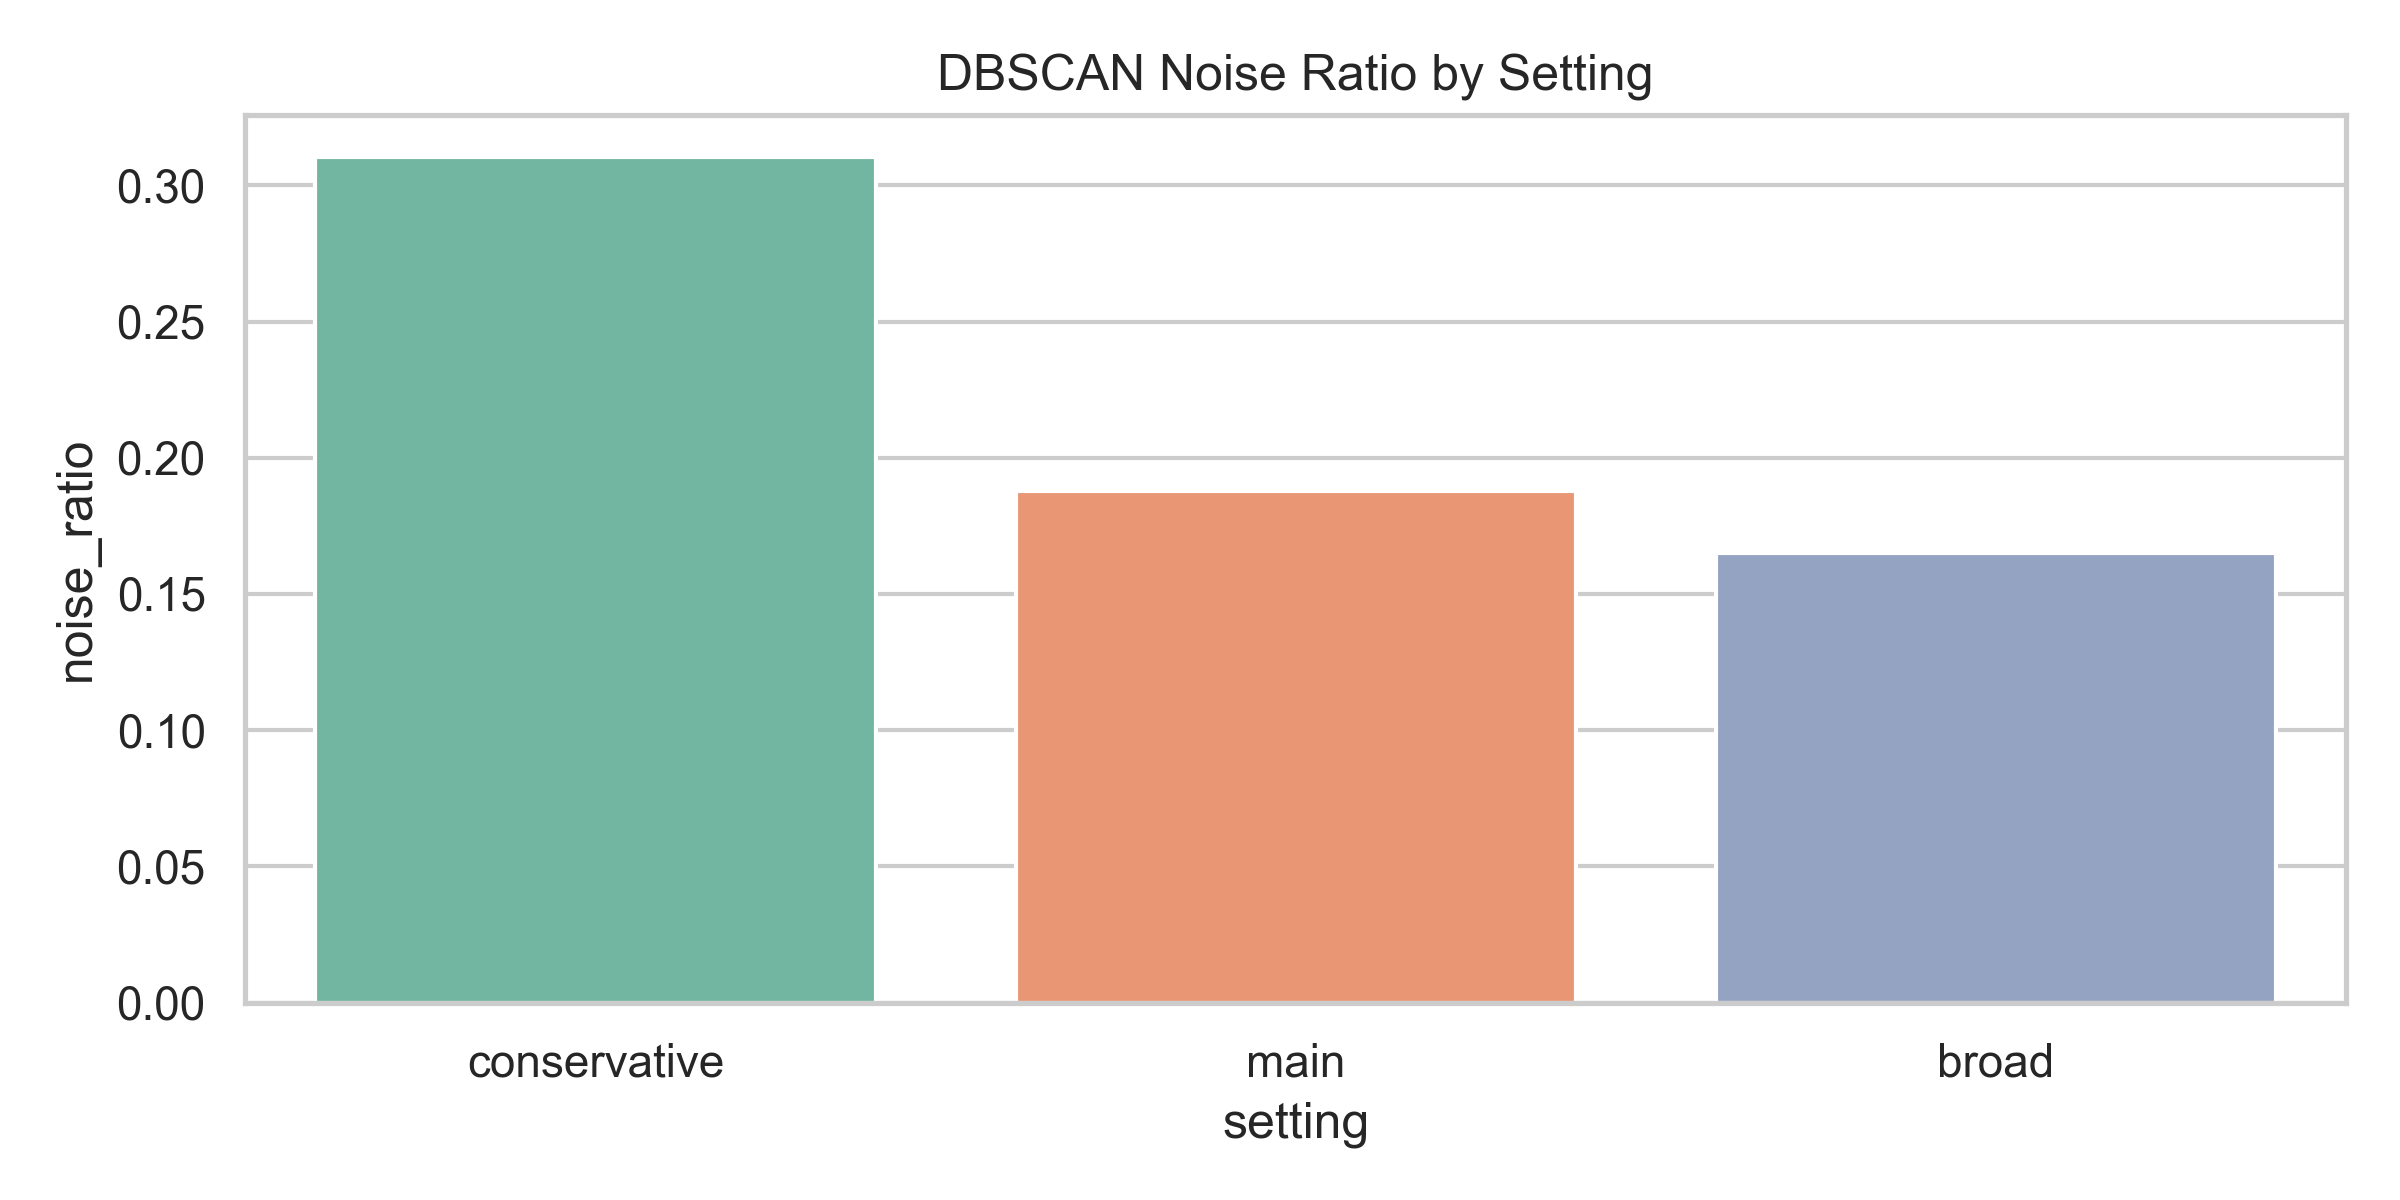

**DBSCAN event count by setting**

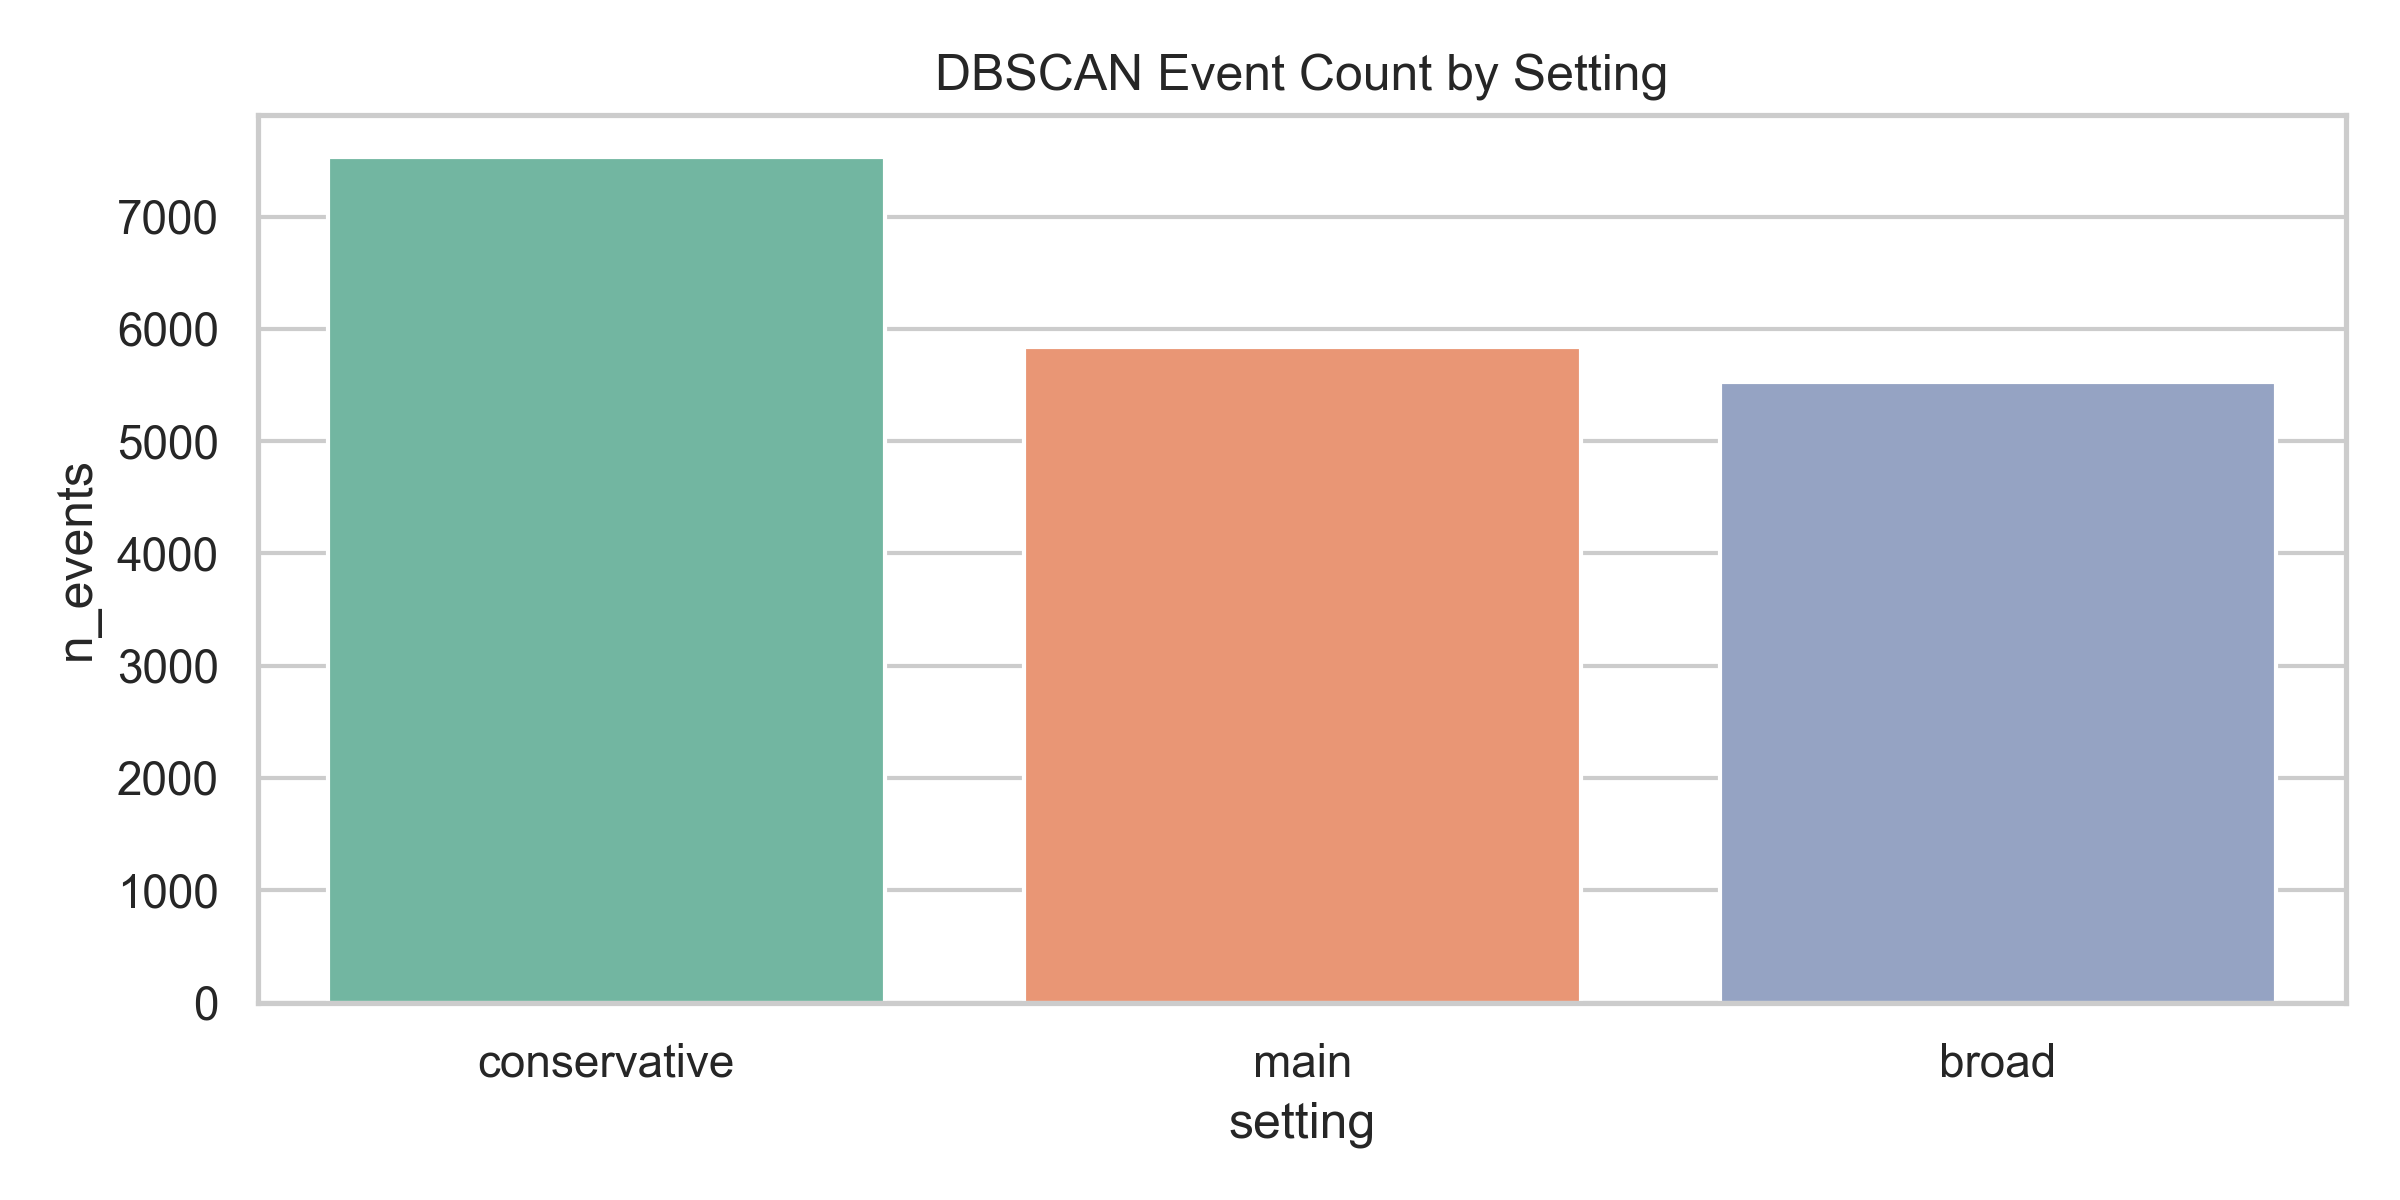

**Main setting event duration distribution**

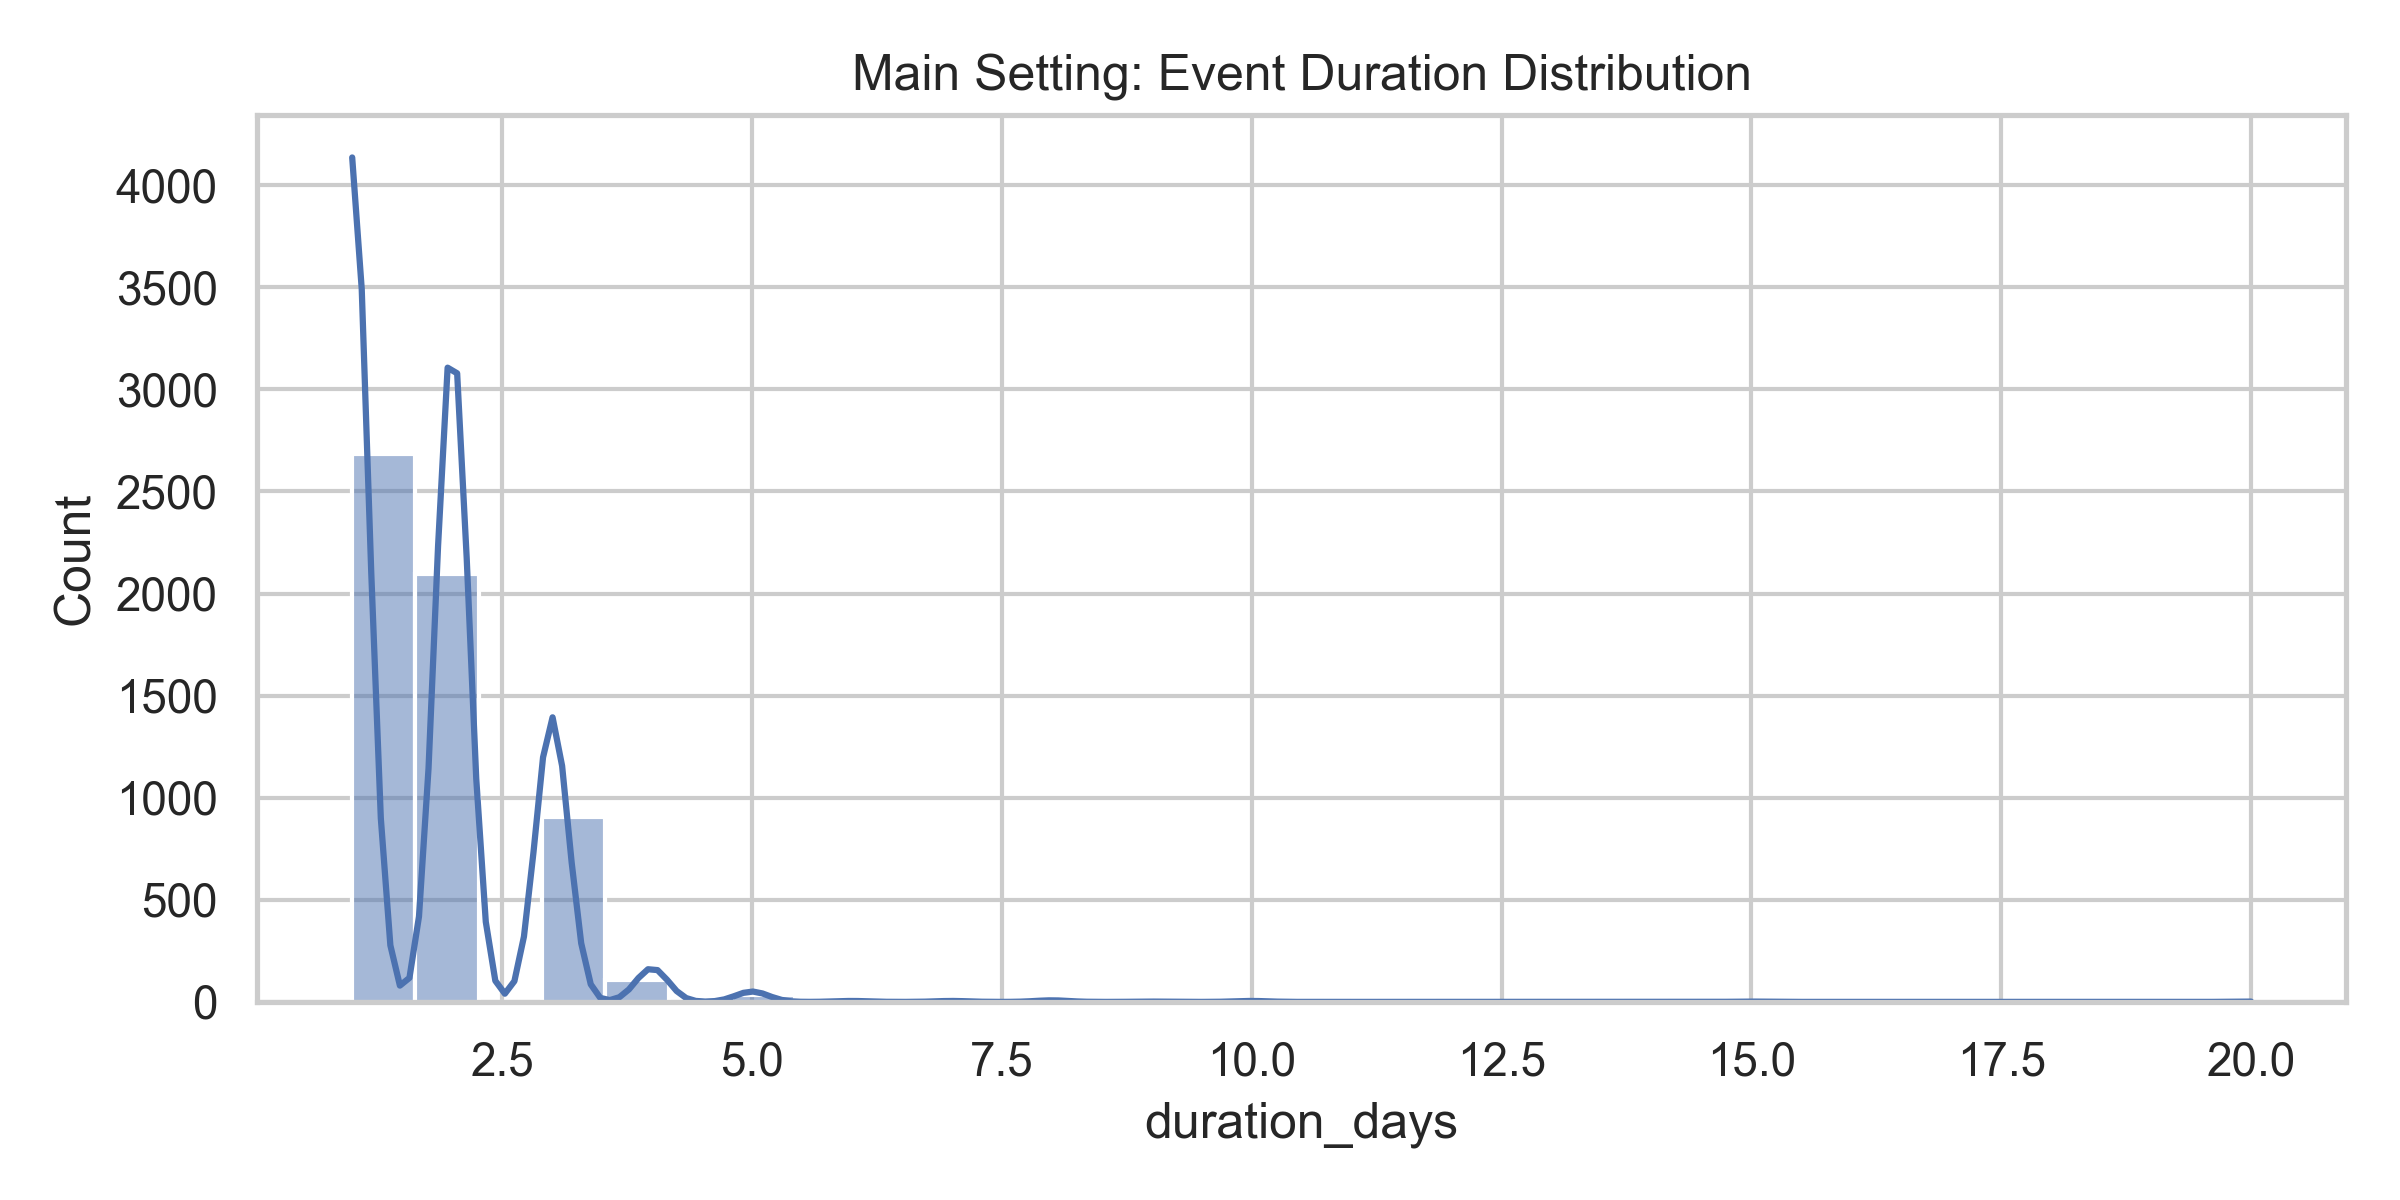

**Main setting detection-points distribution**

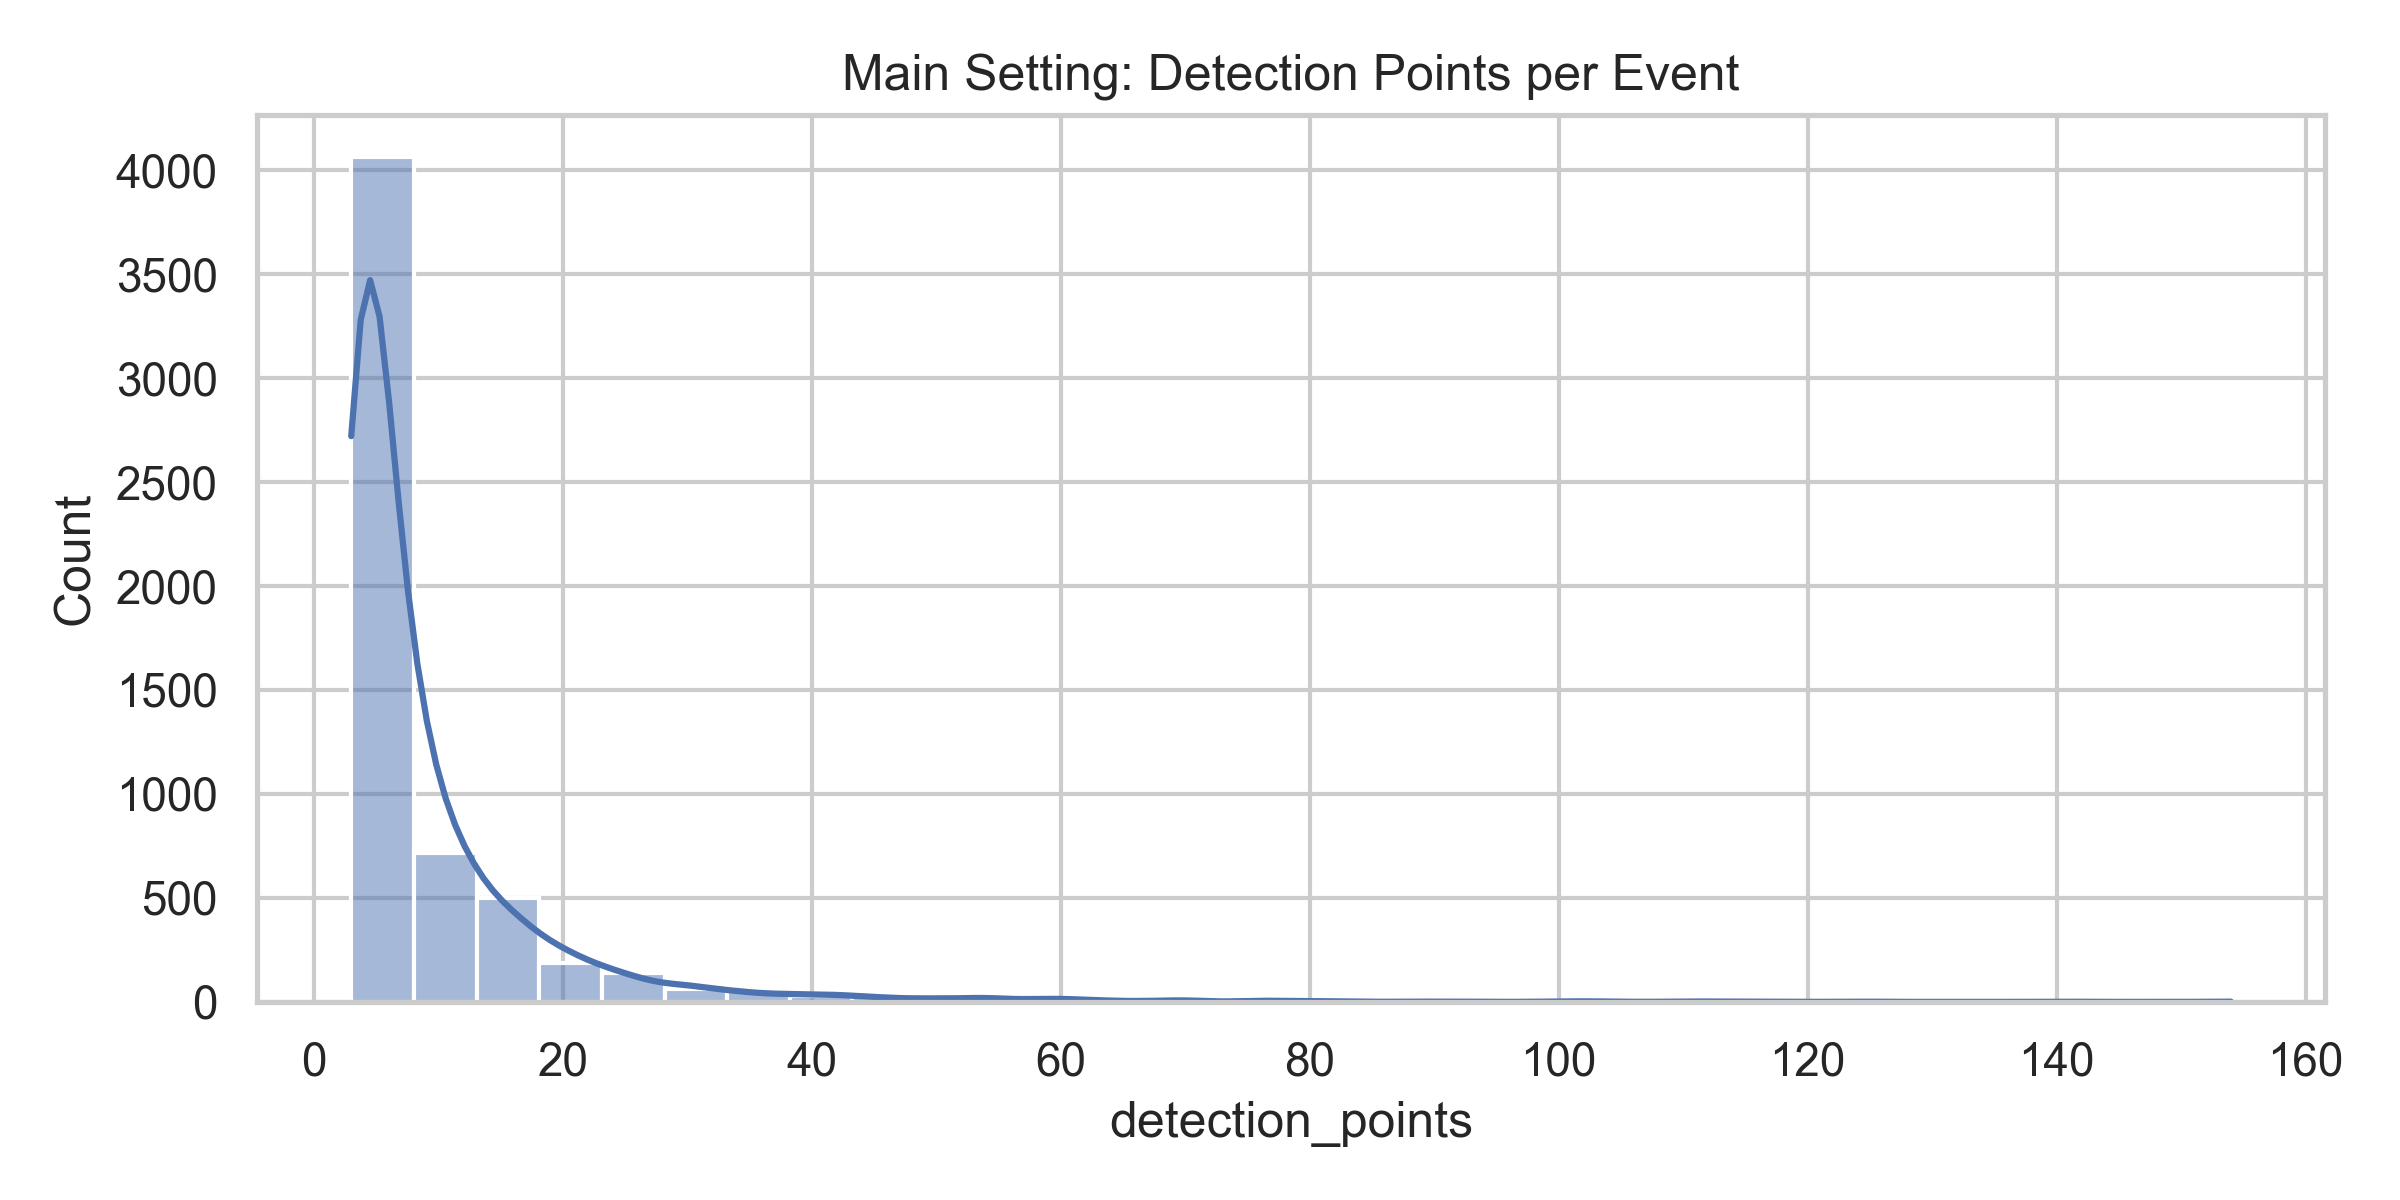

In [17]:
# Load DBSCAN diagnostics and display key figures

dbscan_summary = load_csv("dbscan_sensitivity_summary.csv")
dbscan_event_quality = load_csv("dbscan_event_quality_main.csv")
dbscan_region_summary = load_csv("dbscan_region_summary_main.csv")

display(dbscan_summary)
display(dbscan_region_summary.head(20))
display(dbscan_event_quality.head(20))

display_png(resolve_output_path("dbscan_noise_ratio_by_setting.png"), "DBSCAN noise ratio by setting")
display_png(resolve_output_path("dbscan_event_count_by_setting.png"), "DBSCAN event count by setting")
display_png(resolve_output_path("dbscan_duration_distribution_main.png"), "Main setting event duration distribution")
display_png(resolve_output_path("dbscan_detection_points_distribution_main.png"), "Main setting detection-points distribution")

**Interpretation:**
- Conservative settings create more small events and higher noise.
- Broad settings reduce noise but can over-merge nearby events.
- The main setting (`8 km`, `2 days`, `min_samples=3`) remains a balanced operational choice for event stability and interpretability.

## 6) Task 2 — Temporal and Spatial Patterns

This section summarizes temporal escalation patterns and geographic hotspot behavior from clustered thermal events.

,year_month,region,n_events,year_month_str
0,2024-06,black_sea,14,2024-06
1,2024-06,eastern_med,64,2024-06
2,2024-06,persian_gulf,126,2024-06
3,2024-06,red_sea,4,2024-06
4,2024-06,sahara_control,19,2024-06
5,2024-07,black_sea,60,2024-07
6,2024-07,eastern_med,12,2024-07
7,2024-07,persian_gulf,74,2024-07
8,2024-07,red_sea,4,2024-07
9,2024-07,sahara_control,10,2024-07


,year_month,region,mean_total_frp,year_month_str
0,2024-06,black_sea,117.254286,2024-06
1,2024-06,eastern_med,186.186563,2024-06
2,2024-06,persian_gulf,151.188730,2024-06
3,2024-06,red_sea,242.197500,2024-06
4,2024-06,sahara_control,70.576842,2024-06
5,2024-07,black_sea,166.980333,2024-07
6,2024-07,eastern_med,207.968333,2024-07
7,2024-07,persian_gulf,149.277297,2024-07
8,2024-07,red_sea,71.655000,2024-07
9,2024-07,sahara_control,104.447000,2024-07


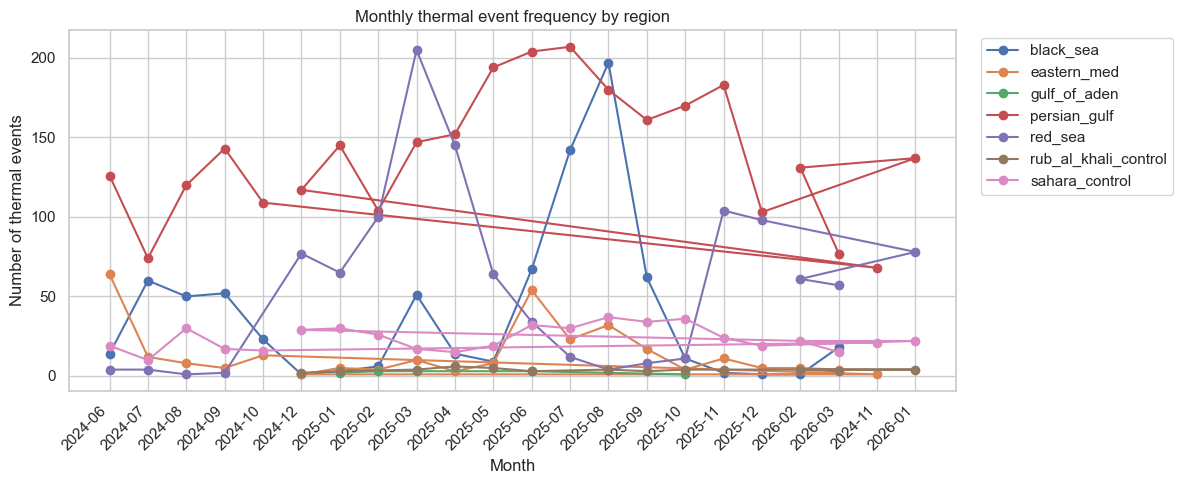

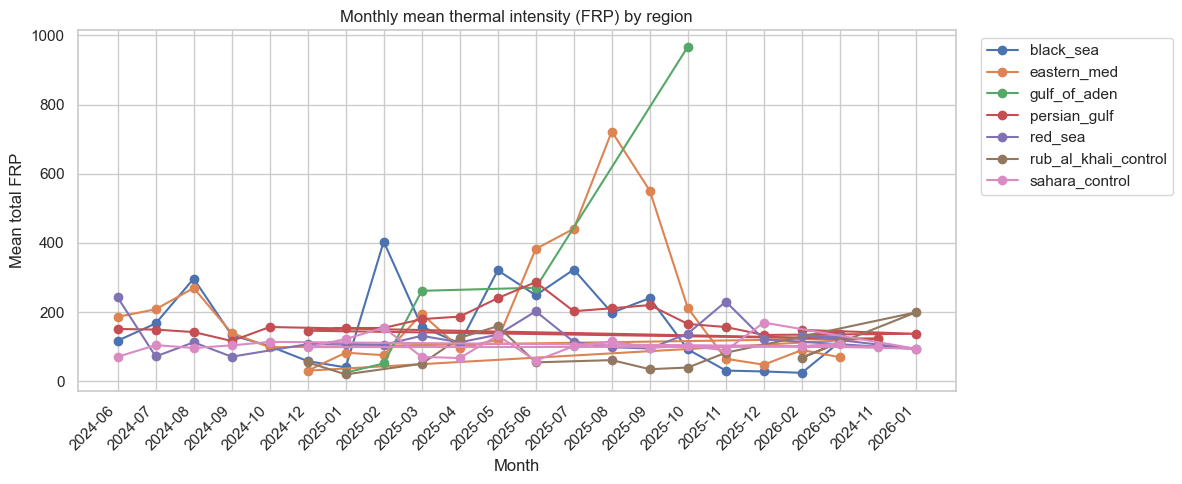

**Spatial distribution of thermal event intensity**

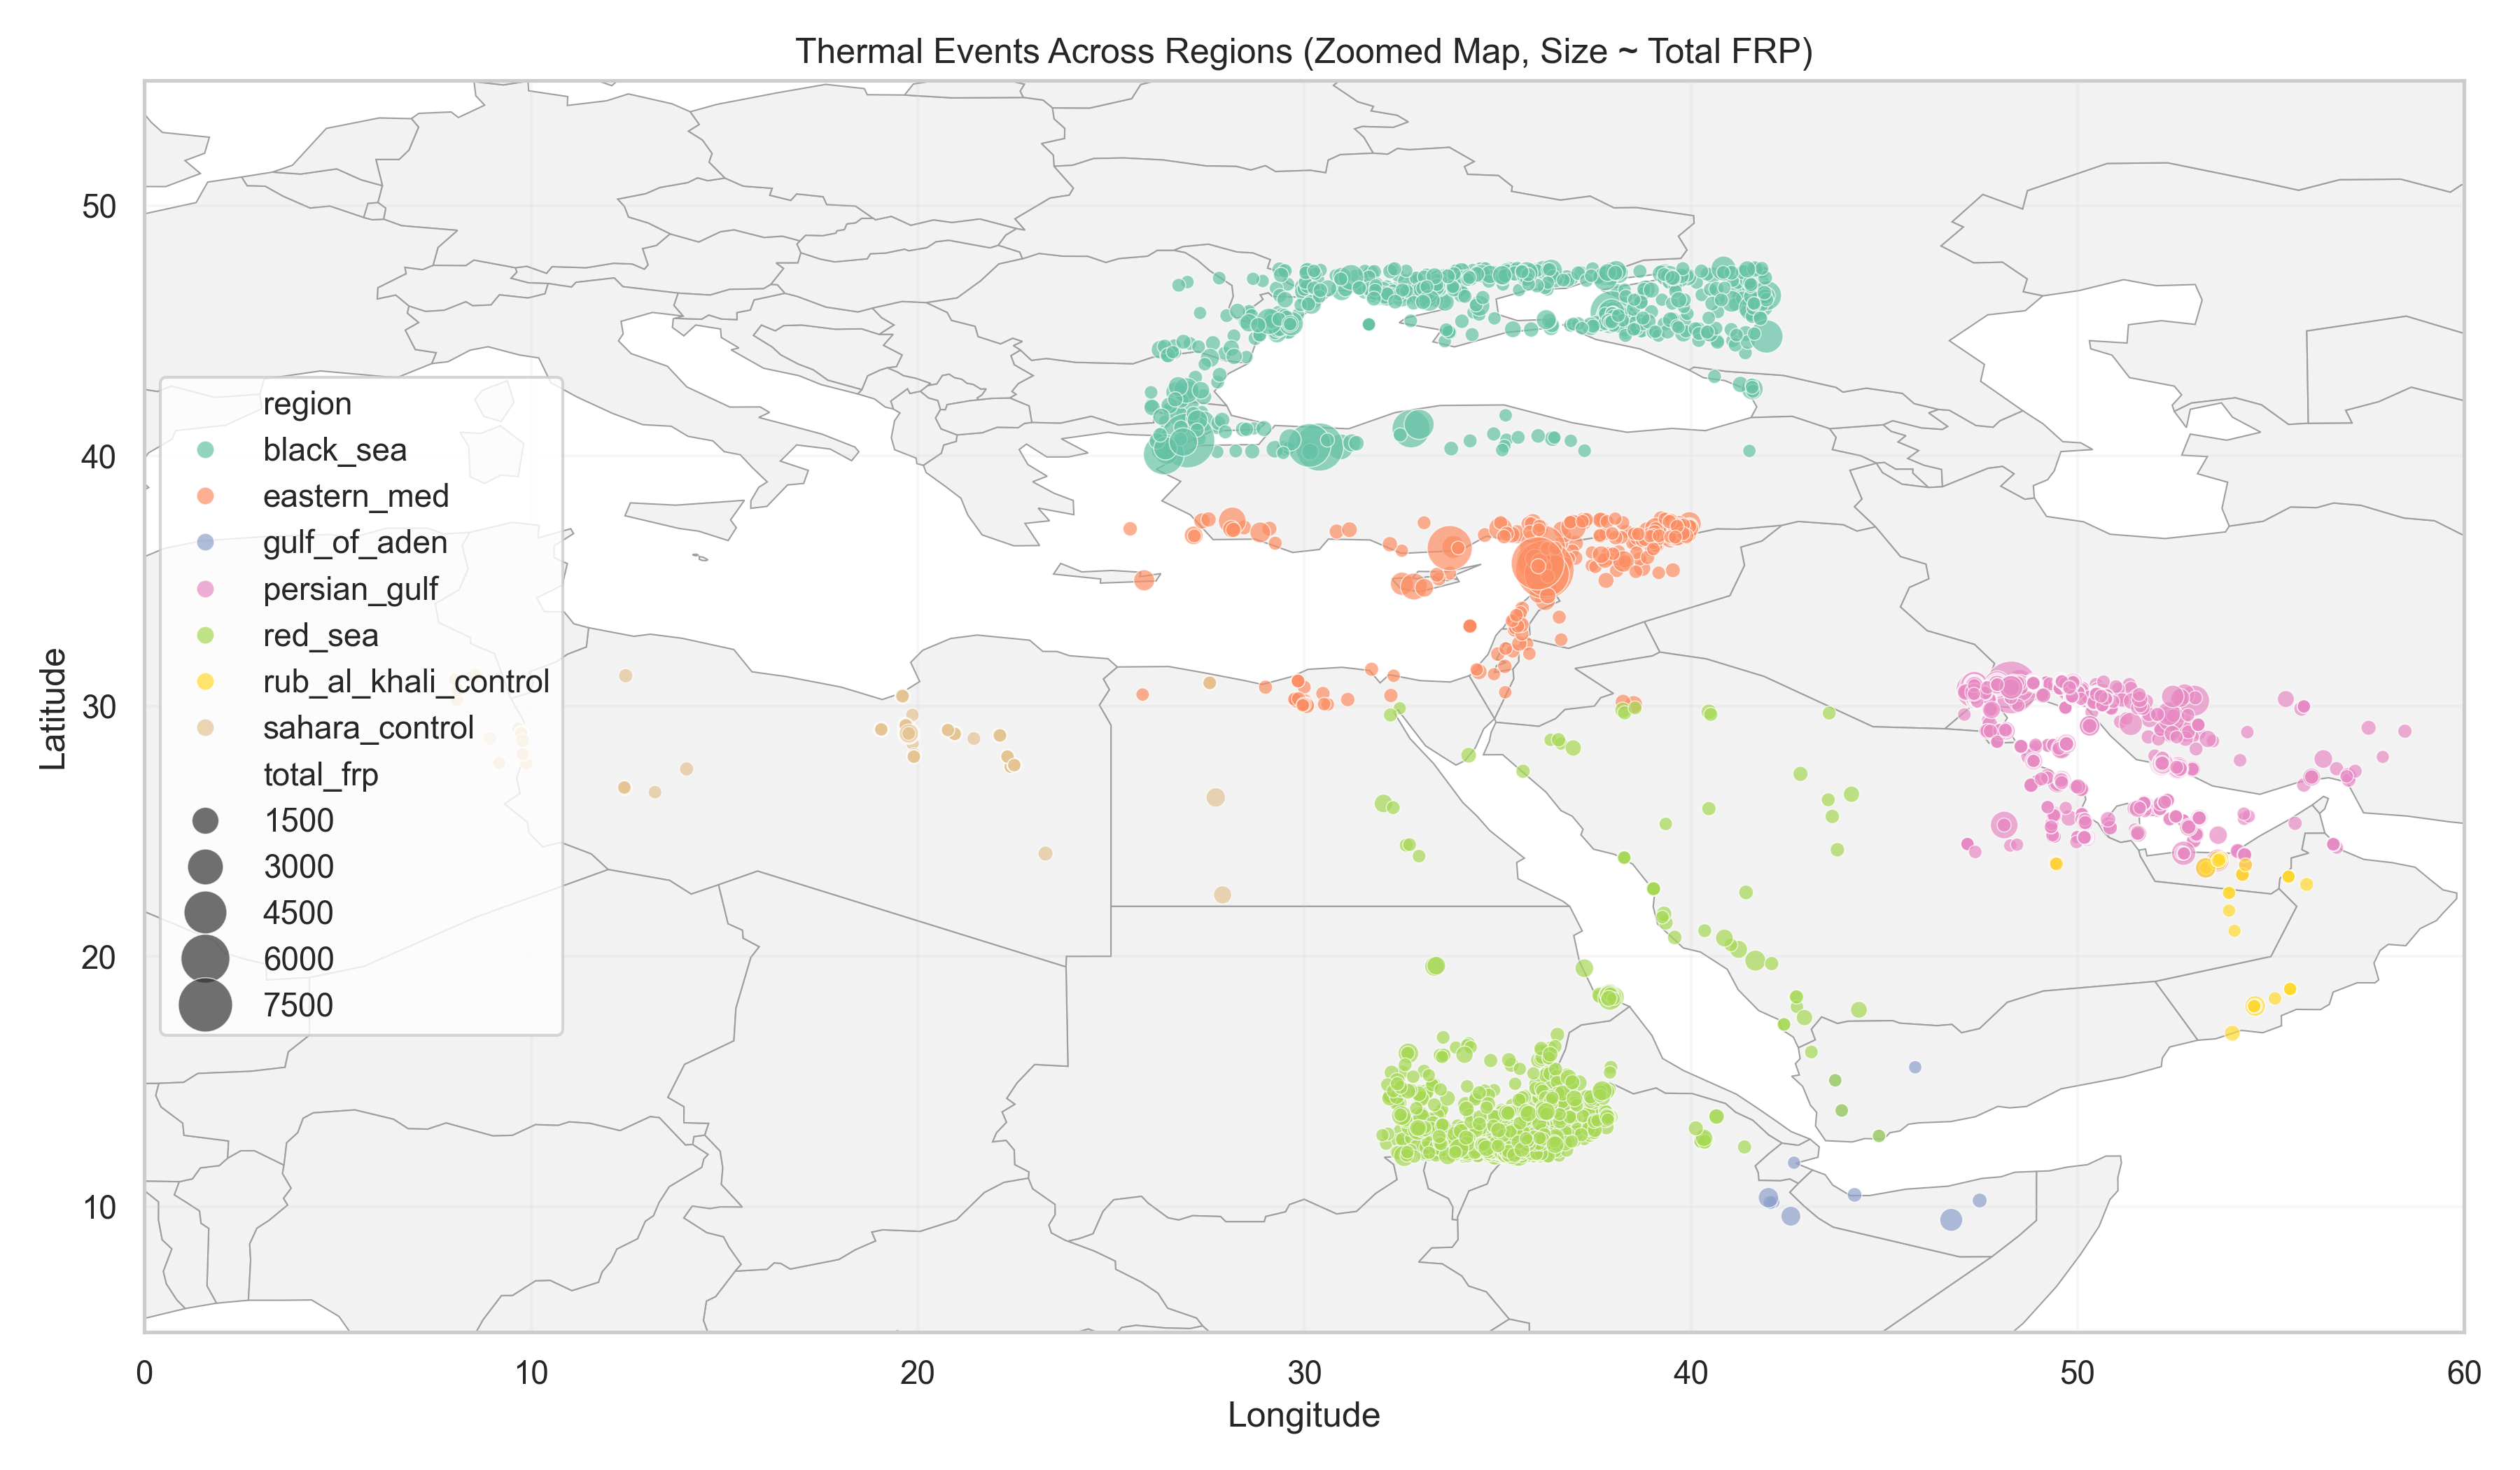

**Spatial distribution of event duration**

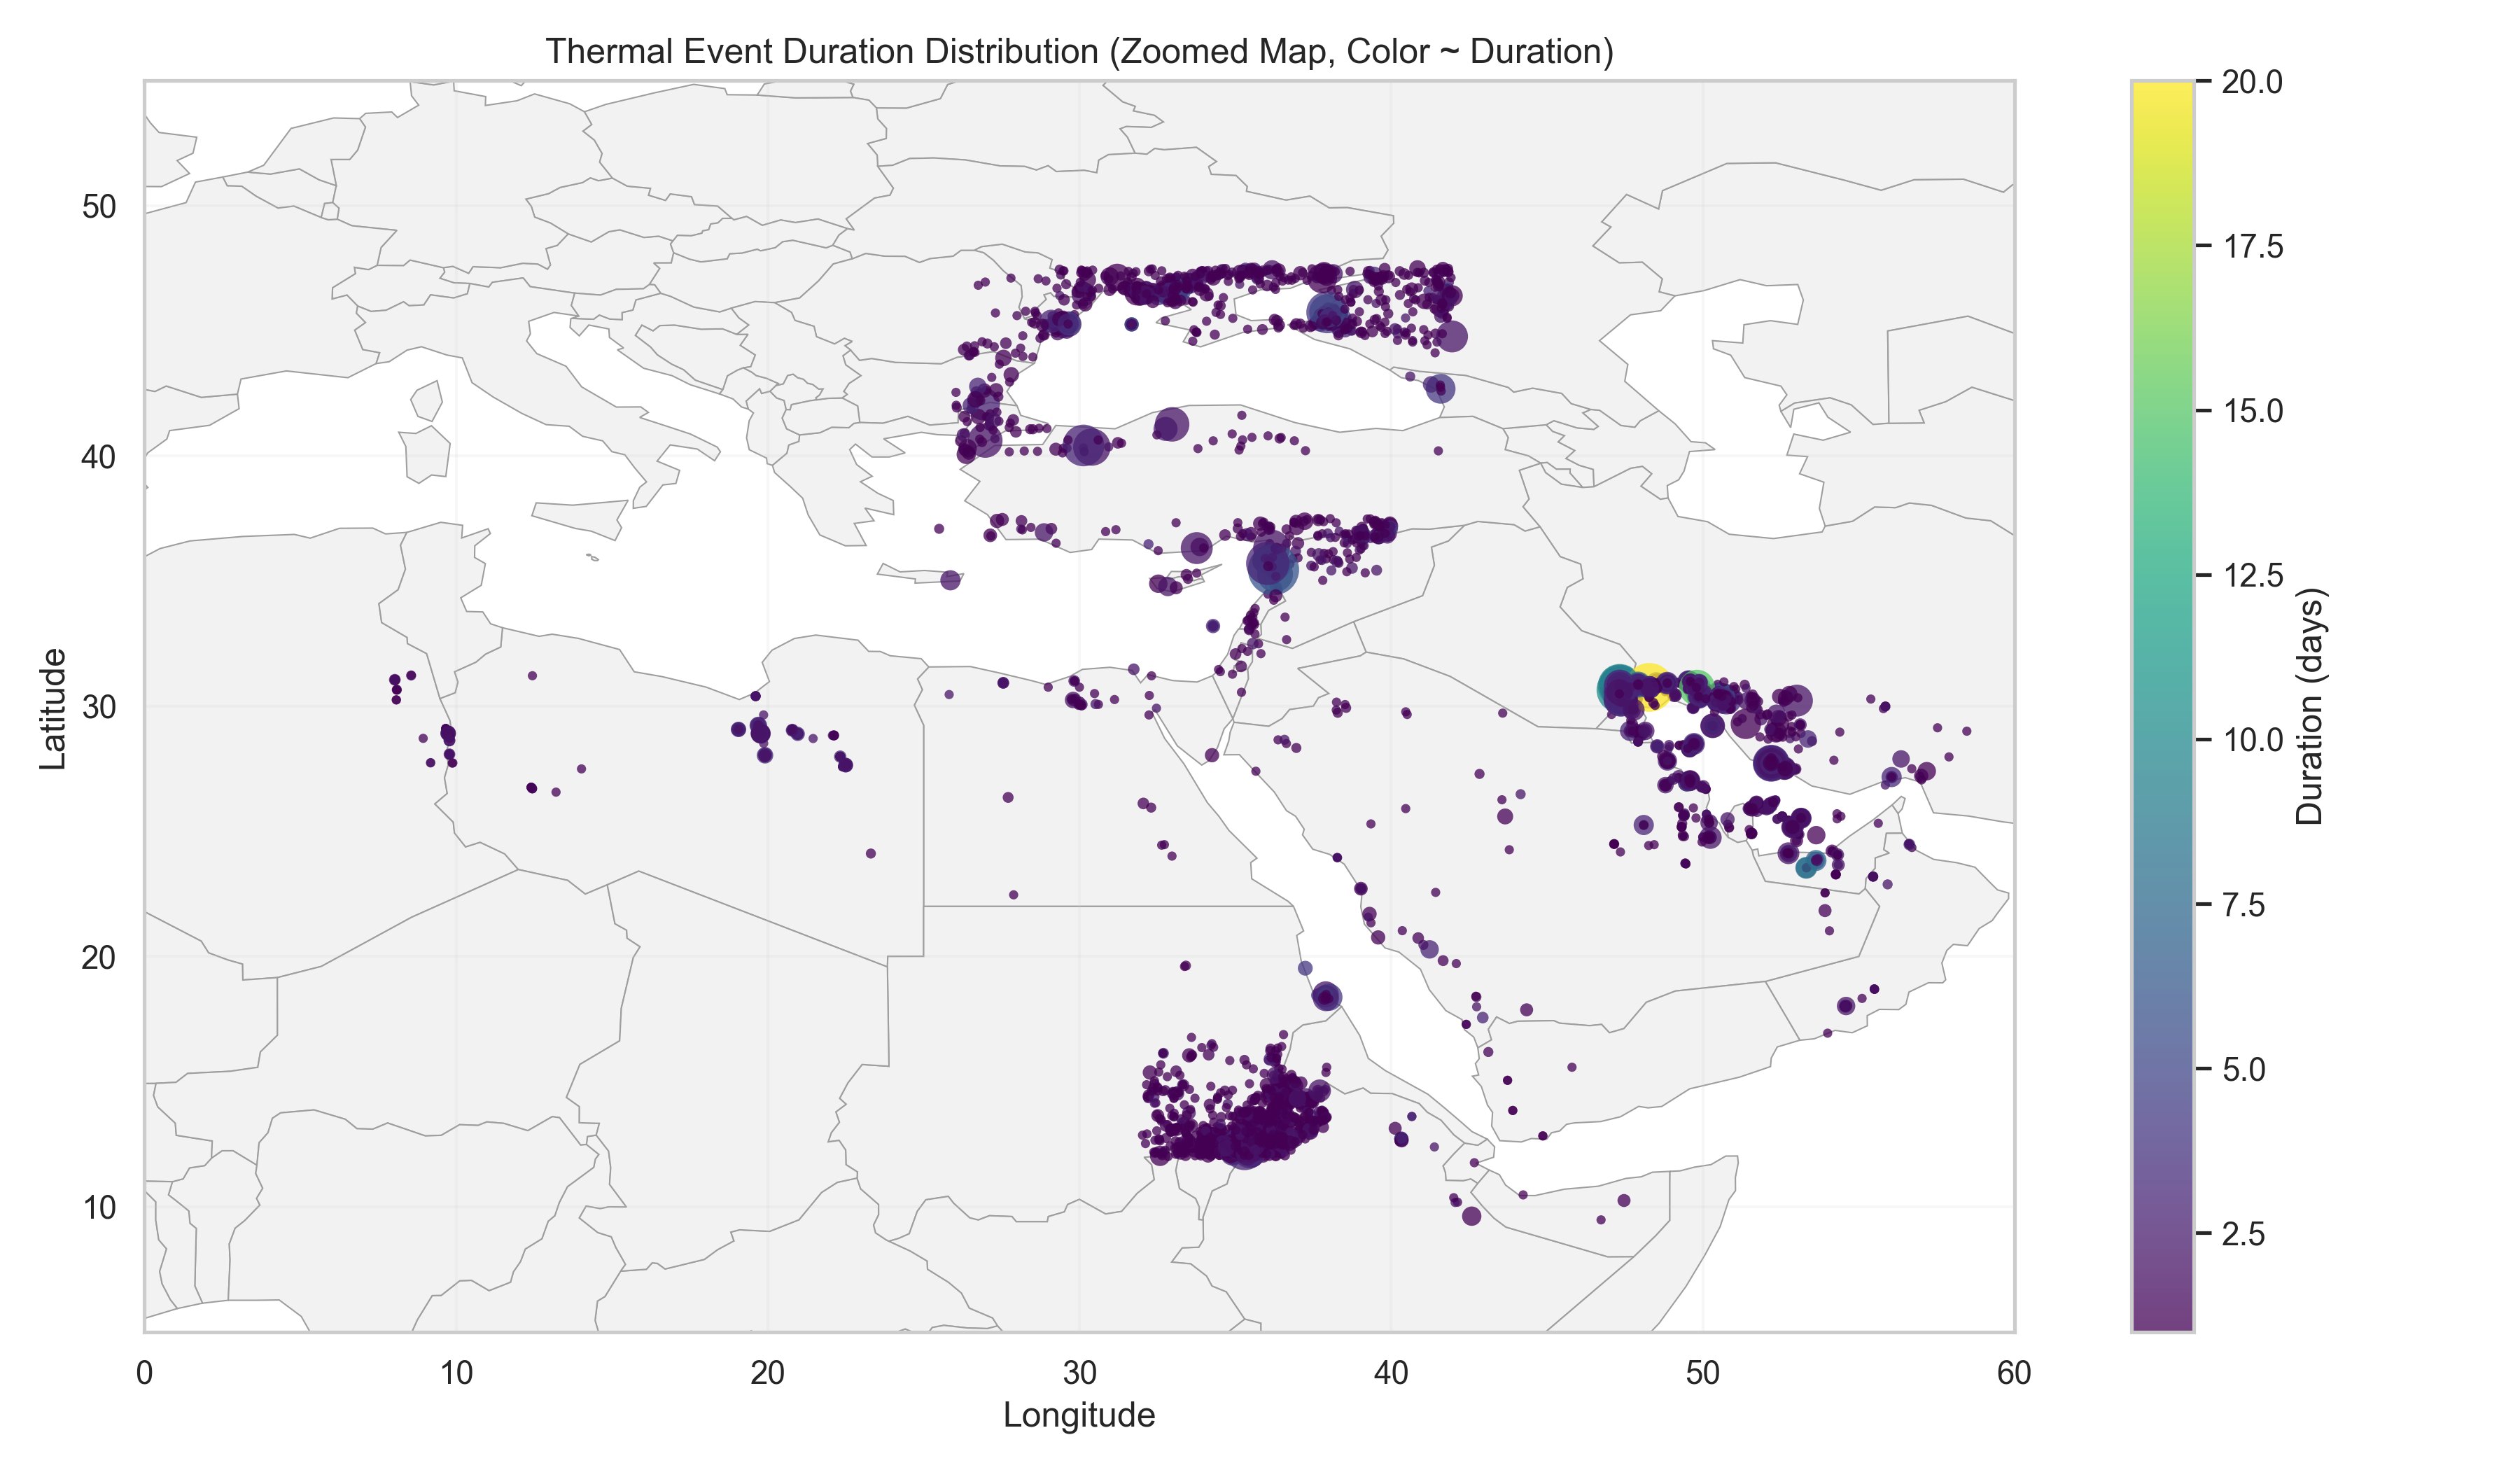

**Pipeline figure: monthly event count**

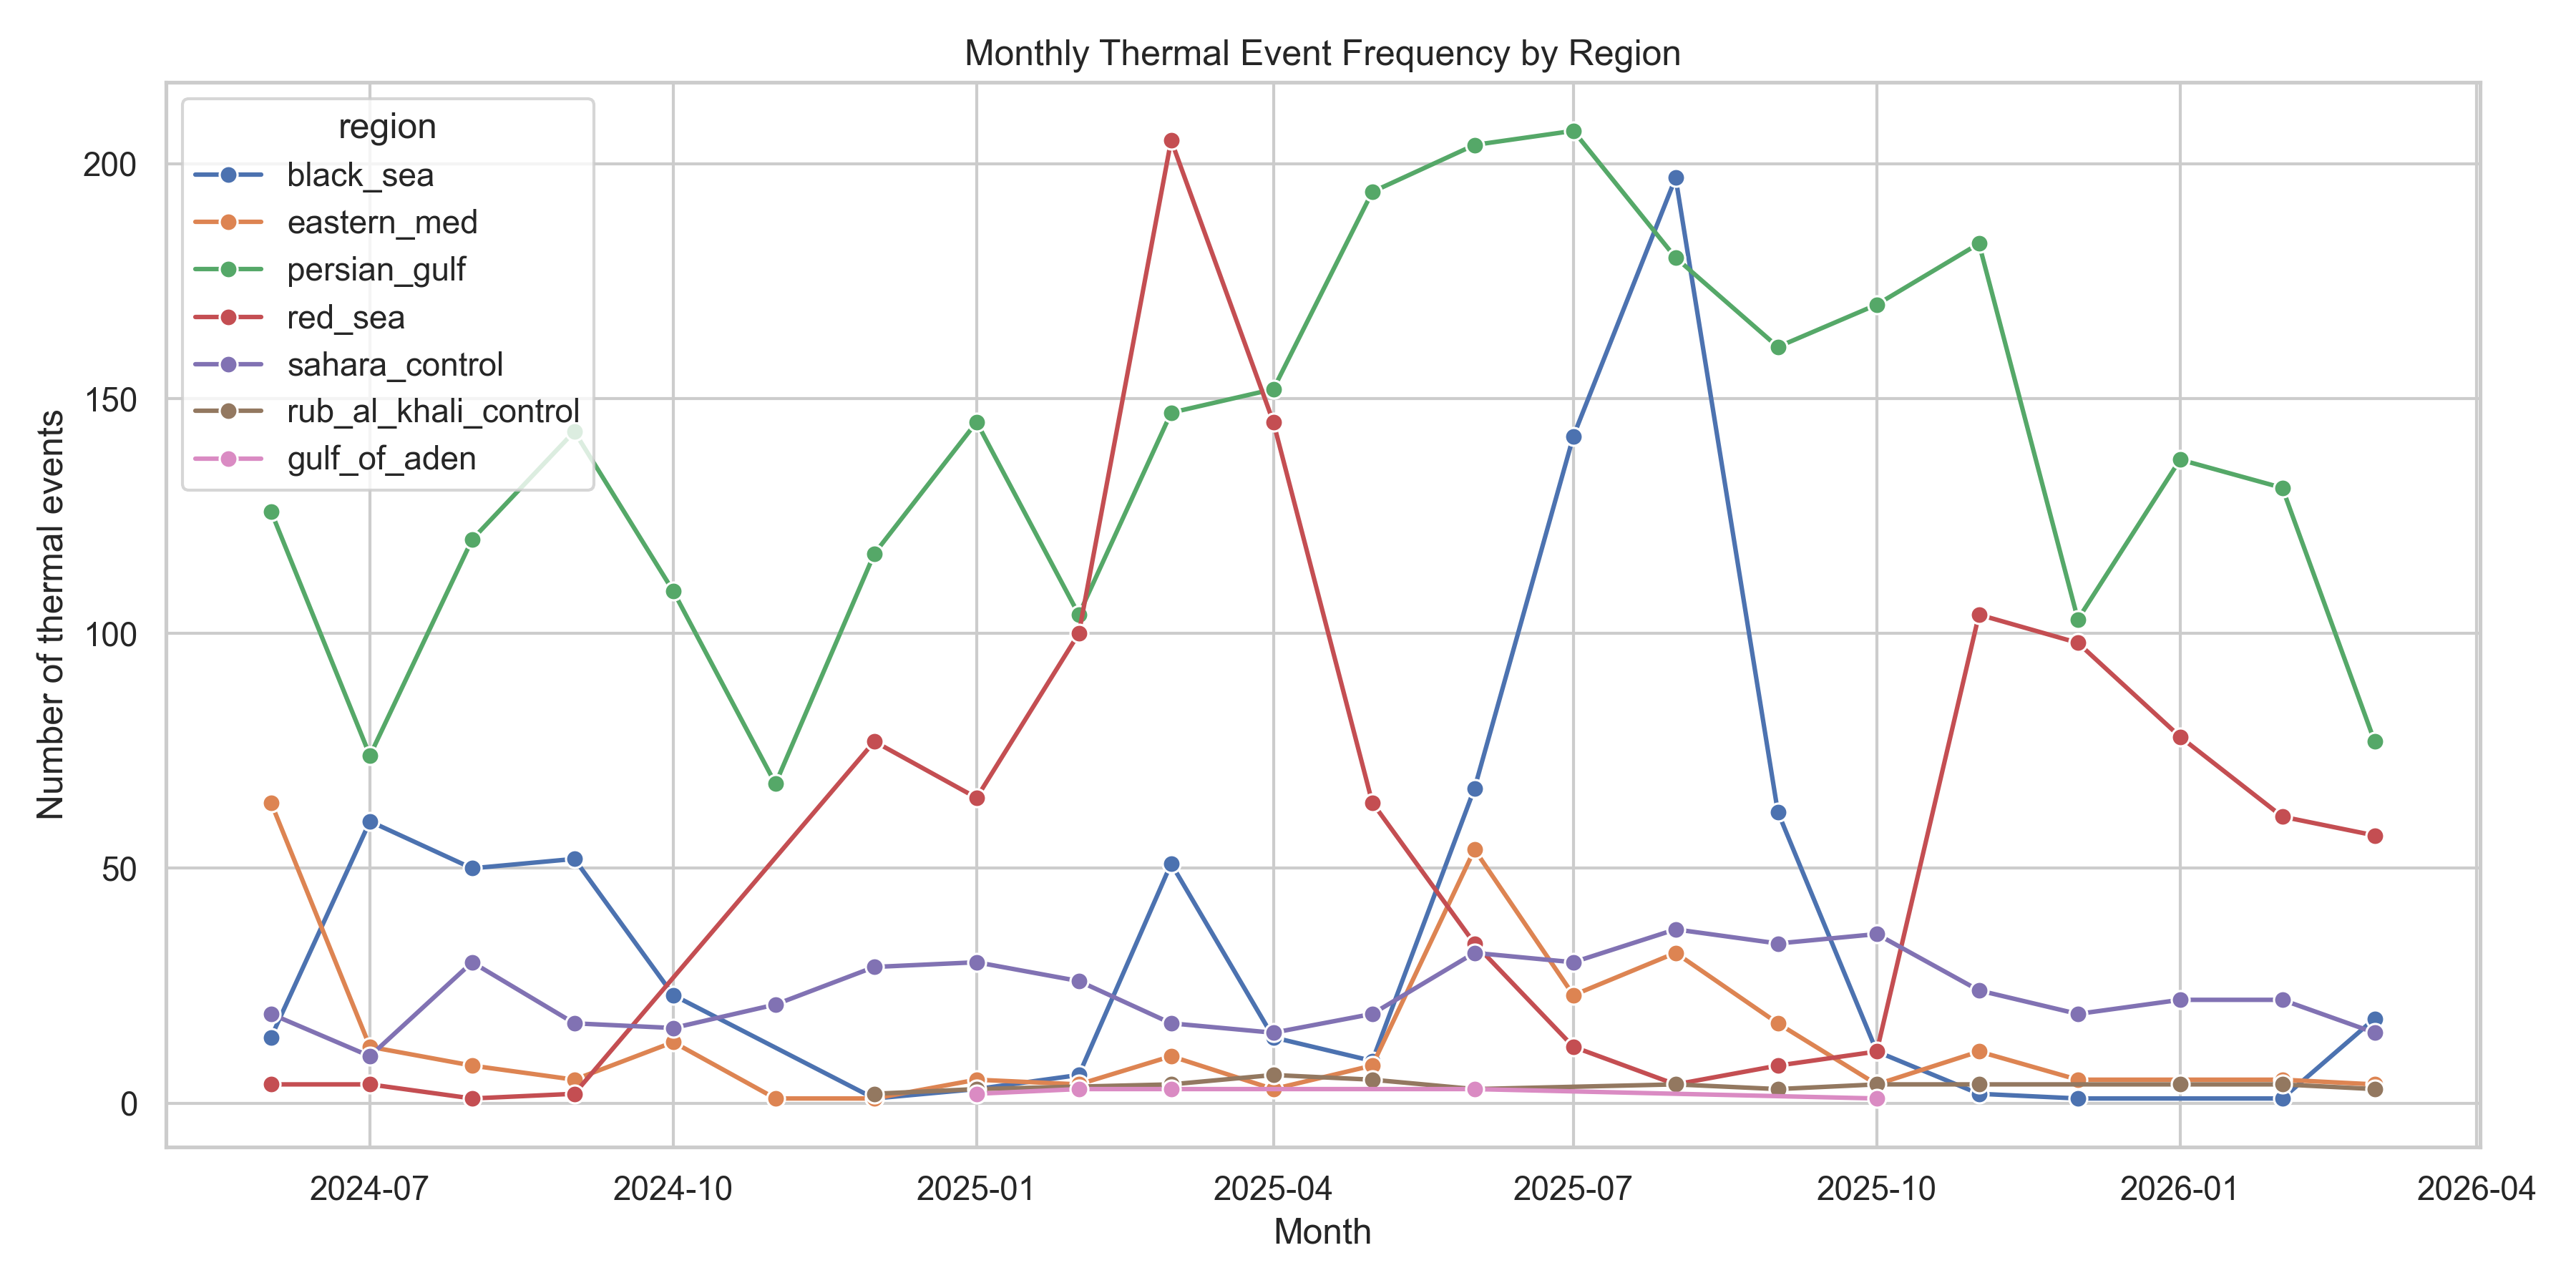

**Pipeline figure: monthly mean FRP**

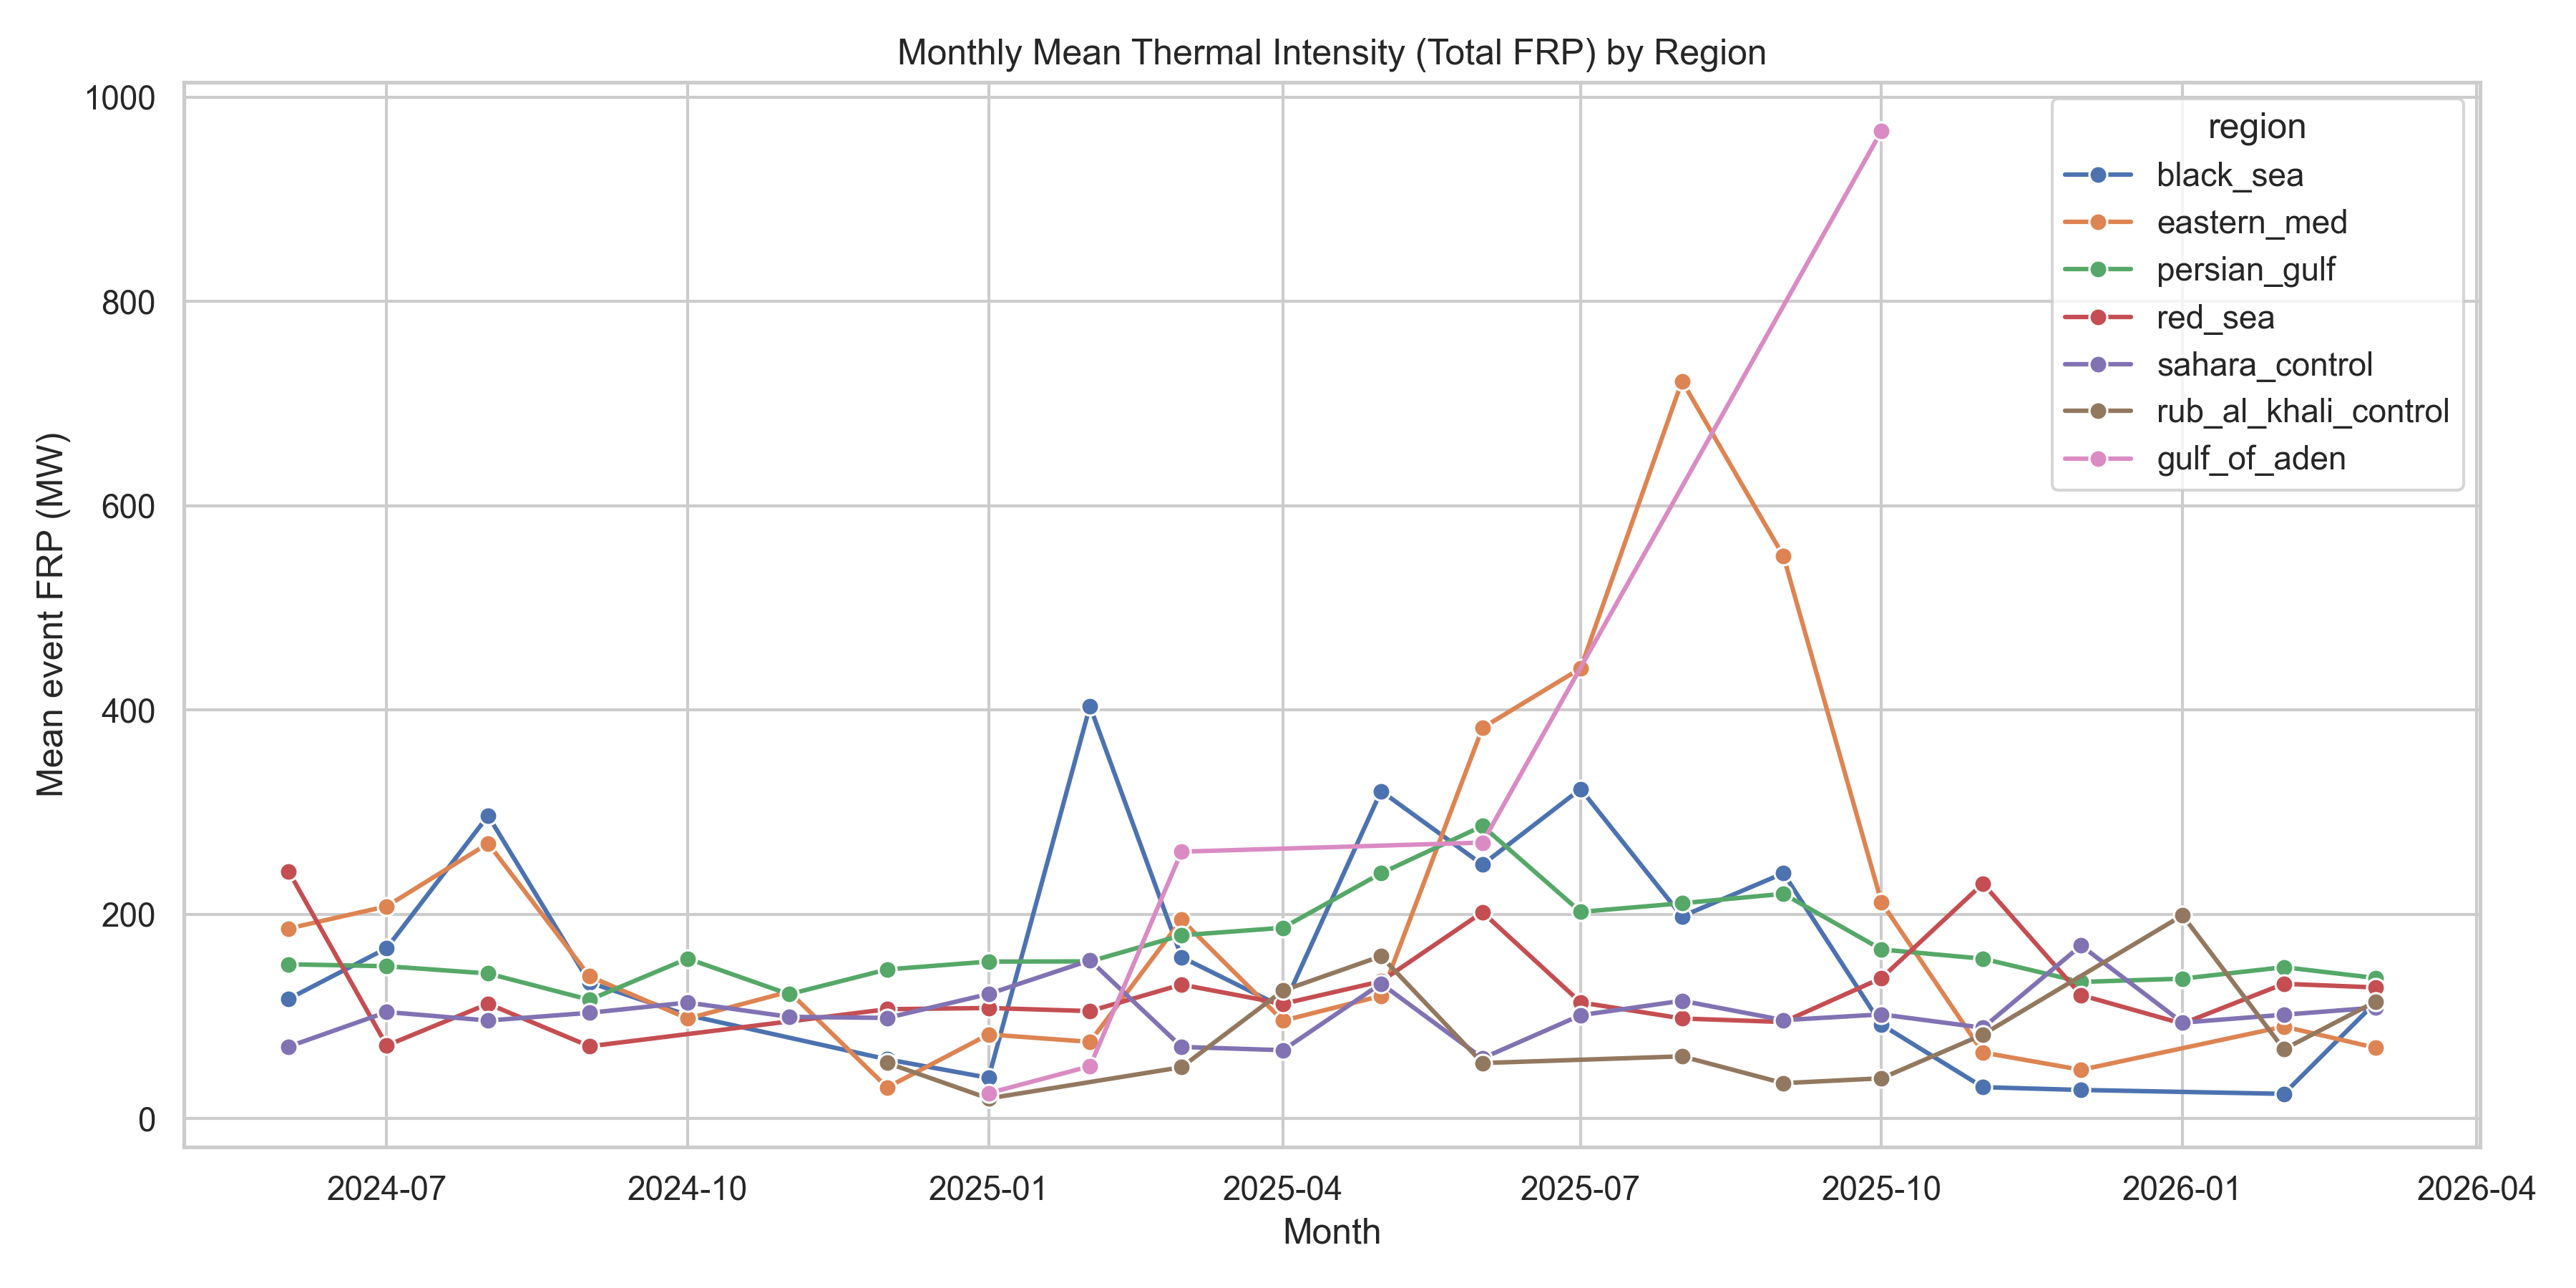

In [18]:
# Temporal summaries from thermal_events

te = thermal_events.copy()
te["start_date"] = pd.to_datetime(te["start_date"], errors="coerce")
te["year_month"] = te["start_date"].dt.to_period("M")

monthly_counts = (
    te.groupby(["year_month", "region"], as_index=False)
    .size()
    .rename(columns={"size": "n_events"})
    .sort_values(["year_month", "region"])
)
monthly_frp = (
    te.groupby(["year_month", "region"], as_index=False)["total_frp"]
    .mean()
    .rename(columns={"total_frp": "mean_total_frp"})
    .sort_values(["year_month", "region"])
)

# String month labels are created after sorting to preserve chronological order.
monthly_counts["year_month_str"] = monthly_counts["year_month"].astype(str)
monthly_frp["year_month_str"] = monthly_frp["year_month"].astype(str)

display(monthly_counts.head(20))
display(monthly_frp.head(20))

# Plot 1: monthly event frequency
plt.figure(figsize=(12, 5))
for r, g in monthly_counts.groupby("region"):
    g = g.sort_values("year_month")
    plt.plot(g["year_month_str"], g["n_events"], marker="o", label=r)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Month")
plt.ylabel("Number of thermal events")
plt.title("Monthly thermal event frequency by region")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Plot 2: mean FRP over time
plt.figure(figsize=(12, 5))
for r, g in monthly_frp.groupby("region"):
    g = g.sort_values("year_month")
    plt.plot(g["year_month_str"], g["mean_total_frp"], marker="o", label=r)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Month")
plt.ylabel("Mean total FRP")
plt.title("Monthly mean thermal intensity (FRP) by region")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Spatial/task2 final figures from pipeline
for name, title in [
    ("task2_spatial_events_frp_region.png", "Spatial distribution of thermal event intensity"),
    ("task2_spatial_duration_distribution.png", "Spatial distribution of event duration"),
    ("task2_temporal_monthly_event_count.png", "Pipeline figure: monthly event count"),
    ("task2_temporal_monthly_mean_frp.png", "Pipeline figure: monthly mean FRP"),
]:
    display_png(resolve_output_path(name), title=title)

**Interpretation:** Temporal counts and FRP intensity vary across regions and months, supporting the need for event-level matching and drift-aware interpretation rather than static assumptions.

## 7) Task 3 — Bilingual Conflict-News Matching

### Matching strategy (final)
- FIRMS events are the primary monitored objects.
- Temporal matching: article within event period to `+3 days`.
- Region/location evidence: event-region-relevant mentions in title/location text.
- Bilingual conflict matching: English + Turkish term groups.
- Strong action + supporting evidence rule (actor/target/weapon/context/region evidence).
- Non-conflict penalties to reduce wildfire/accident-like false links.
- Event-level score combines article quality, source/day diversity, and **log-saturated article count**.

### Why `0.45 * log1p(n_articles)`
It increases confidence with diminishing returns, so media-heavy regions do not dominate purely by volume. News here is a weak supervision and contextual confirmation layer, not the primary sensing layer.

,article_id_or_url,title,source,published_at,language_detected,region,region_or_location_mention,matched_text_used_for_keywords,source_field_excluded,match_channels,strong_action_hits,weapon_specific_hits,generic_actor_hits,named_actor_hits,target_hits,non_conflict_hits,matched_language_terms,conflict_signal,article_score,reason_flags
0,https://news.google.com/rss/articles/CBMijAFBV...,Ukrayna'dan Kırım'daki Rusya hedeflerine saldı...,Sözcü Gazetesi,2024-06-06 07:00:00+00:00,tr,black_sea,ukrayna,Ukrayna'dan Kırım'daki Rusya hedeflerine saldı...,True,location|title,saldırı,NaN,NaN,rusya|ukrayna,NaN,NaN,tr,True,3.25,has_strong_action|has_named_actor|has_region_e...
1,https://news.google.com/rss/articles/CBMijgFBV...,"In Ukraine’s south, marines are waging a gruel...",The Christian Science Monitor,2024-06-07 07:00:00+00:00,en,black_sea,ukraine,"In Ukraine’s south, marines are waging a gruel...",True,location|title,NaN,NaN,NaN,ukraine,NaN,NaN,en,False,1.90,has_named_actor|has_region_evidence
2,https://news.google.com/rss/articles/CBMiZEFVX...,Russians attack Odesa with Shahed drones: expl...,Українська правда,2024-06-07 07:00:00+00:00,en,black_sea,odesa,Russians attack Odesa with Shahed drones: expl...,True,title,attack,NaN,NaN,NaN,NaN,NaN,en,True,3.00,has_strong_action|has_region_evidence
3,https://news.google.com/rss/articles/CBMipgFBV...,Turkish foreign minister receives Chinese amba...,Anadolu Ajansı,2024-06-12 07:00:00+00:00,en,black_sea,NaN,Turkish foreign minister receives Chinese amba...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en,False,1.00,NaN
4,https://news.google.com/rss/articles/CBMidEFVX...,Russia Now Uses Submarines to Patrol Black Sea...,The Defense Post,2024-06-13 07:00:00+00:00,en,black_sea,black sea,Russia Now Uses Submarines to Patrol Black Sea...,True,title,NaN,NaN,NaN,russia,NaN,NaN,en,False,2.15,has_named_actor|has_region_evidence
5,https://news.google.com/rss/articles/CBMirgFBV...,Battles in the Black Sea Changing the Characte...,USNI News,2024-06-13 07:00:00+00:00,en,black_sea,black sea,Battles in the Black Sea Changing the Characte...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en,False,2.15,has_region_evidence
6,https://news.google.com/rss/articles/CBMiXEFVX...,Arjantin’de reform paketini protesto edenler v...,BBC,2024-06-13 07:00:00+00:00,tr,black_sea,NaN,Arjantin’de reform paketini protesto edenler v...,True,title,çatışma,NaN,NaN,NaN,NaN,NaN,tr,True,2.85,has_strong_action|has_context
7,https://news.google.com/rss/articles/CBMimAFBV...,Emirates Changi'den SAF'lı uçtu - Haber Aero,Haber Aero,2024-06-14 07:00:00+00:00,tr,black_sea,NaN,Emirates Changi'den SAF'lı uçtu ||,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tr,False,0.50,NaN
8,https://news.google.com/rss/articles/CBMikAFBV...,Ministry shares original signatures of Atatürk...,Hürriyet Daily News,2024-06-14 07:00:00+00:00,tr,black_sea,NaN,Ministry shares original signatures of Atatürk ||,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tr,False,0.50,NaN
9,https://news.google.com/rss/articles/CBMiqAFBV...,Sırp lider Vucic'den yaklaşan büyük savaşa kar...,Euronews,2024-06-15 07:00:00+00:00,tr,black_sea,NaN,Sırp lider Vucic'den yaklaşan büyük savaşa kar...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tr,False,0.25,NaN


,region,association_rate,association_rate_pct
0,black_sea,0.732143,73.21
1,eastern_med,0.425606,42.56
2,gulf_of_aden,0.416667,41.67
3,persian_gulf,0.311599,31.16
4,red_sea,0.641975,64.20
5,rub_al_khali_control,0.000000,0.00
6,sahara_control,0.125000,12.50


Articles passing conflict_signal: 1091
Articles penalized by non-conflict terms: 7
Turkish keyword/language matches: 1231

Top strong-action terms


,term,count
0,attack,307
1,strike,196
2,saldırı,172
3,combat,89
4,explosion,70
5,hit,57
6,missile strike,55
7,operasyon,42
8,shelling,41
9,vurdu,34



Top generic-actor terms


,term,count
0,military,231
1,navy,78
2,forces,53
3,army,52
4,troops,51
5,rebels,48
6,askeri,36
7,militants,8
8,separatists,7
9,militia,5



Top target terms


,term,count
0,ship,63
1,base,63
2,airport,61
3,tanker,39
4,port,27
5,infrastructure,19
6,havalimanı,15
7,vessel,10
8,gemi,10
9,military base,10


**Conflict-association rate by region**

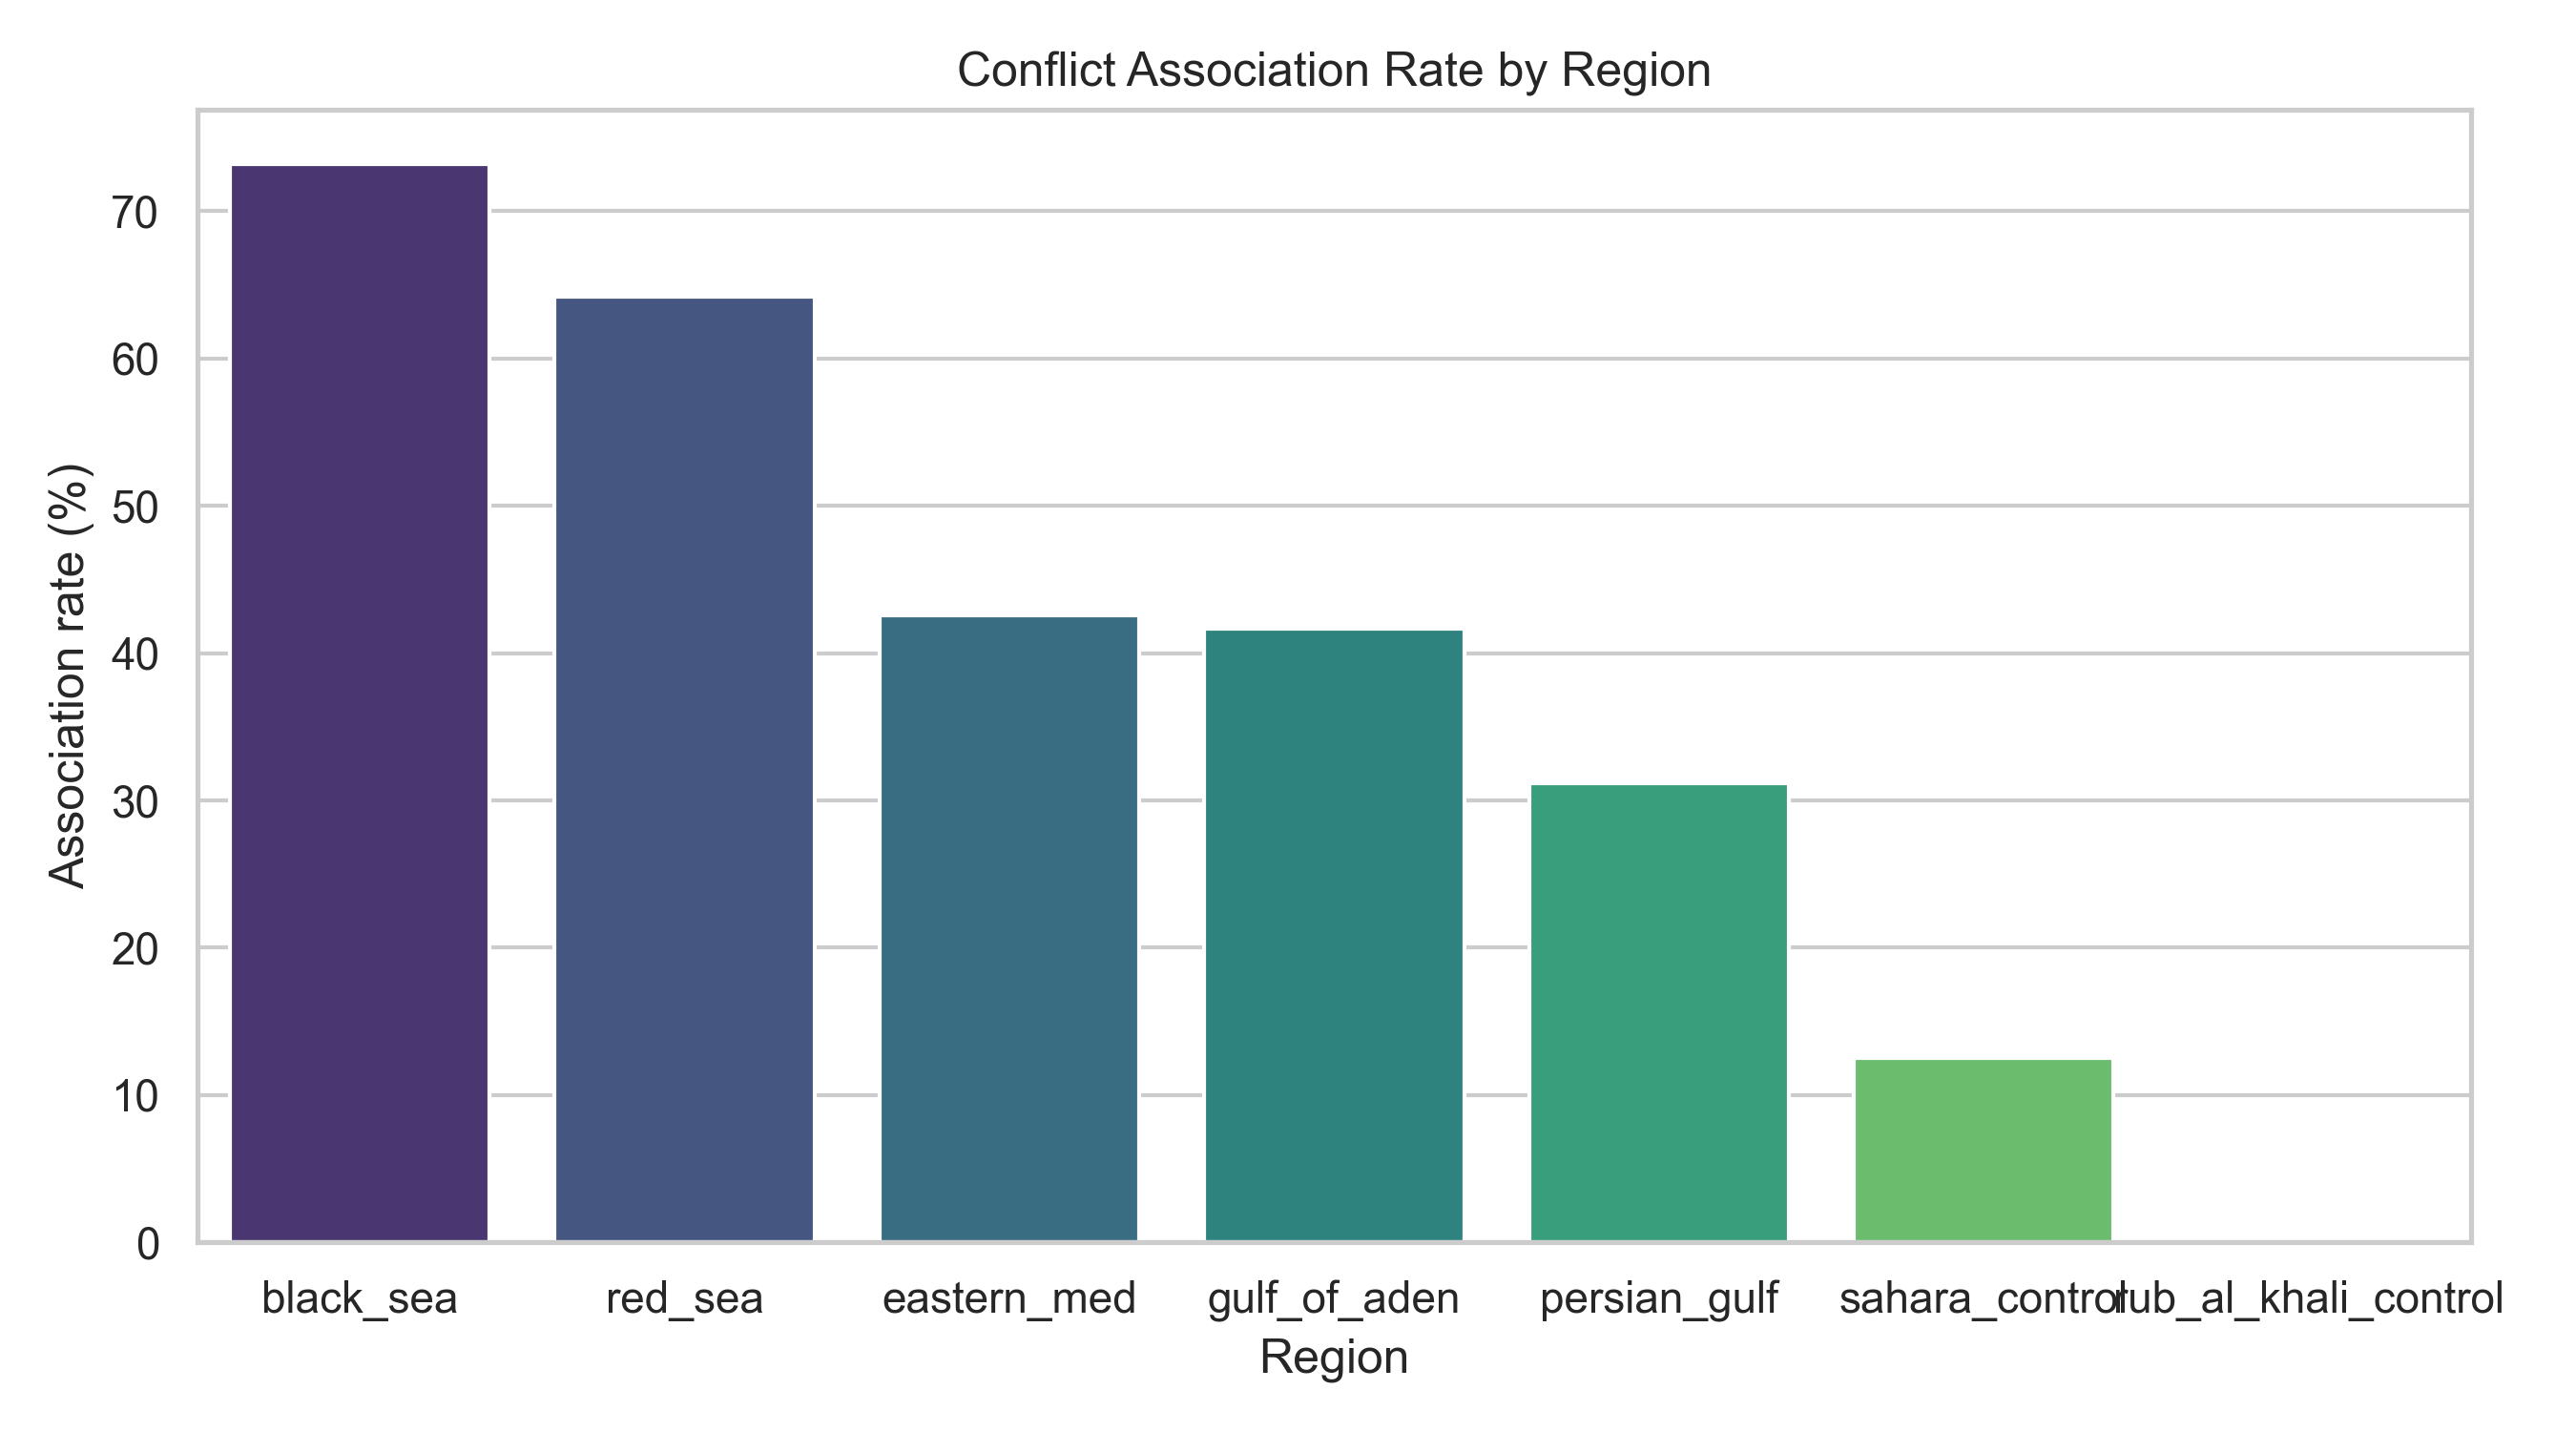

In [19]:
# Matching diagnostics and association summary

keyword_diag = load_csv("keyword_match_diagnostics.csv")
assoc_rate = load_csv("task3_conflict_association_rate_by_region.csv")

display(keyword_diag.head(10))
display(assoc_rate)

n_pass = int(keyword_diag["conflict_signal"].fillna(False).astype(bool).sum())
n_pen = int((keyword_diag["non_conflict_hits"].fillna("").astype(str) != "").sum())
tr_hits = int(keyword_diag["matched_language_terms"].fillna("").astype(str).str.contains("tr", case=False).sum())

print(f"Articles passing conflict_signal: {n_pass}")
print(f"Articles penalized by non-conflict terms: {n_pen}")
print(f"Turkish keyword/language matches: {tr_hits}")

# Top matched terms
for col, label in [
    ("strong_action_hits", "Top strong-action terms"),
    ("generic_actor_hits", "Top generic-actor terms"),
    ("target_hits", "Top target terms"),
]:
    terms = keyword_diag[col].fillna("").astype(str).str.split("|").explode().str.strip()
    terms = terms[terms != ""]
    top = terms.value_counts().head(20).rename_axis("term").reset_index(name="count")
    print(f"\n{label}")
    display(top)

# Association rate plot
if resolve_output_path("task3_association_rate_bar.png").exists():
    display_png(resolve_output_path("task3_association_rate_bar.png"), "Conflict-association rate by region")

**Regional interpretation:**
- `rub_al_khali_control` is expected to remain near-zero and behaves as the cleaner control-like baseline.
- `sahara_control` remains a mixed/stress-test region due to geopolitical/news spillover sensitivity and matching limitations.
- Operational interpretation should always include source bias and drift context.

## 8) Task 3 — Control Region Diagnostics

In [20]:
control_diag = load_csv("control_region_diagnostics.csv")
sahara_review = load_csv("sahara_matched_articles_review.csv")
rub_review = load_csv("rub_al_khali_matched_articles_review.csv")

display(control_diag)

print("\nTop Sahara matched rows")
display(sahara_review.head(10))

print("\nRub al Khali matched rows (should be empty or near-empty)")
display(rub_review.head(10))

,region,number_of_thermal_events,number_of_associated_events,mean_event_score,median_event_score,number_of_firms_detections,association_rate,top_matched_article_titles,top_sources,top_keywords_or_patterns,number_of_articles_with_non_conflict_terms,number_of_articles_with_generic_actor_terms,number_of_articles_with_named_actor_terms,number_of_articles_with_weapon_specific_terms,number_of_articles_with_target_terms
0,rub_al_khali_control,49,0,NaN,NaN,506.0,0.000,NaN,NaN,NaN,0.0,9.0,1.0,16.0,15.0
1,sahara_control,520,65,3.825738,3.74525,4264.0,0.125,Morocco FAR drone strike kills four Polisario ...,Sahara Reporters || Yabiladi.com || The Mail &...,attack || base || missile || strike || drone |...,0.0,77.0,37.0,8.0,9.0



Top Sahara matched rows


,article_title,article_source,article_published_at,article_url,article_score,event_id,location_mentions,strong_action_hits,weapon_specific_hits,generic_actor_hits,named_actor_hits,target_hits,non_conflict_hits,reason_flags
0,EIGS Attack on Eknewan Military Post Leaves 41...,zagazola.org,2025-05-25 07:00:00+00:00,https://news.google.com/rss/articles/CBMiywFBV...,4.5,sahara_control_e244,NaN,attack,NaN,military,NaN,NaN,NaN,has_strong_action|has_generic_actor|has_contex...
1,EIGS Attack on Eknewan Military Post Leaves 41...,zagazola.org,2025-05-25 07:00:00+00:00,https://news.google.com/rss/articles/CBMiywFBV...,4.5,sahara_control_e243,NaN,attack,NaN,military,NaN,NaN,NaN,has_strong_action|has_generic_actor|has_contex...
2,EIGS Attack on Eknewan Military Post Leaves 41...,zagazola.org,2025-05-25 07:00:00+00:00,https://news.google.com/rss/articles/CBMiywFBV...,4.5,sahara_control_e245,NaN,attack,NaN,military,NaN,NaN,NaN,has_strong_action|has_generic_actor|has_contex...
3,Morocco FAR drone strike kills four Polisario ...,Yabiladi.com,2025-01-13 08:00:00+00:00,https://news.google.com/rss/articles/CBMijAFBV...,3.5,sahara_control_e150,sahara,drone strike|strike,drone,NaN,polisario,NaN,NaN,has_strong_action|has_weapon|has_named_actor|h...
4,Mehbes: Polisario militia launch missile attac...,HESPRESS English - Morocco News,2024-11-10 08:00:00+00:00,https://news.google.com/rss/articles/CBMiUkFVX...,3.5,sahara_control_e93,NaN,attack,missile,militia,polisario,NaN,NaN,has_strong_action|has_weapon|has_generic_actor...
5,Mehbes: Polisario militia launch missile attac...,HESPRESS English - Morocco News,2024-11-10 08:00:00+00:00,https://news.google.com/rss/articles/CBMiUkFVX...,3.5,sahara_control_e95,NaN,attack,missile,militia,polisario,NaN,NaN,has_strong_action|has_weapon|has_generic_actor...
6,Morocco FAR drone strike kills four Polisario ...,Yabiladi.com,2025-01-13 08:00:00+00:00,https://news.google.com/rss/articles/CBMijAFBV...,3.5,sahara_control_e149,sahara,drone strike|strike,drone,NaN,polisario,NaN,NaN,has_strong_action|has_weapon|has_named_actor|h...
7,Niger declares three days of mourning after mo...,Al Jazeera,2025-03-22 07:00:00+00:00,https://news.google.com/rss/articles/CBMiswFBV...,3.5,sahara_control_e205,NaN,attack,NaN,NaN,NaN,NaN,NaN,has_strong_action|has_region_evidence
8,Niger declares 3 days of mourning after attack...,dawn.com,2025-03-22 06:32:03+00:00,https://www.dawn.com/news/1899573/niger-declar...,3.5,sahara_control_e205,NaN,attack,NaN,NaN,NaN,NaN,NaN,has_strong_action|has_region_evidence
9,Niger declares 3 days of mourning after attack...,dawn.com,2025-03-22 06:32:03+00:00,https://www.dawn.com/news/1899573/niger-declar...,3.5,sahara_control_e206,NaN,attack,NaN,NaN,NaN,NaN,NaN,has_strong_action|has_region_evidence



Rub al Khali matched rows (should be empty or near-empty)


,article_title,article_source,article_published_at,article_url,article_score,event_id,location_mentions,strong_action_hits,weapon_specific_hits,generic_actor_hits,named_actor_hits,target_hits,non_conflict_hits,reason_flags


**Interpretation:**
- `rub_al_khali_control` at zero/near-zero association supports cleaner control-like behavior.
- `sahara_control` is not a pure negative control and should be interpreted as stress-test behavior under broader regional/media influence.

## 9) Task 3 — Statistical Hypothesis Test

We test whether conflict-associated and non-associated thermal events differ in FRP distribution.

- **H0:** `total_frp` distributions are the same across conflict-associated and non-conflict groups.
- **H1:** `total_frp` distributions differ.

Mann-Whitney U is used because FRP is right-skewed and non-normal. The statistical test is run on original `total_frp`, while visualization is shown on `log(1 + total_frp)` for interpretability.

Mann-Whitney U statistic: 4217463.500
p-value: 0.294769
Interpretation: We fail to reject H0. There is no statistically significant evidence that total_frp distributions differ between conflict-associated and non-conflict thermal events.


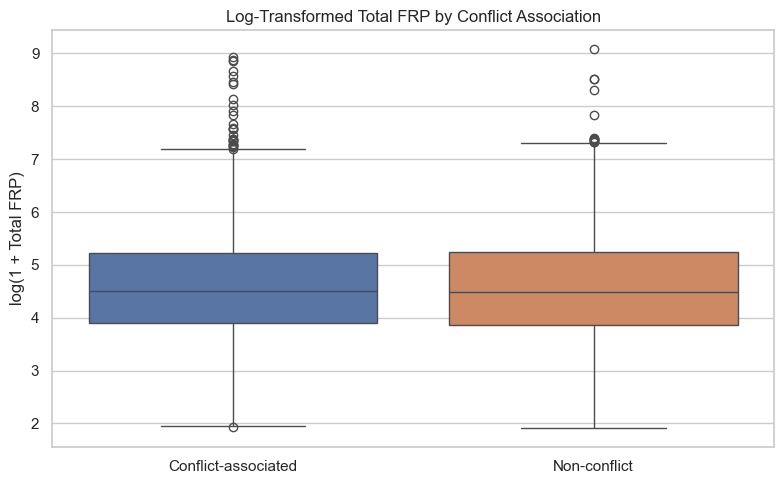

In [21]:
from scipy.stats import mannwhitneyu

te = thermal_events.copy()
te["event_id"] = te["event_id"].astype(str)
es = event_scores[["event_id", "conflict_associated"]].copy()
es["event_id"] = es["event_id"].astype(str)

test_df = te.merge(es, on="event_id", how="left")
test_df["conflict_associated"] = test_df["conflict_associated"].fillna(False)

g1 = test_df.loc[test_df["conflict_associated"] == True, "total_frp"].dropna()  # noqa: E712
g0 = test_df.loc[test_df["conflict_associated"] == False, "total_frp"].dropna()  # noqa: E712

u_stat, p_val = mannwhitneyu(g1, g0, alternative="two-sided")
print(f"Mann-Whitney U statistic: {u_stat:.3f}")
print(f"p-value: {p_val:.6f}")

if p_val > 0.05:
    print(
        "Interpretation: We fail to reject H0. There is no statistically significant evidence "
        "that total_frp distributions differ between conflict-associated and non-conflict thermal events."
    )
else:
    print("Interpretation: Reject H0 at alpha=0.05; total_frp distributions differ between groups.")

plot_df = test_df[["total_frp", "conflict_associated"]].dropna().copy()
plot_df["label"] = np.where(plot_df["conflict_associated"], "Conflict-associated", "Non-conflict")
plot_df["log_total_frp"] = np.log1p(plot_df["total_frp"])

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=plot_df,
    x="label",
    y="log_total_frp",
    hue="label",
    legend=False,
)
plt.title("Log-Transformed Total FRP by Conflict Association")
plt.xlabel("")
plt.ylabel("log(1 + Total FRP)")
plt.tight_layout()
plt.show()

**Interpretation:**

The Mann-Whitney U test does not show a statistically significant difference in total FRP distributions between conflict-associated and non-conflict events (when `p > 0.05`). This should not be interpreted as a failure of FIRMS data. Instead, it shows that raw thermal intensity alone is not sufficient to identify conflict association. High FRP values may also come from wildfires, industrial fires, agricultural burning, or gas flaring, while conflict-related events may be localized and short-lived. Therefore, the monitoring system relies on FIRMS-derived event features, spatial-temporal clustering, region/time patterns, and news-supported weak labels together.

## 10) Task 3 — Machine Learning Classification

- **Target:** news-supported `conflict_associated` label from final matching/scoring logic.
- **Features:** FIRMS-derived event features (FRP, duration, brightness, point count, day/night ratio, coordinates, region, month, season).
- **Models:** Random Forest (main), Logistic Regression (interpretable baseline), plus additional comparators.
- **Risk framing:** Recall is prioritized because missing a real conflict signal is costlier than investigating a false alarm.

**Operational threshold policy (final):** optimize Random Forest with a recall constraint.
- Step 1: keep thresholds with `recall >= 0.80`
- Step 2: among those, choose the highest F1
- Current selected operating point: `random_forest`, threshold `0.3`

This keeps the modeling objective satellite-first: ML learns from FIRMS event structure, while news contributes weak labels/context for supervision.

,variant,model,accuracy,precision,recall,f1
0,full,random_forest,0.712329,0.654545,0.662577,0.658537
1,full,svc_rbf,0.702911,0.638132,0.670757,0.654038
2,full,logistic_regression,0.686644,0.624242,0.631902,0.628049
3,full,decision_tree,0.686644,0.626283,0.623722,0.625000
4,full,gaussian_nb,0.504281,0.456897,0.975460,0.622309


,variant,model,best_threshold_f1,best_f1,best_threshold_recall_ge_085,f1_at_recall_ge_085,recall_at_recall_ge_085
0,full,logistic_regression,0.4,0.662752,0.3,0.636037,0.905930
1,full,decision_tree,0.4,0.644269,0.3,0.617172,0.977505
2,full,random_forest,0.4,0.668407,0.3,0.665663,0.903885
3,full,svc_rbf,0.4,0.658203,0.2,0.595355,0.995910
4,full,gaussian_nb,0.9,0.622309,0.9,0.622309,0.975460
5,no_geography,logistic_regression,0.5,0.605795,0.4,0.601085,0.905930
6,no_geography,random_forest,0.4,0.621469,0.3,0.614951,0.891616


,variant,model,threshold,accuracy,precision,recall,f1
0,full,logistic_regression,1.0,0.581336,0.000000,0.000000,0.000000
1,full,logistic_regression,0.9,0.581336,0.000000,0.000000,0.000000
2,full,logistic_regression,0.8,0.603596,0.760000,0.077710,0.141002
3,full,logistic_regression,0.7,0.686644,0.689231,0.458078,0.550369
4,full,logistic_regression,0.6,0.690068,0.663239,0.527607,0.587699
5,full,logistic_regression,0.5,0.686644,0.624242,0.631902,0.628049
6,full,logistic_regression,0.4,0.655822,0.561878,0.807771,0.662752
7,full,logistic_regression,0.3,0.565925,0.490044,0.905930,0.636037
8,full,logistic_regression,0.2,0.484589,0.447926,0.993865,0.617535
9,full,logistic_regression,0.1,0.430651,0.423611,0.997955,0.594759


,feature,importance,abs_importance
0,num__centroid_longitude,0.195181,0.195181
1,num__centroid_latitude,0.189224,0.189224
2,num__total_frp,0.117385,0.117385
3,num__month,0.115521,0.115521
4,num__detection_points,0.069693,0.069693
5,num__day_night_ratio,0.054565,0.054565
6,cat__region_red_sea,0.046054,0.046054
7,cat__region_sahara_control,0.037810,0.037810
8,cat__region_black_sea,0.035712,0.035712
9,cat__season_winter,0.029551,0.029551


,feature,importance,abs_importance
0,num__total_frp,0.402394,0.402394
1,num__day_night_ratio,0.164871,0.164871
2,num__detection_points,0.158084,0.158084
3,num__month,0.139635,0.139635
4,num__duration_days,0.063659,0.063659
5,cat__season_winter,0.031089,0.031089
6,cat__season_summer,0.017359,0.017359
7,cat__season_spring,0.012316,0.012316
8,cat__season_autumn,0.010593,0.010593
9,num__max_brightness,0.000000,0.000000


Operational tuned model metrics


,model,threshold_policy,threshold,accuracy,precision,recall,f1
0,random_forest,recall_constrained_f1 (recall>=0.80),0.3,0.619863,0.526818,0.903885,0.665663


Random Forest @ threshold=0.3


,threshold,accuracy,precision,recall,f1
29,0.3,0.619863,0.526818,0.903885,0.665663


**ML comparison: F1 / Recall / Precision**

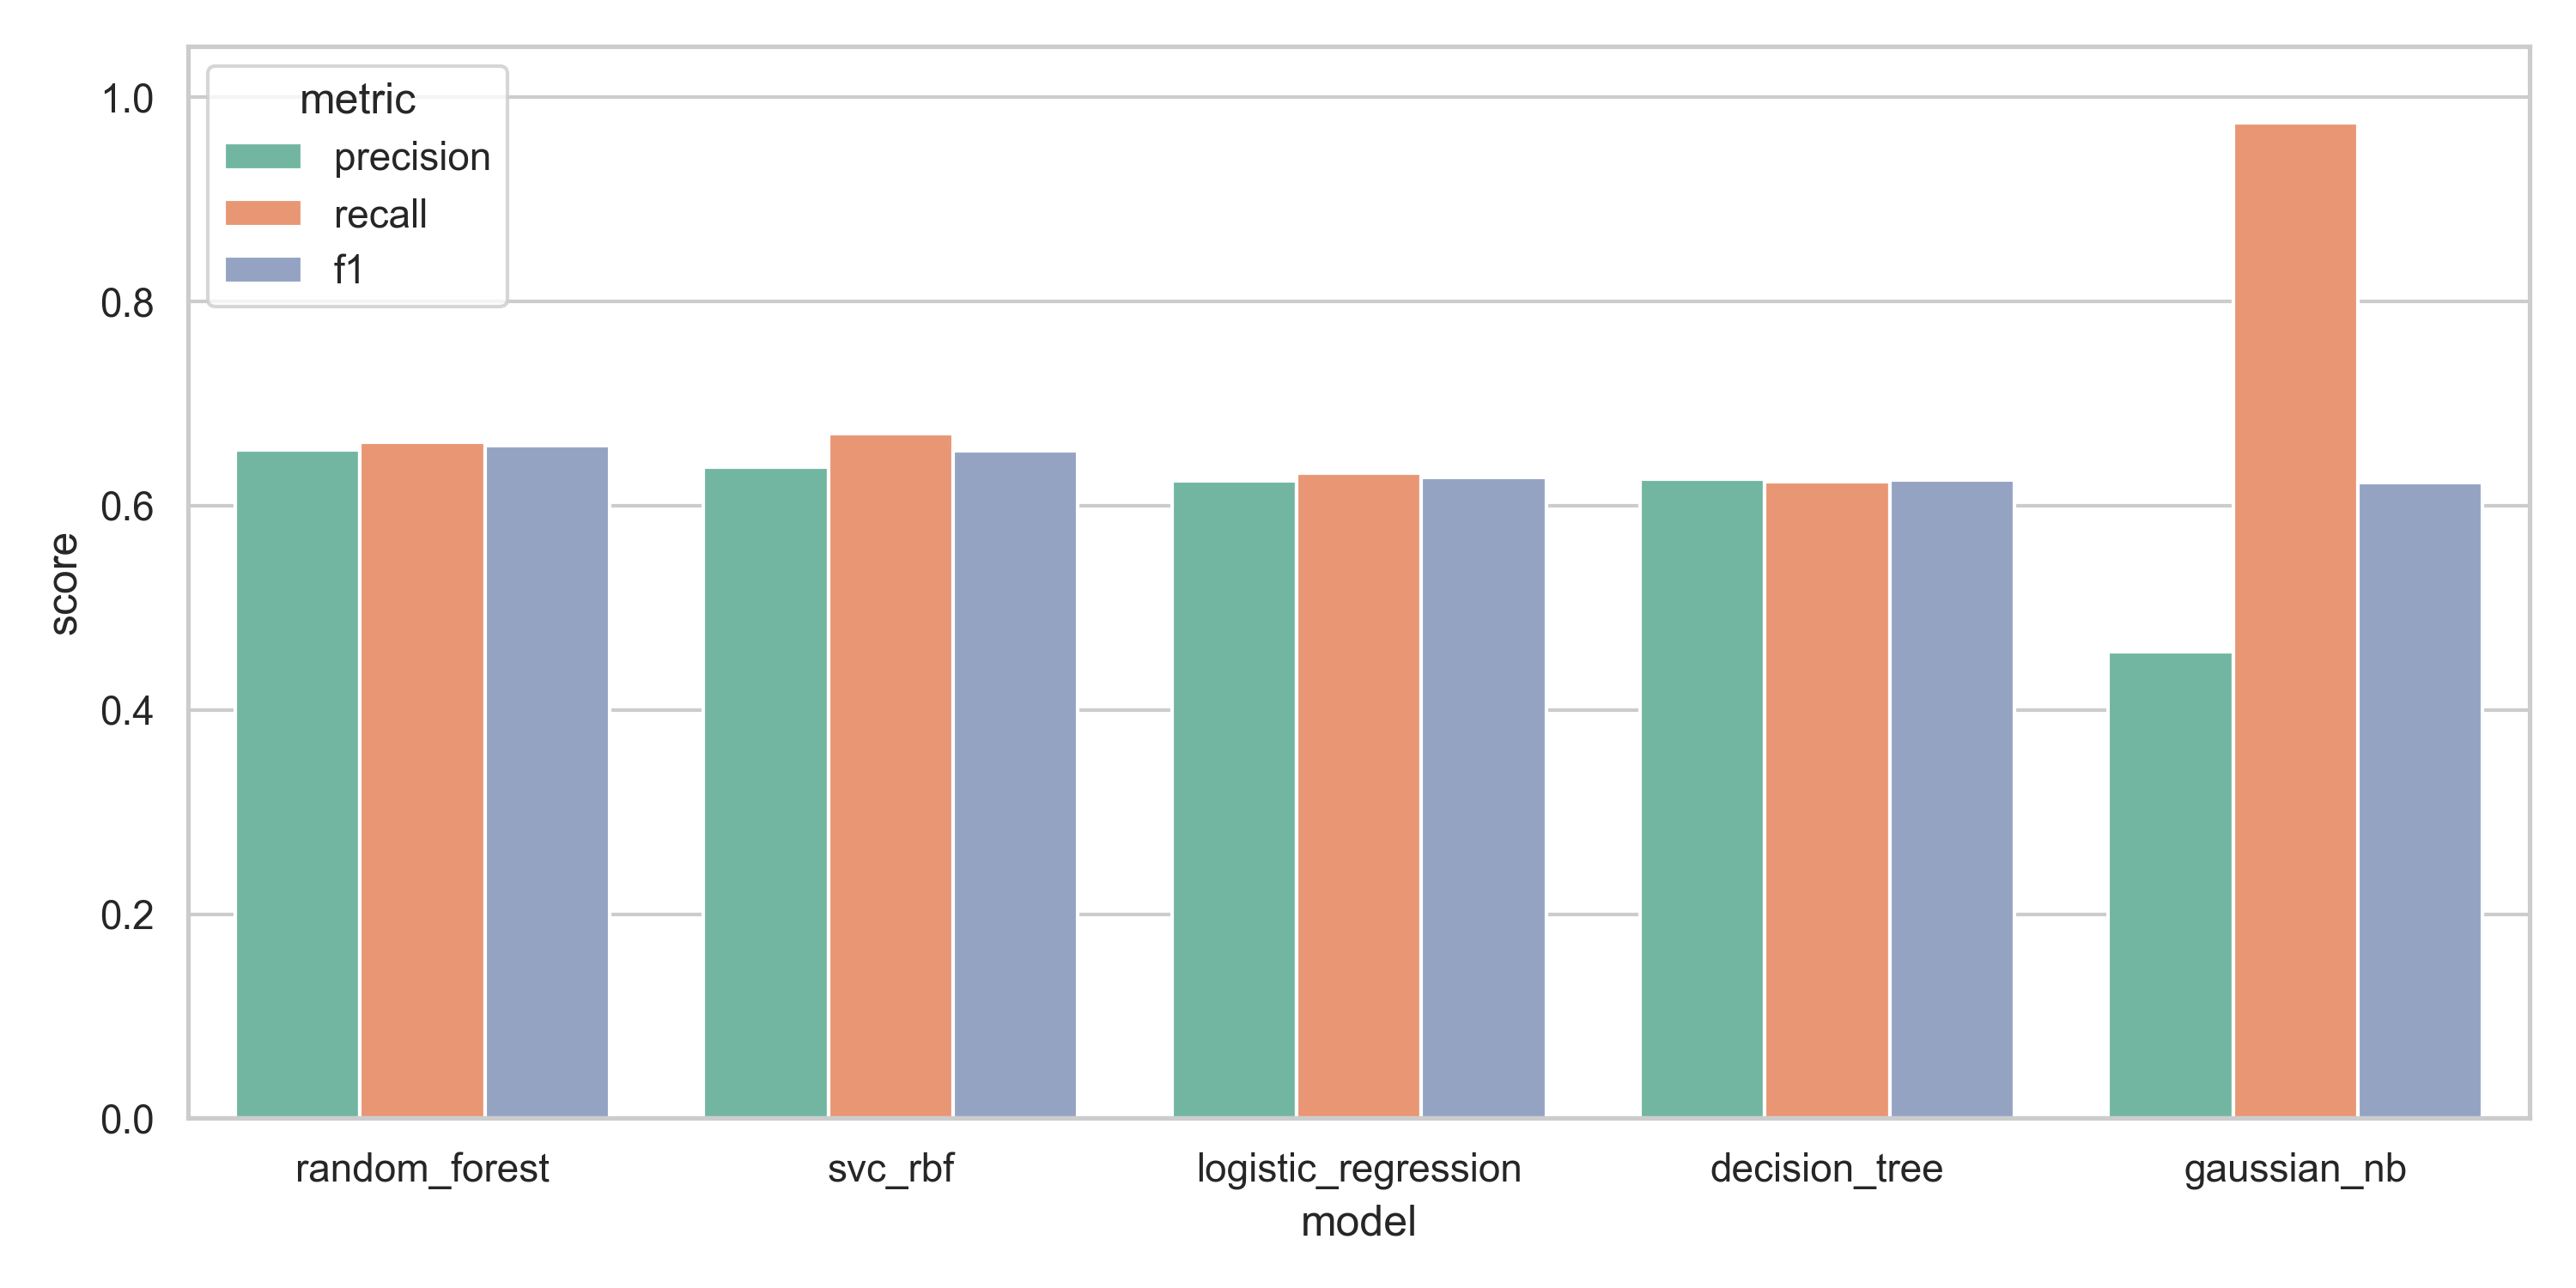

**Geography robustness: full vs no-geography**

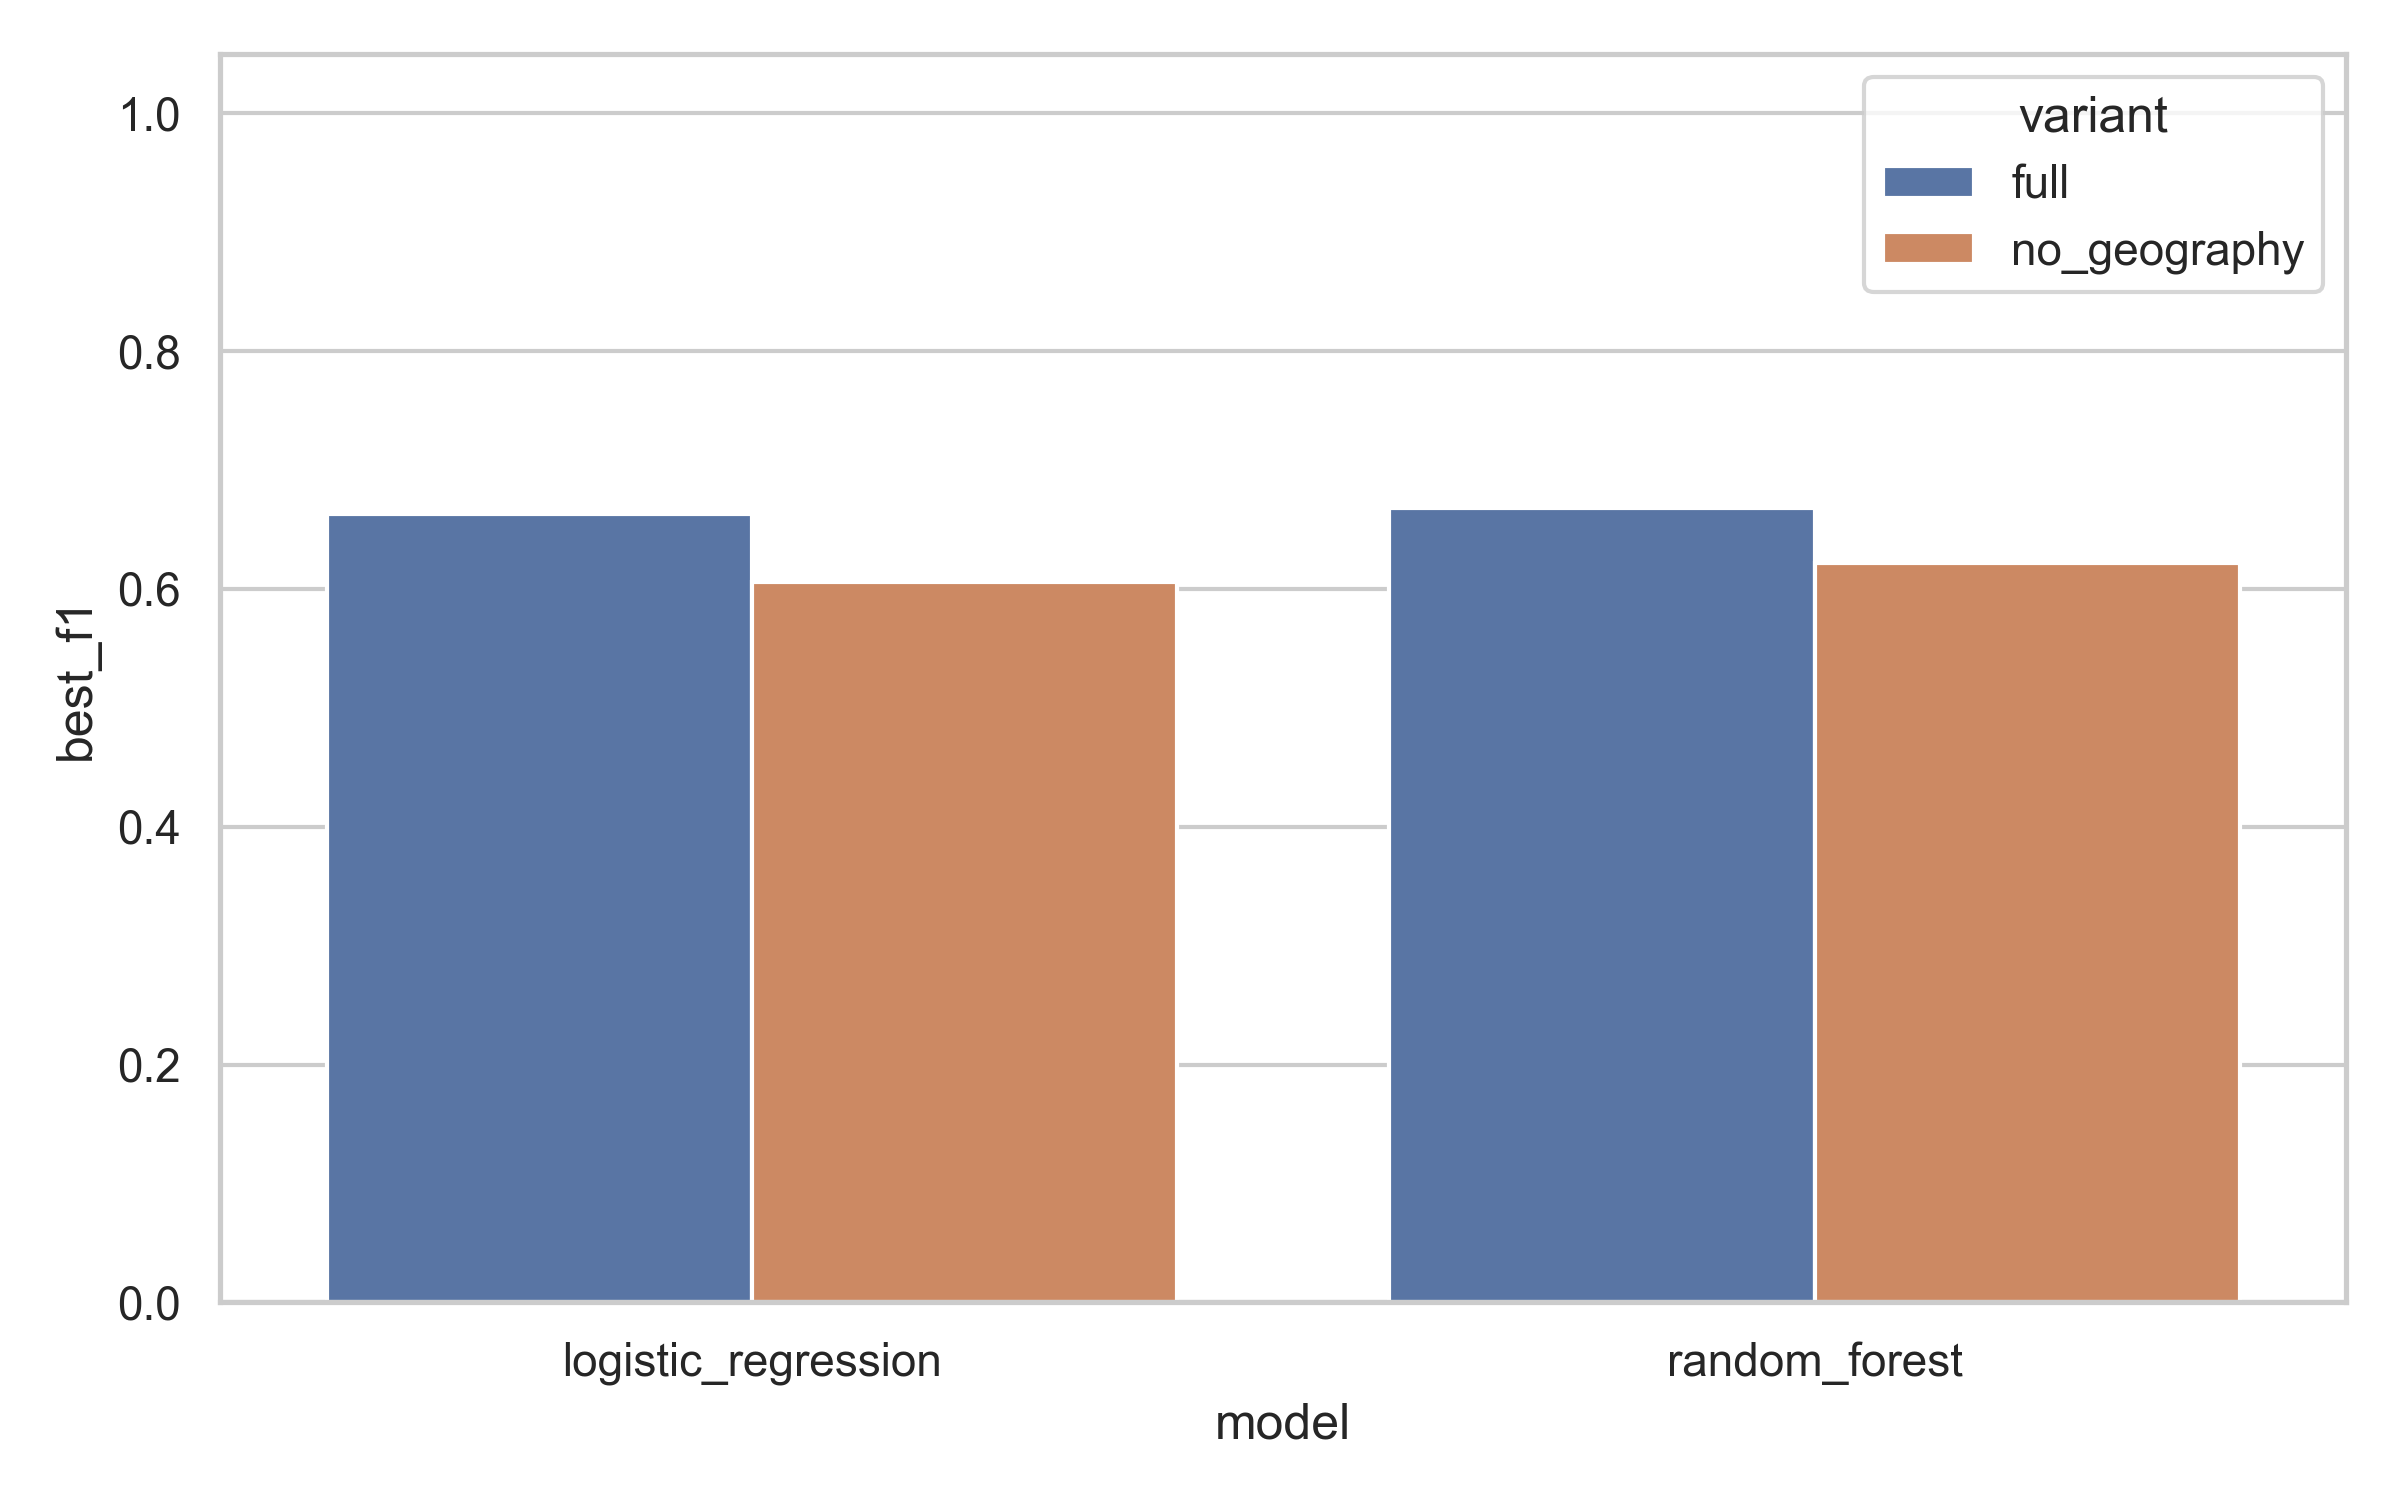

**Random Forest feature importance (full)**

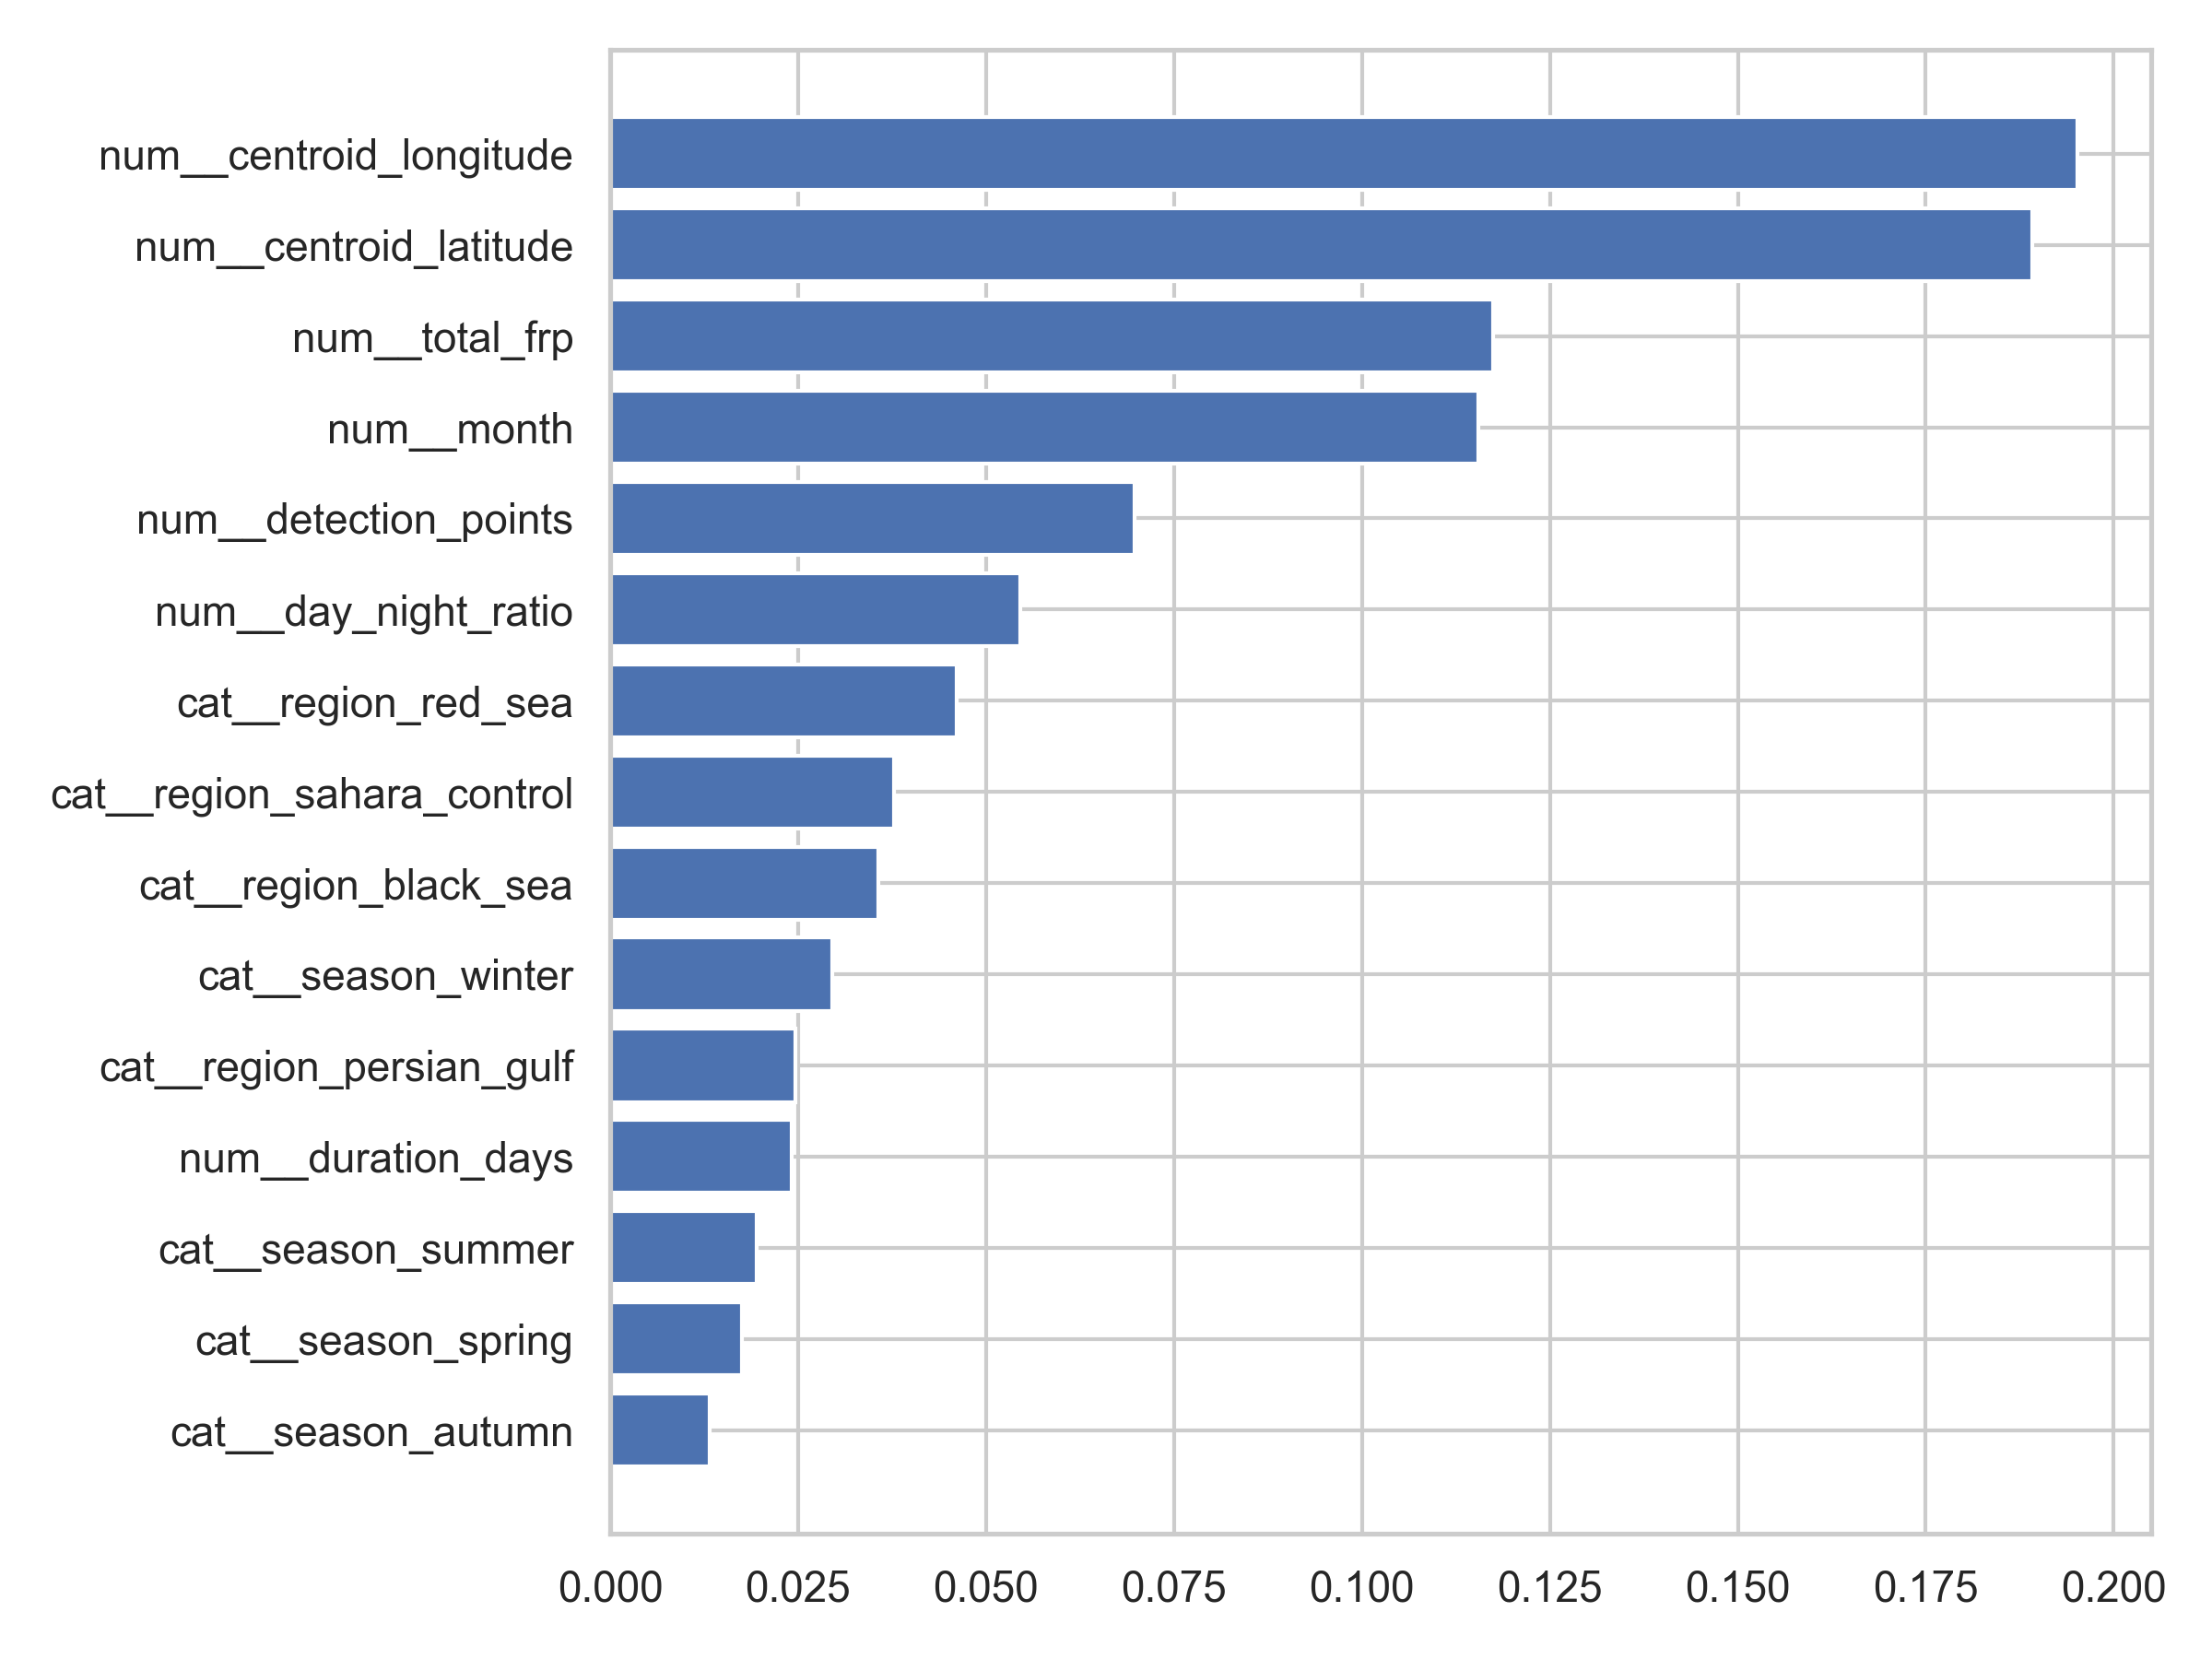

**Random Forest tuned confusion matrix (recall-constrained threshold)**

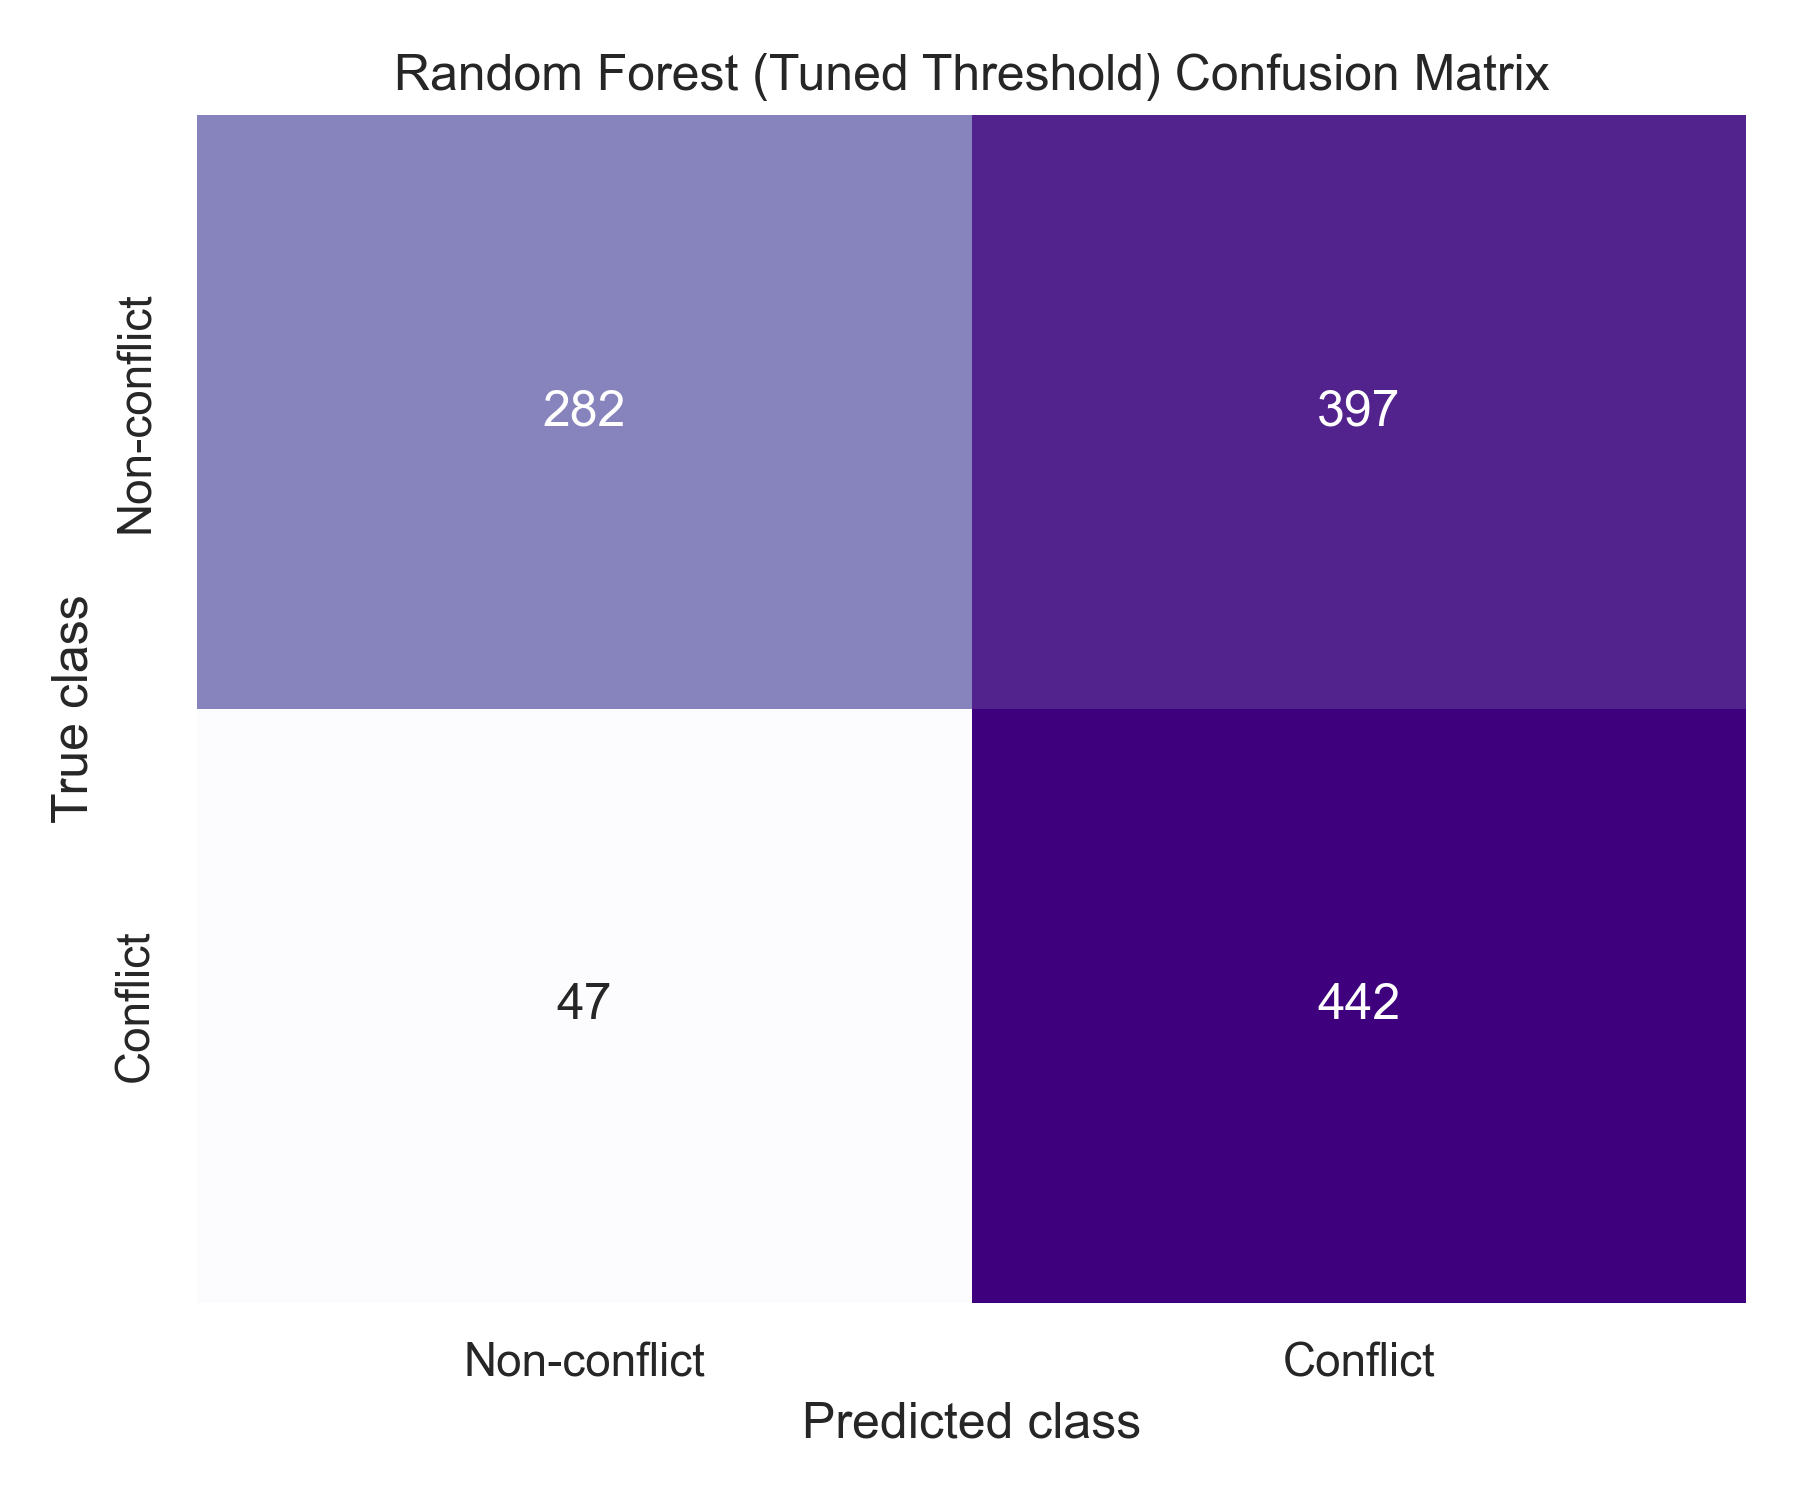

In [22]:
ml_model_cmp = load_csv("ml_model_comparison_full.csv")
ml_geo_cmp = load_csv("ml_geography_robustness_comparison.csv")
ml_thr = load_csv("ml_threshold_sweep_by_variant.csv")
ml_rf_imp = load_csv("ml_feature_importance_full_random_forest.csv")
ml_rf_imp_nogeo = load_csv("ml_feature_importance_no_geography_random_forest.csv")
ml_tuned = load_csv("task3_best_tuned_model_metrics.csv")

display(ml_model_cmp)
display(ml_geo_cmp)
display(ml_thr.head(20))
display(ml_rf_imp.head(20))
display(ml_rf_imp_nogeo.head(20))

print("Operational tuned model metrics")
display(ml_tuned)

rf_thr = ml_thr[(ml_thr["variant"] == "full") & (ml_thr["model"] == "random_forest")].copy()
rf_thr = rf_thr.sort_values("threshold", ascending=False)
rf_operational = rf_thr[rf_thr["threshold"].round(3) == 0.3]
print("Random Forest @ threshold=0.3")
display(rf_operational[["threshold", "accuracy", "precision", "recall", "f1"]])

display_png(resolve_output_path("ml_model_comparison_f1_recall_precision.png"), "ML comparison: F1 / Recall / Precision")
display_png(resolve_output_path("ml_geography_robustness_f1_recall.png"), "Geography robustness: full vs no-geography")
display_png(resolve_output_path("ml_random_forest_feature_importance_full.png"), "Random Forest feature importance (full)")
display_png(resolve_output_path("ml_confusion_matrix_random_forest_tuned.png"), "Random Forest tuned confusion matrix (recall-constrained threshold)")

**ML interpretation:**
- Random Forest remains the operational model.
- Final operating threshold uses recall-constrained selection and is set to `0.3` for Random Forest (`recall ~0.90`, `precision ~0.53`, `F1 ~0.67`).
- Logistic Regression remains the interpretable baseline.
- Full vs no-geography comparison quantifies geography dependence rather than assuming it.
- Non-geographic physical/time features still contribute meaningful signal.

## 11) Task 3/4 — Drift Monitoring and Retraining Trigger Framework

Conflict regimes and media behavior evolve over time. We monitor whether the relationship between FIRMS-derived event features and news-supported labels remains stable.

This is explicitly a **retraining-trigger framework, not automatic deployment**.

,year_month,n_samples,positive_rate,accuracy,precision,recall,f1,mean_event_score,median_event_score,mean_predicted_probability
0,2024-06,41.0,0.048780,0.463415,0.083333,1.000000,0.153846,0.176598,0.000000,0.371983
1,2024-07,29.0,0.275862,0.827586,0.615385,1.000000,0.761905,1.088284,0.000000,0.468910
2,2024-08,42.0,0.166667,0.738095,0.250000,0.285714,0.266667,0.618256,0.000000,0.213893
3,2024-09,35.0,0.142857,0.514286,0.227273,1.000000,0.370370,0.652519,0.000000,0.378362
4,2024-10,21.0,0.190476,0.333333,0.222222,1.000000,0.363636,0.749095,0.000000,0.445053
5,2024-11,16.0,0.250000,0.500000,0.300000,0.750000,0.428571,1.162299,0.000000,0.319720
6,2024-12,50.0,0.340000,0.480000,0.395349,1.000000,0.566667,1.572521,0.000000,0.521092
7,2025-01,52.0,0.211538,0.269231,0.224490,1.000000,0.366667,0.832599,0.000000,0.508838
8,2025-02,59.0,0.271186,0.288136,0.275862,1.000000,0.432432,1.095545,0.000000,0.559877
9,2025-03,75.0,0.480000,0.613333,0.553846,1.000000,0.712871,2.222982,0.000000,0.595830


,period_end,window_days,n_samples,positive_rate,accuracy,precision,recall,f1,mean_event_score,median_event_score,mean_predicted_probability
0,2024-06-13,30,21,0.0,0.428571,0.0,0.0,0.0,0.0,0.0,0.362591
1,2024-06-14,30,21,0.0,0.428571,0.0,0.0,0.0,0.0,0.0,0.362591
2,2024-06-15,30,21,0.0,0.428571,0.0,0.0,0.0,0.0,0.0,0.362591
3,2024-06-16,30,21,0.0,0.428571,0.0,0.0,0.0,0.0,0.0,0.362591
4,2024-06-17,30,23,0.0,0.434783,0.0,0.0,0.0,0.0,0.0,0.366717
5,2024-06-18,30,25,0.0,0.480000,0.0,0.0,0.0,0.0,0.0,0.356368
6,2024-06-19,30,27,0.0,0.444444,0.0,0.0,0.0,0.0,0.0,0.361374
7,2024-06-20,30,27,0.0,0.444444,0.0,0.0,0.0,0.0,0.0,0.361374
8,2024-06-21,30,27,0.0,0.444444,0.0,0.0,0.0,0.0,0.0,0.361374
9,2024-06-22,30,27,0.0,0.444444,0.0,0.0,0.0,0.0,0.0,0.361374


,period_end,window_days,n_samples,positive_rate,accuracy,precision,recall,f1,mean_event_score,median_event_score,mean_predicted_probability
0,2024-06-13,60,21,0.0,0.428571,0.0,0.0,0.0,0.0,0.0,0.362591
1,2024-06-14,60,21,0.0,0.428571,0.0,0.0,0.0,0.0,0.0,0.362591
2,2024-06-15,60,21,0.0,0.428571,0.0,0.0,0.0,0.0,0.0,0.362591
3,2024-06-16,60,21,0.0,0.428571,0.0,0.0,0.0,0.0,0.0,0.362591
4,2024-06-17,60,23,0.0,0.434783,0.0,0.0,0.0,0.0,0.0,0.366717
5,2024-06-18,60,25,0.0,0.480000,0.0,0.0,0.0,0.0,0.0,0.356368
6,2024-06-19,60,27,0.0,0.444444,0.0,0.0,0.0,0.0,0.0,0.361374
7,2024-06-20,60,27,0.0,0.444444,0.0,0.0,0.0,0.0,0.0,0.361374
8,2024-06-21,60,27,0.0,0.444444,0.0,0.0,0.0,0.0,0.0,0.361374
9,2024-06-22,60,27,0.0,0.444444,0.0,0.0,0.0,0.0,0.0,0.361374


,year_month,region,n_samples,positive_rate,accuracy,precision,recall,f1,mean_event_score,median_event_score,mean_predicted_probability,event_count
0,2024-06,black_sea,3.0,0.666667,0.666667,0.666667,1.0,0.800000,2.413500,3.245250,0.748728,3.0
1,2024-06,eastern_med,9.0,0.000000,0.222222,0.000000,0.0,0.000000,0.000000,0.000000,0.450077,9.0
2,2024-06,persian_gulf,24.0,0.000000,0.458333,0.000000,0.0,0.000000,0.000000,0.000000,0.317470,24.0
3,2024-06,red_sea,1.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.745152,1.0
4,2024-06,sahara_control,4.0,0.000000,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.147493,4.0
5,2024-07,black_sea,12.0,0.583333,0.583333,0.583333,1.0,0.736842,2.359583,3.995250,0.871909,12.0
6,2024-07,eastern_med,1.0,1.000000,1.000000,1.000000,1.0,1.000000,3.245250,3.245250,0.335369,1.0
7,2024-07,persian_gulf,14.0,0.000000,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.170890,14.0
8,2024-07,sahara_control,2.0,0.000000,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.203828,2.0
9,2024-08,black_sea,8.0,0.250000,0.250000,0.250000,1.0,0.400000,0.967562,0.000000,0.537985,8.0


,period,region,n_samples,positive_rate,previous_baseline_positive_rate,baseline_sample_size,baseline_nonempty_months,sufficient_sample,insufficient_sample,insufficient_sample_reason,...,precision,recall,f1,mean_predicted_probability,trigger_low_recall,trigger_low_f1_2months,trigger_positive_rate_shift,trigger_event_count_spike,trigger_prediction_shift,retraining_recommended
0,2024-06,ALL,41.0,0.048780,NaN,0,0,True,False,NaN,...,0.083333,1.000000,0.153846,0.371983,False,False,False,False,False,False
1,2024-07,ALL,29.0,0.275862,0.048780,41,1,False,True,n_samples<30,...,0.615385,1.000000,0.761905,0.468910,False,False,False,False,False,False
2,2024-08,ALL,42.0,0.166667,0.162321,70,2,True,False,NaN,...,0.250000,0.285714,0.266667,0.213893,True,False,False,False,True,True
3,2024-09,ALL,35.0,0.142857,0.163770,112,3,True,False,NaN,...,0.227273,1.000000,0.370370,0.378362,False,True,False,False,False,True
4,2024-10,ALL,21.0,0.190476,0.195129,106,4,False,True,n_samples<30,...,0.222222,1.000000,0.363636,0.445053,False,False,False,False,False,False
5,2024-11,ALL,16.0,0.250000,0.166667,98,5,False,True,n_samples<30,...,0.300000,0.750000,0.428571,0.319720,False,False,False,False,False,False
6,2024-12,ALL,50.0,0.340000,0.194444,72,6,True,False,NaN,...,0.395349,1.000000,0.566667,0.521092,False,True,False,False,False,True
7,2025-01,ALL,52.0,0.211538,0.260159,87,6,True,False,NaN,...,0.224490,1.000000,0.366667,0.508838,False,True,False,False,False,True
8,2025-02,ALL,59.0,0.271186,0.267179,118,6,True,False,NaN,...,0.275862,1.000000,0.432432,0.559877,False,True,False,False,False,True
9,2025-03,ALL,75.0,0.480000,0.274242,161,6,True,False,NaN,...,0.553846,1.000000,0.712871,0.595830,False,False,False,False,False,False


**Monthly drift: F1 and recall**

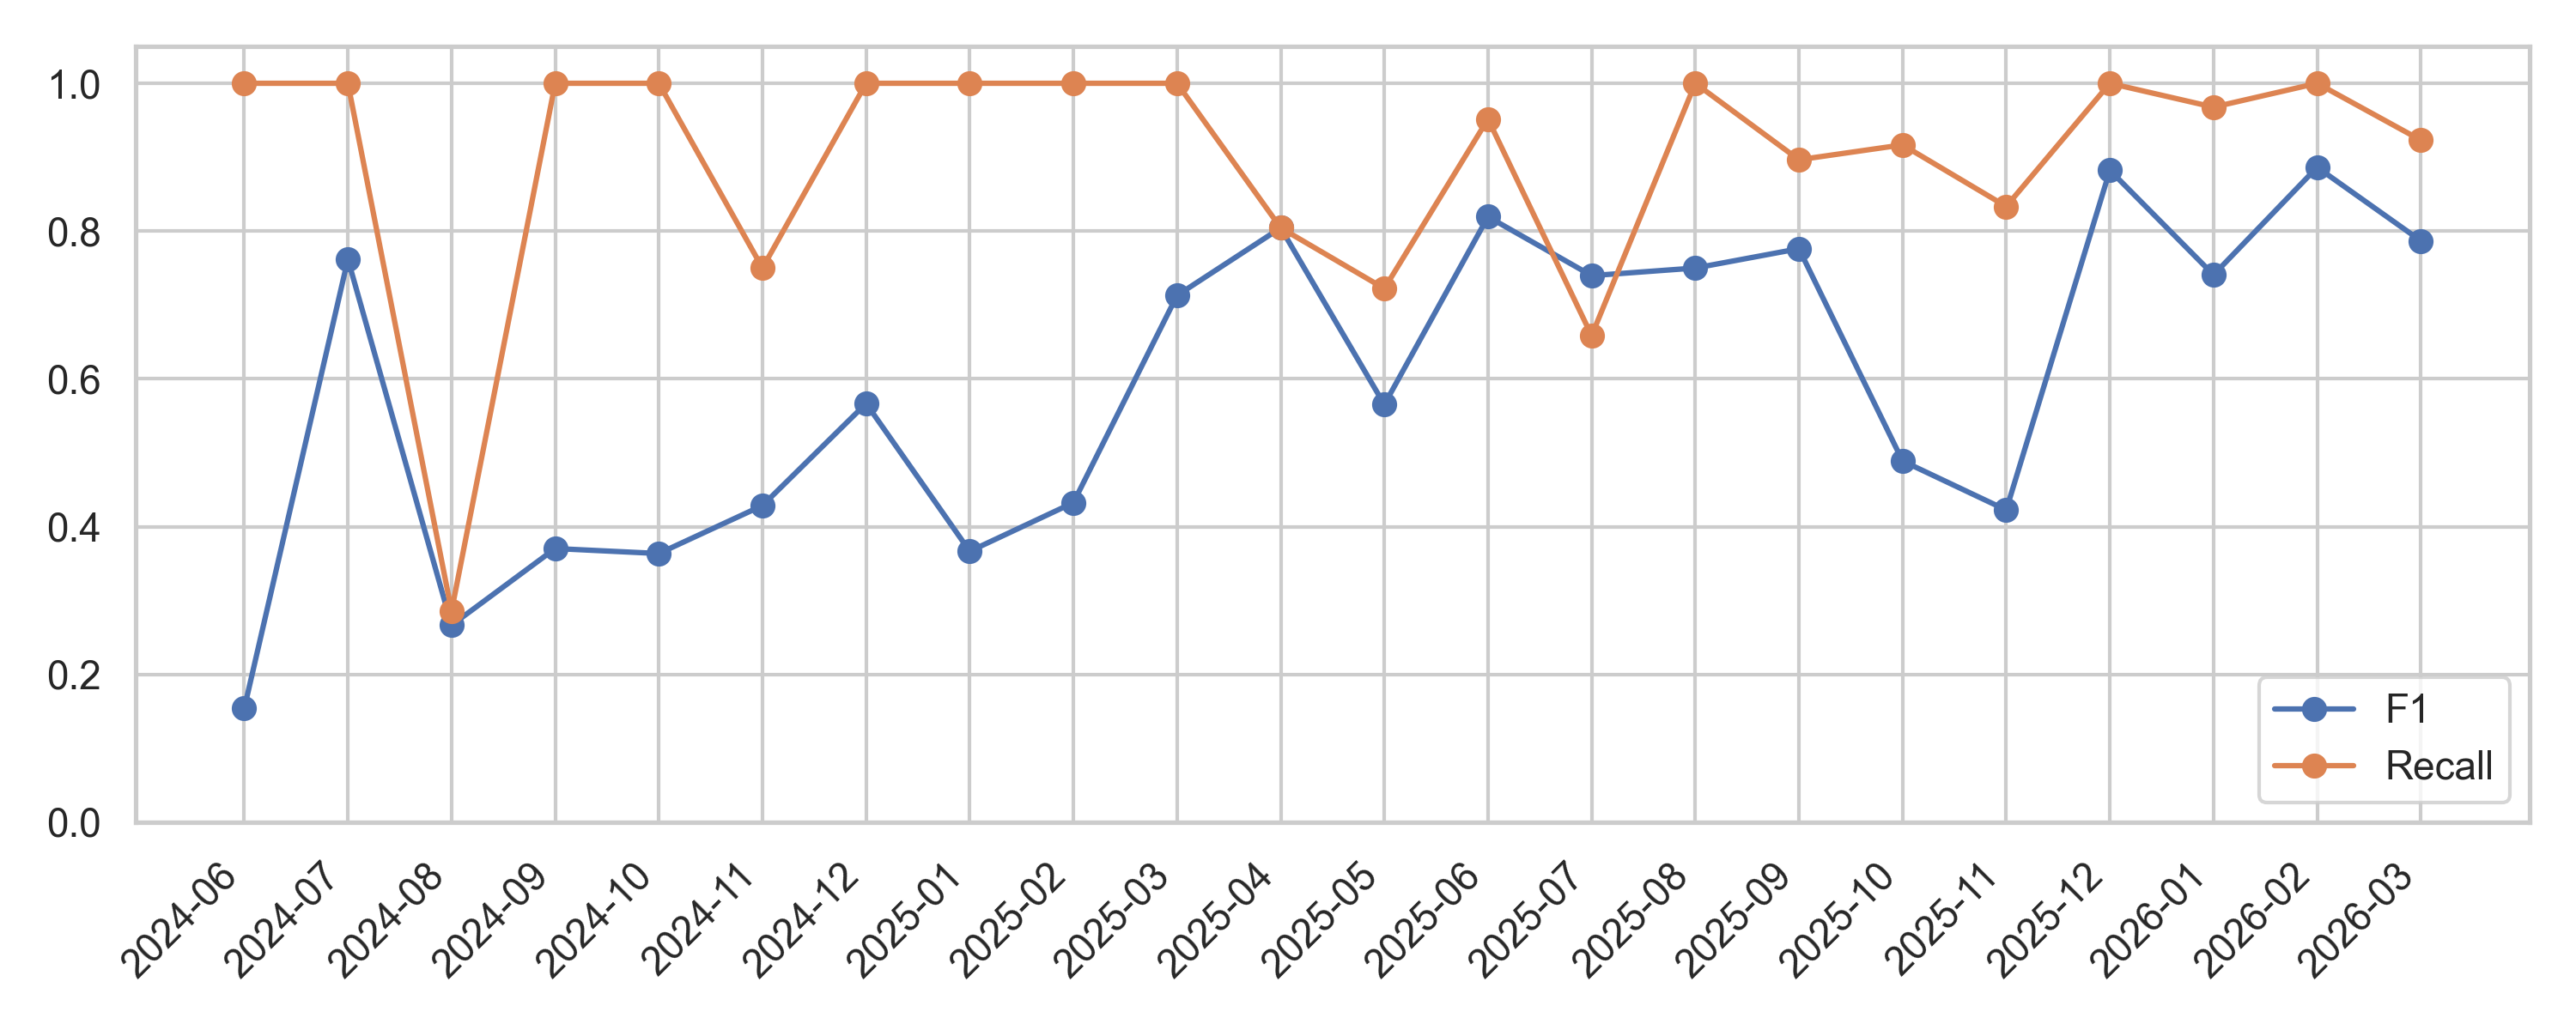

**Monthly drift: positive rate**

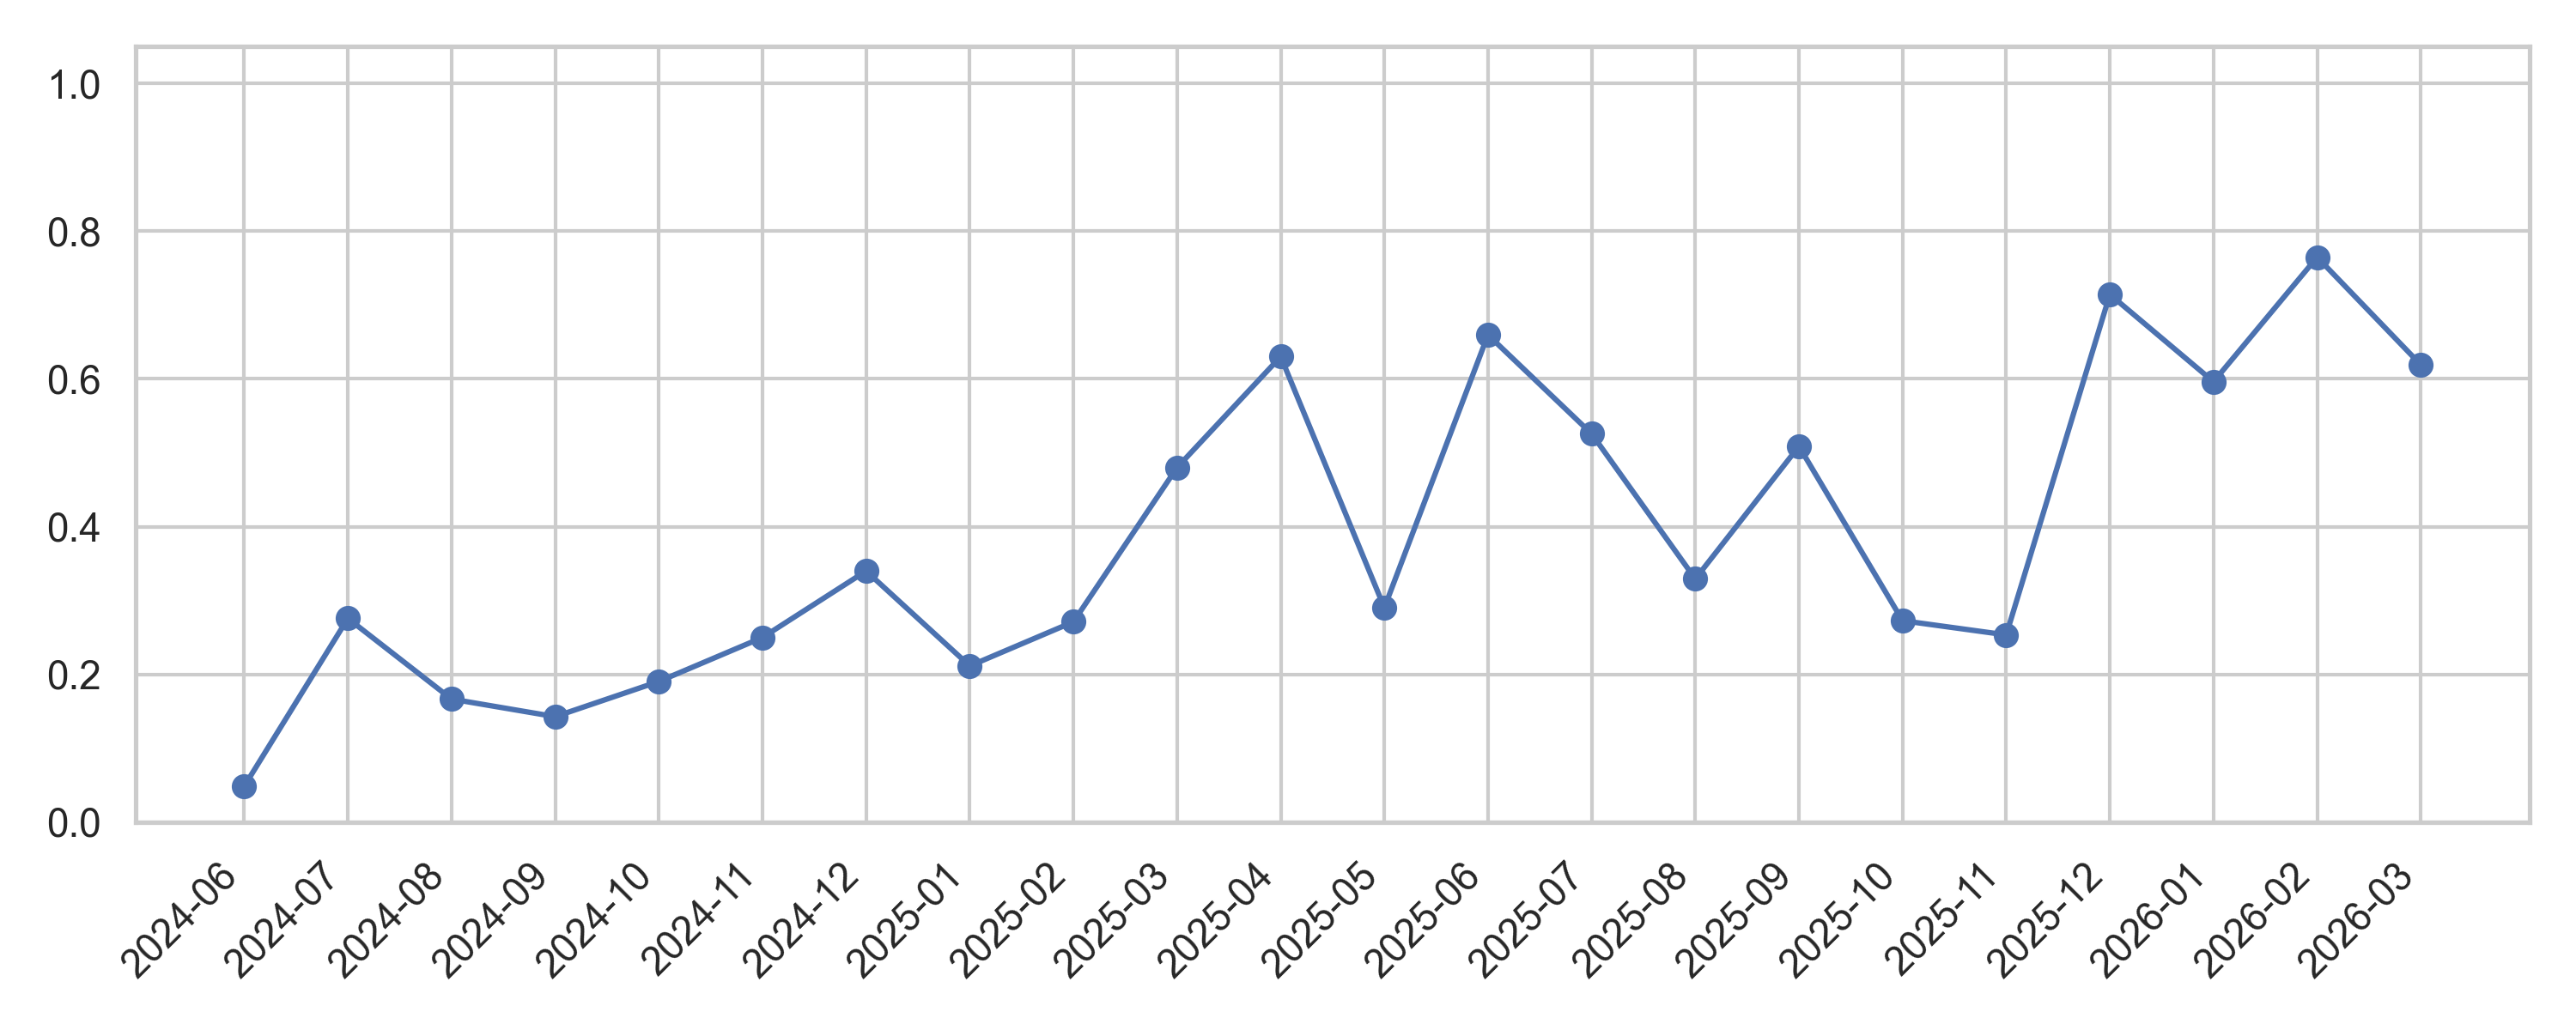

**Region-level positive rate heatmap**

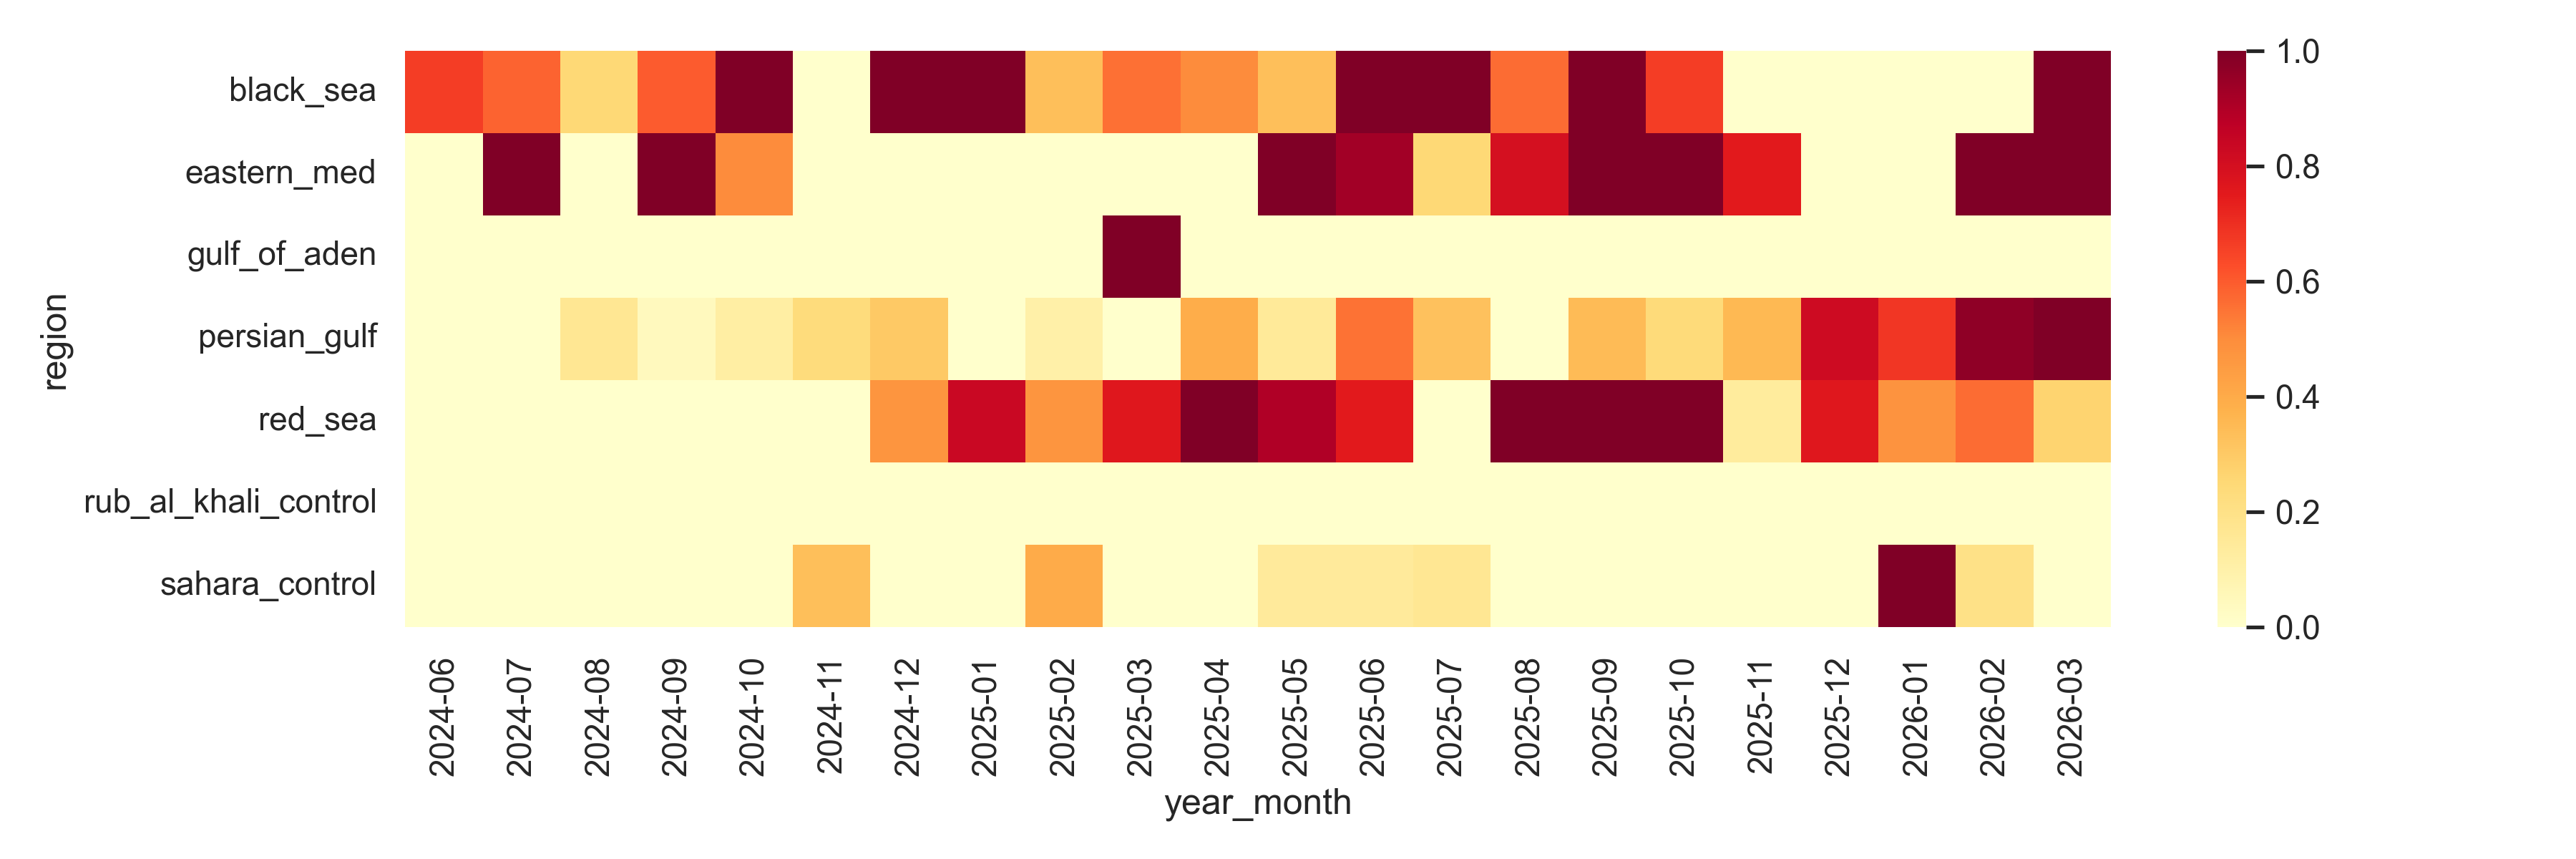

**Retraining trigger timeline**

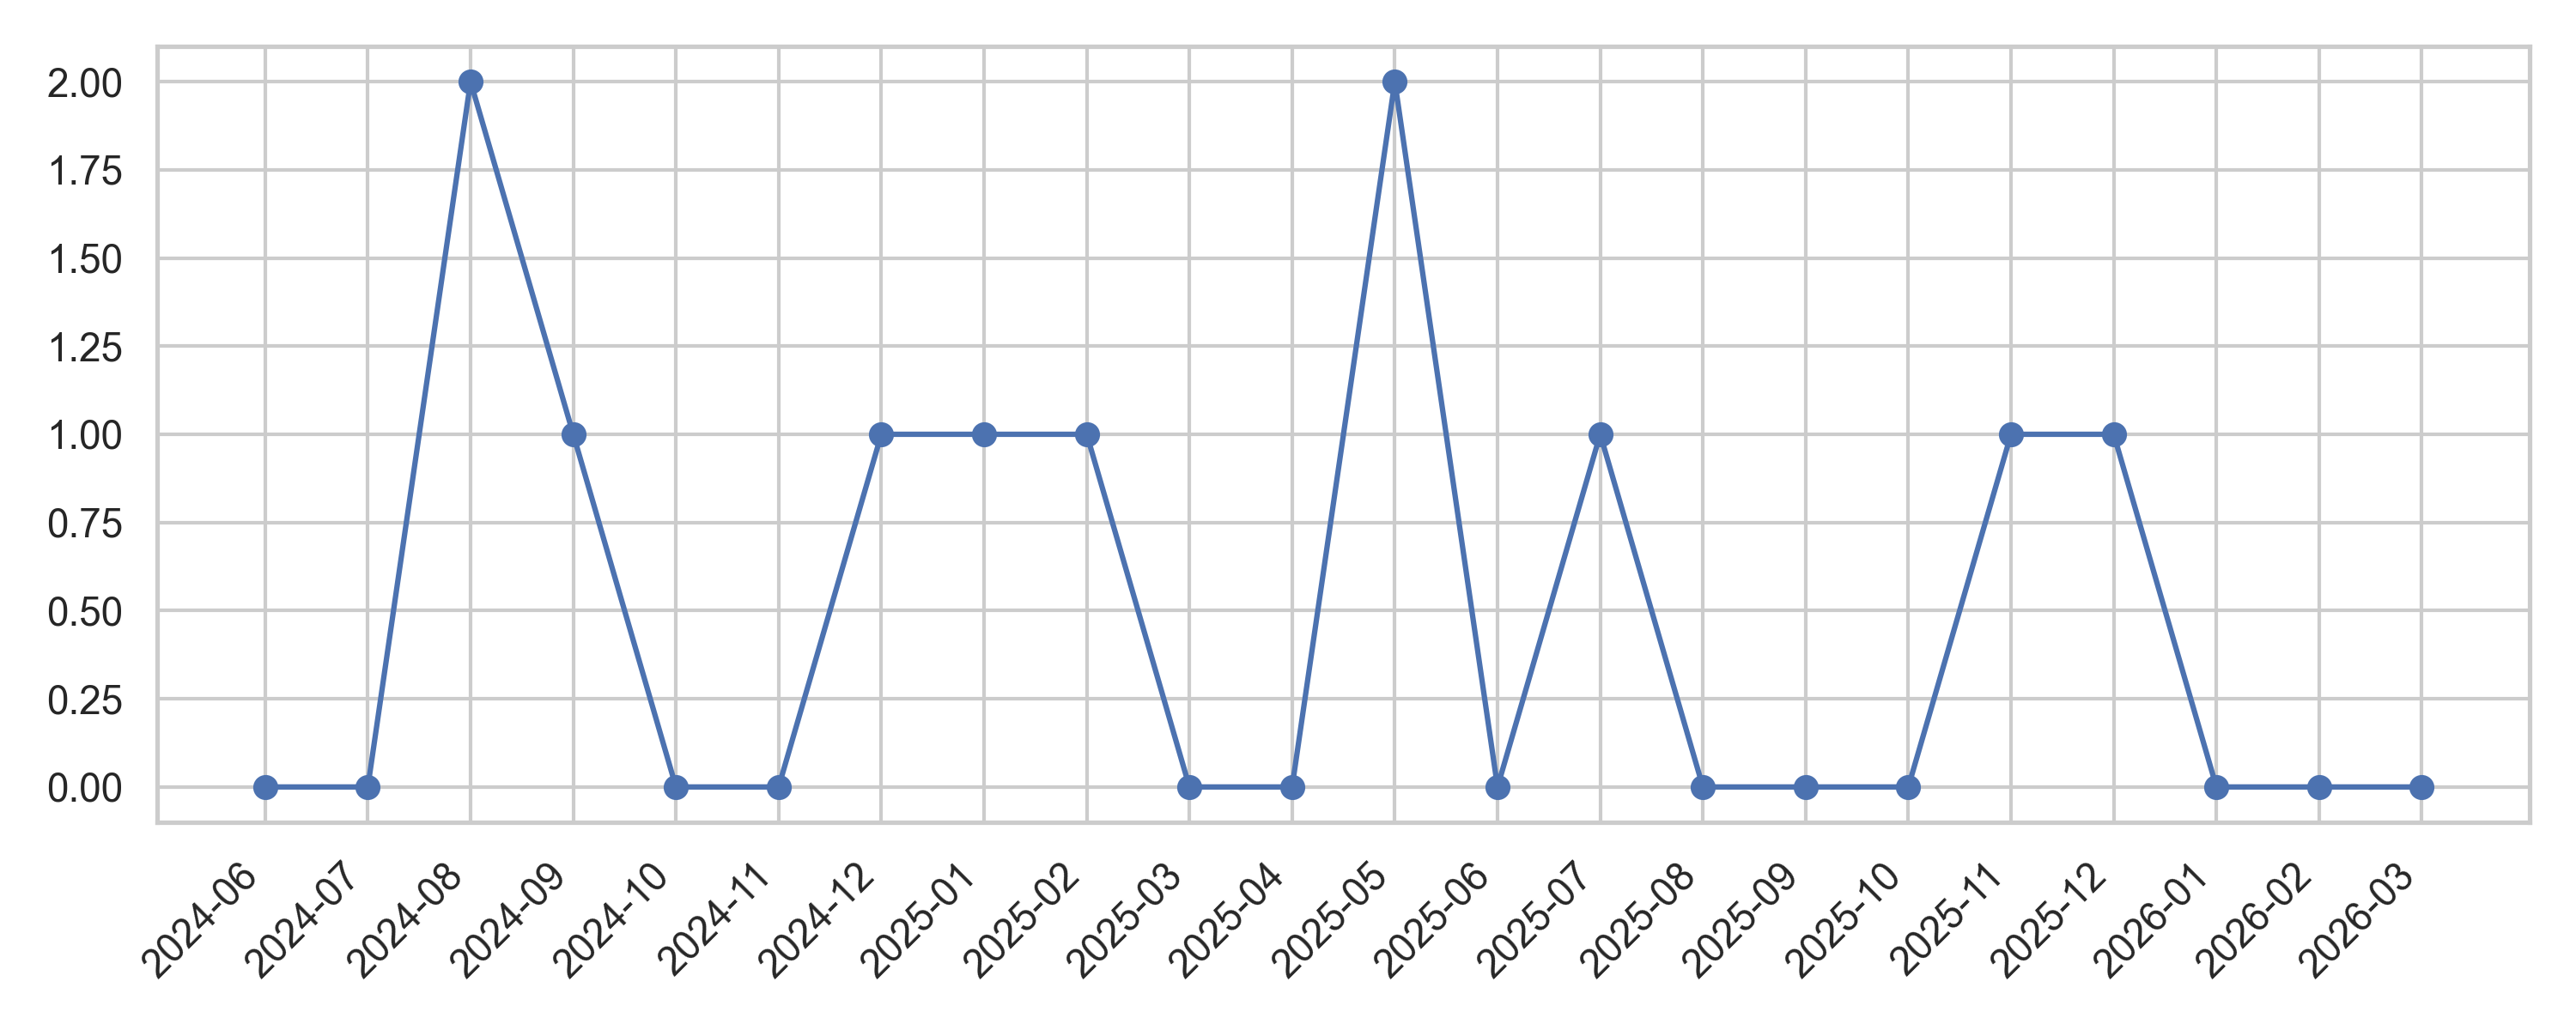

**Rolling 30d vs 60d F1**

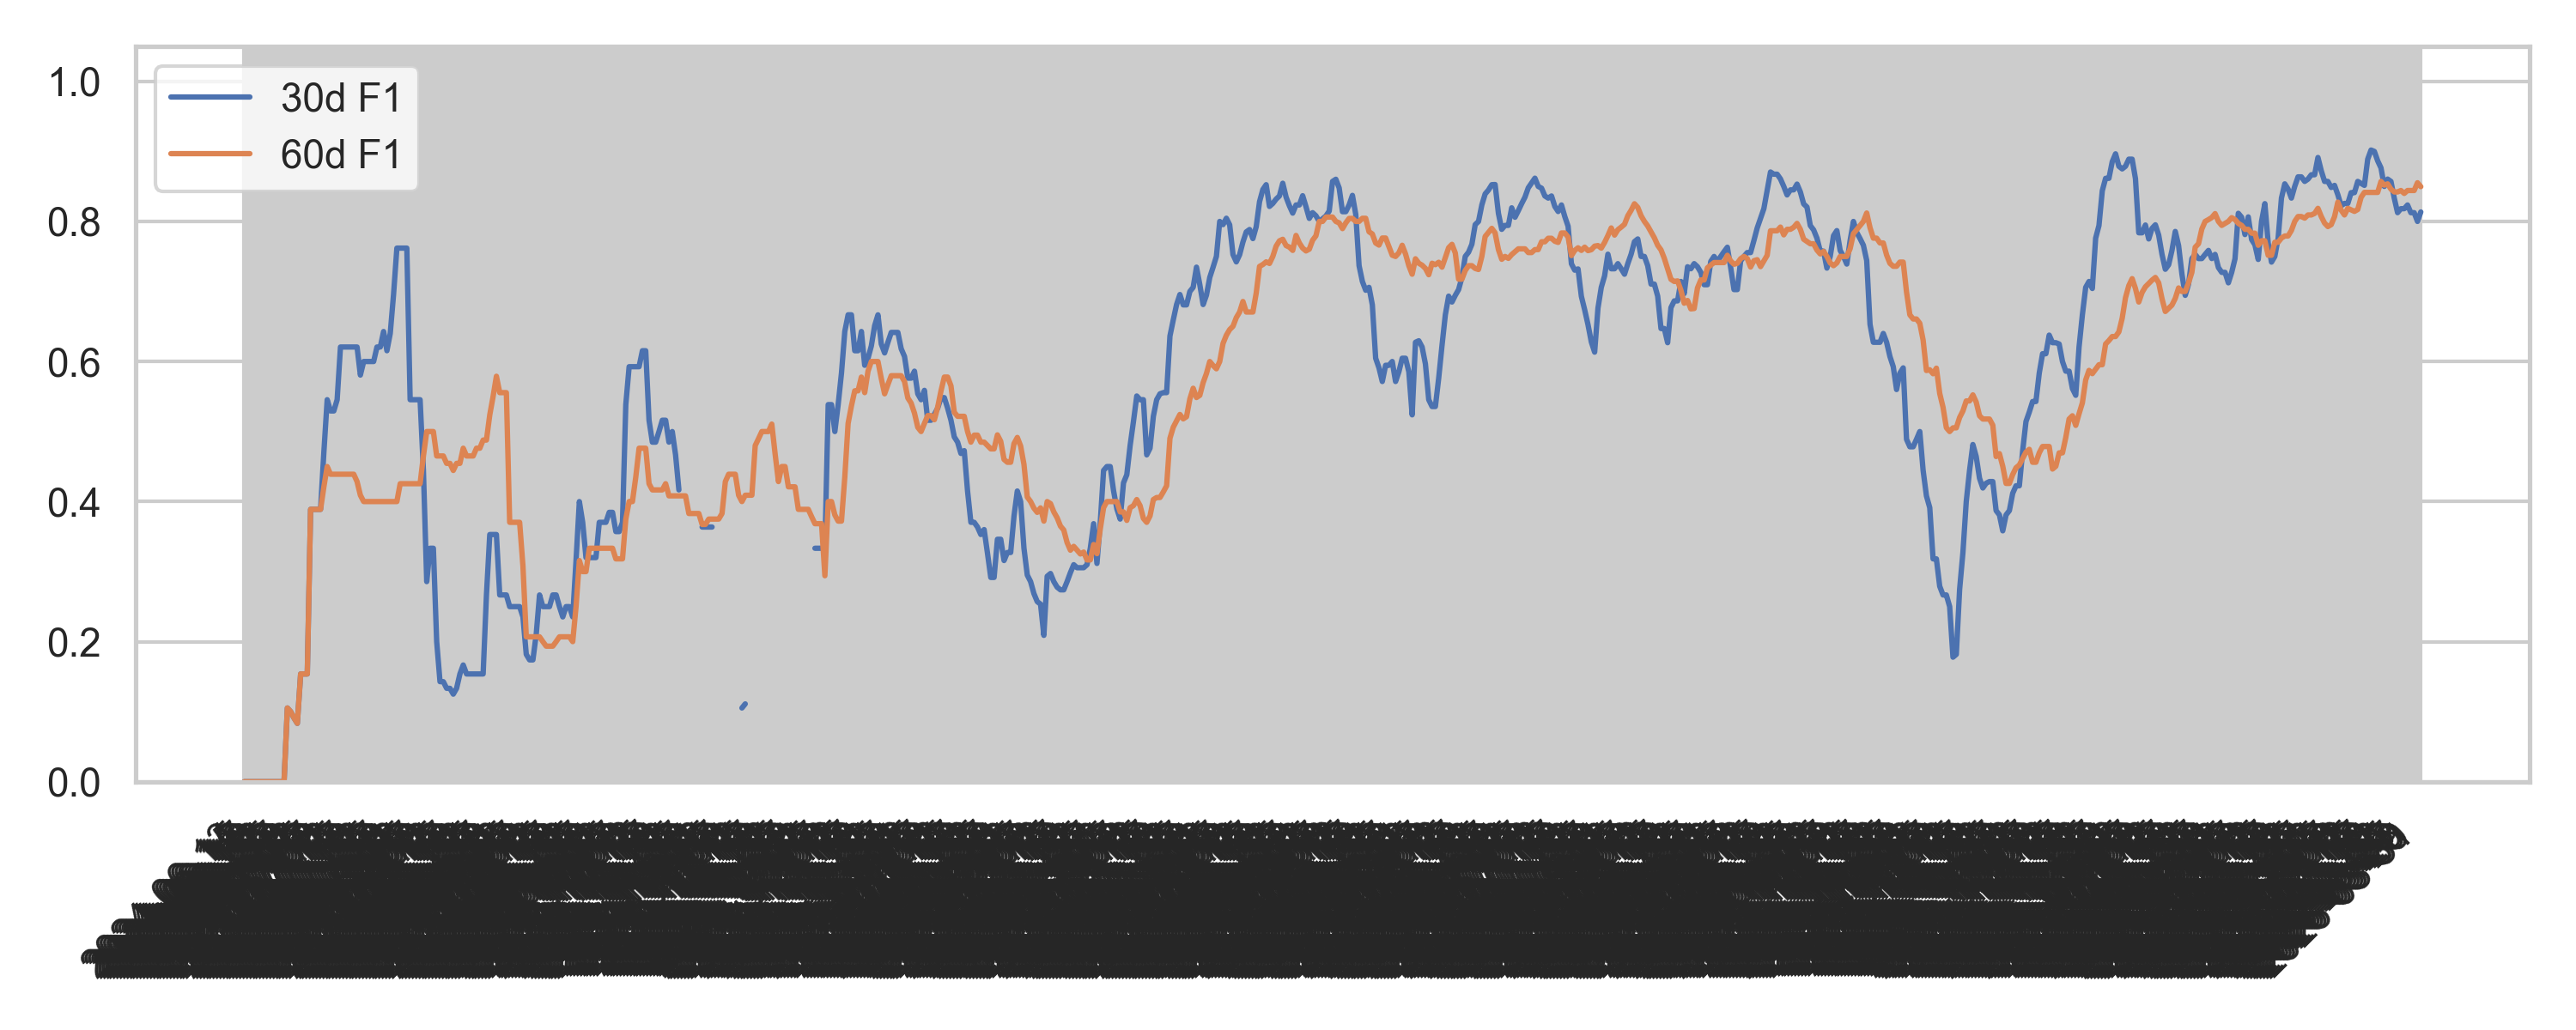

In [23]:
drift_monthly = load_csv("drift_monthly_metrics.csv")
drift_30 = load_csv("drift_rolling_30d_metrics.csv")
drift_60 = load_csv("drift_rolling_60d_metrics.csv")
drift_region = load_csv("drift_region_monthly_metrics.csv")
drift_triggers = load_csv("drift_retraining_triggers.csv")

display(drift_monthly.head(20))
display(drift_30.head(10))
display(drift_60.head(10))
display(drift_region.head(20))
display(drift_triggers.head(30))

display_png(resolve_output_path("drift_monthly_f1_recall.png"), "Monthly drift: F1 and recall")
display_png(resolve_output_path("drift_monthly_positive_rate.png"), "Monthly drift: positive rate")
display_png(resolve_output_path("drift_region_positive_rate_heatmap.png"), "Region-level positive rate heatmap")
display_png(resolve_output_path("drift_retraining_triggers_timeline.png"), "Retraining trigger timeline")
display_png(resolve_output_path("drift_rolling_30d_vs_60d_f1.png"), "Rolling 30d vs 60d F1")

**Drift interpretation:**
- Some months show low precision / high recall behavior, indicating broad alerting phases.
- Trigger flags should inform **human-reviewed retraining decisions**.
- Operational use should combine trigger output with validation checks and domain review.

## 12) Task 4 — Multi-Panel Dashboard

**Final dashboard (300 DPI)**

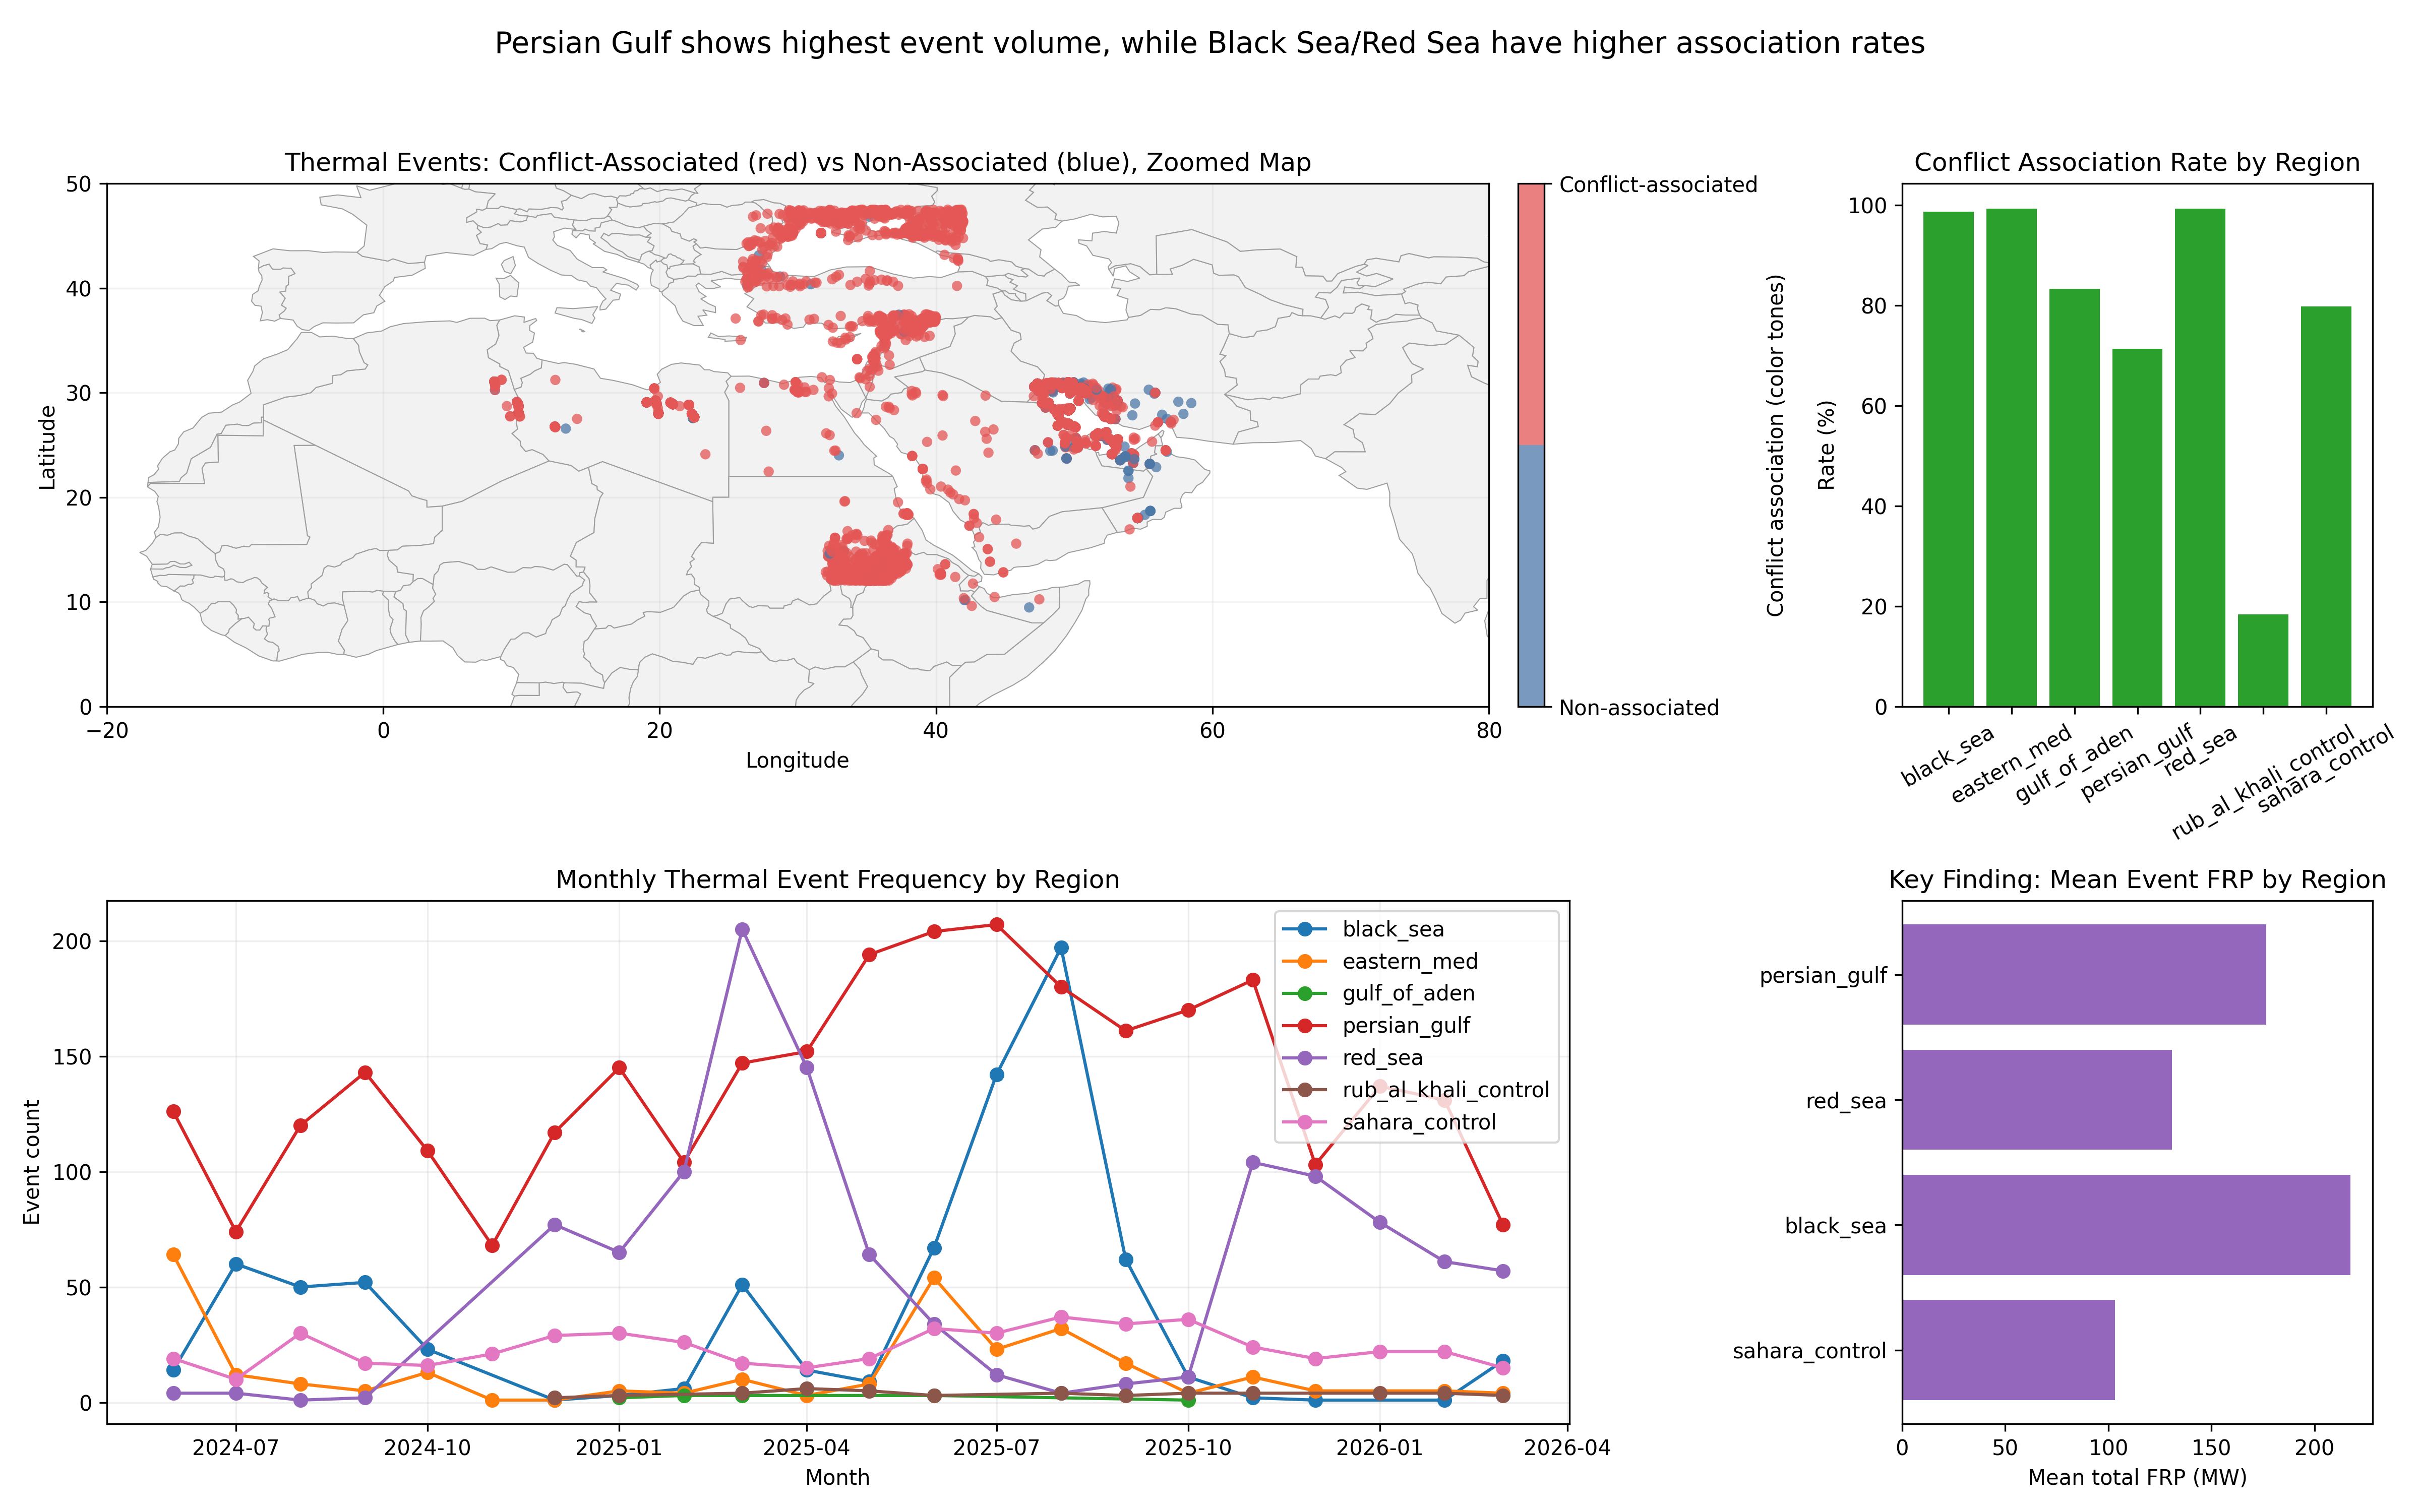

In [24]:
# Optional dashboard regeneration (kept off by default)

RUN_DASHBOARD_BUILD = False

if RUN_DASHBOARD_BUILD:
    import subprocess
    subprocess.run(["python", "build_dashboard_task4.py"], check=True)

# Display final dashboard
candidate_dashboard_paths = [
    PROJECT_ROOT / "dashboard.png",
    LEGACY_FIGURES_DIR / "dashboard.png",
    RESULTS_DIR / "dashboard.png",
]

for p in candidate_dashboard_paths:
    if p.exists():
        display_png(p, title="Final dashboard (300 DPI)")
        break
else:
    print("dashboard.png not found in expected locations.")

## 13) Written Discussion and Industry Implications

### A) Key Findings
The final system is a **satellite-first monitoring pipeline supported by news-based contextual validation**. FIRMS anomalies are the primary sensing layer, DBSCAN converts detections into interpretable thermal events, and matching provides weak-label/context support for conflict association. Signal strength differs by region, with high rates in conflict-heavy corridors and near-zero behavior in the cleaner control-like region (`rub_al_khali_control`). `sahara_control` behaves as a stress-test region, confirming sensitivity to geography and media dynamics. Random Forest remains the strongest practical classifier, while robustness checks show that non-geographic features still carry predictive signal.

### B) Shipping and Energy Implications
For maritime decision support, the system is most valuable as an early-warning and risk-prioritization layer rather than a deterministic alarm engine. Regions with elevated thermal-news association can be monitored for route disruption risk, insurance exposure, and potential fuel/energy market spillovers. A practical management strategy is staged: broad screening alerts first, then stricter confirmation using higher-evidence matching and source diversity before operational rerouting or hedging actions.

### C) Limitations and Future Work
FRP alone does not identify conflict causality. FIRMS detects thermal anomalies, not causes; industrial flares, accidents, agricultural burning, and natural fires remain confounders. News coverage is uneven across regions and sources, and event labels are weakly supervised through matching logic. Future improvements should include better geocoding/NER, stronger facility masks and infrastructure context, optional integration of external conflict datasets (if allowed), and validation-gated retraining policies. AIS/shipping-route overlays would improve direct maritime relevance.

### D) Methodology Reflection
The hardest part was robustly linking satellite events to text evidence while avoiding false positives from generic terms, source artifacts, and regional media imbalance. Iterative refinement of bilingual keyword logic, control-region diagnostics, and drift triggers materially improved quality. If restarted, we would formalize evaluation checkpoints earlier, lock reproducible reporting templates sooner, and implement stricter label-audit diagnostics from the beginning.

## 14) Final Conclusion

Satellite thermal anomalies are the primary sensing layer in this project, and conflict-news matching provides weak labels and contextual validation. Together, they support useful early situation monitoring for maritime shipping risk assessment, but they do not establish automatic conflict ground truth. The final system should therefore be used as a risk-prioritization and monitoring tool with drift-aware, human-reviewed interpretation.

## 15) Appendix — Reproducibility Notes

### Main scripts used
- `collect_firms_task1a.py`
- `process_firms_task1a.py`
- `collect_news_task1b.py`
- `build_thermal_events_task2.py`
- `dbscan_diagnostics_task2.py`
- `match_events_task3.py`
- `train_ml_task3_4.py`
- `build_dashboard_task4.py`

### Final output artifacts used
- DBSCAN diagnostics: `dbscan_sensitivity_summary.csv`, `dbscan_event_quality_main.csv`, `dbscan_region_summary_main.csv`
- Matching diagnostics: `keyword_match_diagnostics.csv`, `control_region_diagnostics.csv`, `sahara_matched_articles_review.csv`, `rub_al_khali_matched_articles_review.csv`
- ML outputs: `ml_model_comparison_full.csv`, `ml_geography_robustness_comparison.csv`, `ml_threshold_sweep_by_variant.csv`, feature-importance CSVs and figures
- Drift outputs: monthly/rolling/region metrics and `drift_retraining_triggers.csv`
- Dashboard: `dashboard.png`

### Database tables
- `firms_detections`
- `news_articles`
- `thermal_events`
- `event_matches`
- `event_scores`

### Package environment
See `requirements.txt` for package versions used in the final pipeline.

### Data source references (accessed during project period)
- NASA FIRMS: <https://firms.modaps.eosdis.nasa.gov/>
- Google News RSS: <https://news.google.com/rss>
- Bing News: <https://www.bing.com/news>
- GNews API: <https://gnews.io/>
- TheNewsAPI: <https://www.thenewsapi.com/>
- NewsAPI: <https://newsapi.org/>
- The Guardian Open Platform: <https://open-platform.theguardian.com/>